# Imports and installations

In [ ]:
#Aici am toate importurile de care am nevoie
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

import spacy
from transformers import pipeline
from collections import Counter
import seaborn as sns


In [ ]:
pip install pandas scikit-learn matplotlib seaborn sentence-transformers

# Data loading, Cleaning and Preprocessing


In [ ]:
#Updated january 2026
df_full                = pd.read_csv('applications.csv', encoding='latin')
reviews                = pd.read_csv('reviews.csv', encoding='latin')
genres                 = pd.read_csv('genres.csv', encoding='latin')
platforms              = pd.read_csv('platforms.csv', encoding='latin')
publishers             = pd.read_csv('publishers.csv', encoding='latin')
application_developers = pd.read_csv('application_developers.csv', encoding='latin')
application_genres     = pd.read_csv('application_genres.csv', encoding='latin')
application_platforms  = pd.read_csv('application_platforms.csv', encoding='latin')
application_publishers = pd.read_csv('application_publishers.csv', encoding='latin')
categories             = pd.read_csv('categories.csv', encoding='latin')
developers             = pd.read_csv('developers.csv', encoding='latin')
application_categories = pd.read_csv('application_categories.csv', encoding='latin')

/tmp/ipykernel_127982/1723977637.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full                = pd.read_csv('applications.csv', encoding='latin')


### Merging Datasets
We will join the auxiliary tables to the main `applications` dataframe to replace IDs with readable names.

In [ ]:
# 1. Merge reviews NU FACEM MERGE CU REVIEWS ca nu se potriveste doar o sa lucreza cu acest data frame cand am nevoie de el dar tot o sa il curat
#df_full = applications.merge(reviews, on='appid')

In [ ]:
#Merging the data frames to connect them
df_categories = application_categories.merge(categories, left_on='category_id', right_on='id', how='left')
df_publishers = application_publishers.merge(publishers, left_on='publisher_id', right_on='id', how='left')
df_developers = application_developers.merge(developers, left_on='developer_id', right_on='id', how='left')
df_genres     = application_genres.merge(genres, left_on='genre_id', right_on='id', how='left')
df_platforms  = application_platforms.merge(platforms, left_on='platform_id', right_on='id', how='left')

In [ ]:
#Merging everything into one
'''
df_full = df_full.merge(df_categories, on='appid', how='left')
df_full = df_full.merge(df_publishers, on='appid', how='left')
df_full = df_full.merge(df_developers, on='appid', how='left')
df_full = df_full.merge(df_genres, on='appid', how='left')
df_full = df_full.merge(df_platforms, on='appid', how='left')'''


"\ndf_full = df_full.merge(df_categories, on='appid', how='left')\ndf_full = df_full.merge(df_publishers, on='appid', how='left')\ndf_full = df_full.merge(df_developers, on='appid', how='left')\ndf_full = df_full.merge(df_genres, on='appid', how='left')\ndf_full = df_full.merge(df_platforms, on='appid', how='left')"

In [ ]:
# Merging everything into one

# Aggregate related names into single strings for each appid to prevent dataframe expansion, due to Google COlab RAM limitation
df_categories_agg = df_categories.groupby('appid')['name'].apply(lambda x: '; '.join(x.dropna().unique())).reset_index()
df_categories_agg.rename(columns={'name': 'categories_name'}, inplace=True)

df_publishers_agg = df_publishers.groupby('appid')['name'].apply(lambda x: '; '.join(x.dropna().unique())).reset_index()
df_publishers_agg.rename(columns={'name': 'publishers_name'}, inplace=True)

df_developers_agg = df_developers.groupby('appid')['name'].apply(lambda x: '; '.join(x.dropna().unique())).reset_index()
df_developers_agg.rename(columns={'name': 'developers_name'}, inplace=True)

df_genres_agg = df_genres.groupby('appid')['name'].apply(lambda x: '; '.join(x.dropna().unique())).reset_index()
df_genres_agg.rename(columns={'name': 'genres_name'}, inplace=True)

df_platforms_agg = df_platforms.groupby('appid')['name'].apply(lambda x: '; '.join(x.dropna().unique())).reset_index()
df_platforms_agg.rename(columns={'name': 'platforms_name'}, inplace=True)

# Now, merge the aggregated data into the main dataframe
df_full = df_full.merge(df_categories_agg, on='appid', how='left')
df_full = df_full.merge(df_publishers_agg, on='appid', how='left')
df_full = df_full.merge(df_developers_agg, on='appid', how='left')
df_full = df_full.merge(df_genres_agg, on='appid', how='left')
df_full = df_full.merge(df_platforms_agg, on='appid', how='left')

# Display the merged structure
print(f"Merged Dataframe shape: {df_full.shape}")
display(df_full.head())

Merged Dataframe shape: (239664, 35)


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at,categories_name,publishers_name,developers_name,genres_name,platforms_name
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,Color Alternatives; PvP; Family Sharing; Multi...,Valve,Valve,Action,windows; mac; linux
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,PvP; Family Sharing; Multi-player; Keyboard On...,Valve,Valve,Action,windows; mac; linux
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,Color Alternatives; Family Sharing; Multi-play...,Valve,Valve,Action,windows; mac; linux
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,Color Alternatives; PvP; Family Sharing; Multi...,Valve,Valve,Action,windows; mac; linux
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,Adjustable Difficulty; Family Sharing; Multi-p...,Valve,Gearbox Software,Action,windows; mac; linux


df_categories.groupby('appid'): First, we gather all the labels that belong to the same toy (appid). So, if 'game A' has 'Action' and 'Adventure' labels, they are put together.

['name']: From these grouped labels, we only care about the name of the label (like 'Action', 'Adventure').

.apply(lambda x: '; '.join(x.dropna().unique())): This is the clever part!

x.dropna(): We first throw away any empty or broken labels, just in case.
x.unique(): Then, if a toy has the same label twice (like 'Action' and 'Action'), we only keep it once. No need for duplicates!
'; '.join(...): Now, instead of having 'game A' on one line with 'Action' and 'game A' on another line with 'Adventure', we squish all the unique labels for 'game A' into one single line like this: 'Action; Adventure'. We use a ; to keep them separate but all together in one string.
.reset_index(): After we've squished all the labels for each toy, the toy's ID (appid) becomes a special marker. This command just puts it back as a normal column so it's easy to work with.

df_categories_agg.rename(columns={'name': 'categories_name'}, inplace=True): Finally, we just give our new column a clearer name. Instead of just 'name', it's now called 'categories_name' so we know it holds all the categories for that app.

Why it works:

Before, when you tried to merge, if one game had 5 categories, it would make 5 separate rows in your df_full table, even if the other information for that game was the same. This made your table huge and ran out of memory. By squishing all categories into one string on one line, each game only takes up one row in the temporary df_categories_agg table. When you merge this back, df_full doesn't grow nearly as much, saving a lot of computer memory!

###**Cleaning**

In [ ]:
import re

# 1. Drop games that are completely missing a name or short description
df_full = df_full.dropna(subset=['name', 'short_description']).copy()

# 2. Fill missing values in aggregated columns with empty strings so string operations don't fail
agg_cols = ['categories_name', 'publishers_name', 'developers_name', 'genres_name', 'platforms_name']
for col in agg_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna('')

# 3. Create a function to clean the game descriptions
def clean_game_description(text):
    text = str(text)
    # Remove HTML tags (like <strong>, <br>, etc.)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove excessive whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the description cleaner
df_full['clean_description'] = df_full['short_description'].apply(clean_game_description)

print(f"Games data cleaned! Remaining rows: {len(df_full)}")
display(df_full[['name', 'clean_description']].head(3))

Games data cleaned! Remaining rows: 224170


,name,clean_description
0,Counter-Strike,Play the world's number 1 online action game. ...
1,Team Fortress Classic,One of the most popular online action games of...
2,Day of Defeat,Enlist in an intense brand of Axis vs. Allied ...


In [ ]:
# List all the columns that *should* be numbers in your dataset
# (Add any other numerical columns you need to this list)
num_cols = [
    'mat_final_price',
    'mat_initial_price',
    'mat_discount_percent',
    'recommendations_total',
    'metacritic_score',
    'required_age'
]

for col in num_cols:
    if col in df_full.columns:
        # 1. Force the column to be a number.
        # errors='coerce' turns weird text/formatting into NaN
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce')

        # 2. Deal with the NaN values.
        # For prices and recommendations, filling missing values with 0 makes the most logical sense.
        df_full[col] = df_full[col].fillna(0)

print("Numerical columns cleaned and NaN values handled!")

# Display the data types to confirm they are now float64 or int64, NOT object
print("\nCurrent Data Types for Numerical Columns:")
print(df_full[num_cols].dtypes)

Numerical columns cleaned and NaN values handled!

Current Data Types for Numerical Columns:
mat_final_price          float64
mat_initial_price        float64
mat_discount_percent     float64
recommendations_total    float64
metacritic_score         float64
required_age             float64
dtype: object


In [ ]:
import re

# Define the columns that contain your aggregated, semicolon-separated text
text_meta_cols = [
    'name' ,
    'genres_name',
    'publishers_name',
    'categories_name',
    'developers_name',
    'platforms_name'
]

def clean_metadata_string(text):
    if pd.isna(text) or text == '':
        return ""

    text = str(text)
    # 1. Split the string into individual items (e.g., ['Action', ' Adventure'])
    items = text.split(';')

    cleaned_items = []
    for item in items:
        # 2. Encode to ASCII and ignore errors to drop emojis and unreadable characters
        item = item.encode('ascii', 'ignore').decode('ascii')

        # 3. Remove weird symbols, keeping only letters, numbers, spaces, and safe punctuation (&, -)
        item = re.sub(r'[^a-zA-Z0-9\s&\-]', '', item)

        # 4. Strip excessive whitespaces
        item = re.sub(r'\s+', ' ', item).strip()

        # 5. Only keep the item if it actually contains English letters
        # (This drops items that became totally blank or are just weird standalone punctuation)
        if re.search(r'[a-zA-Z]', item):
            cleaned_items.append(item)

    # 6. Rejoin the clean items with a semicolon and space
    return '; '.join(cleaned_items)

# Apply the function to each metadata column
for col in text_meta_cols:
    if col in df_full.columns:
        print(f"Cleaning column: {col}...")
        df_full[col] = df_full[col].apply(clean_metadata_string)

print("\nMetadata columns successfully cleaned and standardized!")
display(df_full[['name', 'genres_name', 'publishers_name']].head(5))

Cleaning column: name...
Cleaning column: genres_name...
Cleaning column: publishers_name...
Cleaning column: categories_name...
Cleaning column: developers_name...
Cleaning column: platforms_name...

Metadata columns successfully cleaned and standardized!


,name,genres_name,publishers_name
0,Counter-Strike,Action,Valve
1,Team Fortress Classic,Action,Valve
2,Day of Defeat,Action,Valve
3,Deathmatch Classic,Action,Valve
4,Half-Life Opposing Force,Action,Valve


In [ ]:
# 1. Drop rows where the review text is completely null/NaN
reviews = reviews.dropna(subset=['review_text']).copy()

# 2. Fill missing numerical values for playtime (if any exist) with 0
if 'author_playtime_at_review' in reviews.columns:
    reviews['author_playtime_at_review'] = reviews['author_playtime_at_review'].fillna(0)

# 3. Robust text cleaner for user-generated garbage
def deep_clean_review(text):
    text = str(text)
    # Encode to ASCII and ignore errors to drop emojis and weird foreign text artifacts
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Remove special characters, keeping only basic punctuation, letters, and numbers
    text = re.sub(r'[^a-zA-Z0-9 .,!?;:\'"\-]', ' ', text)
    # Remove excessive whitespaces and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Applying text cleaner... (this might take a moment depending on your RAM)")
reviews['clean_review'] = reviews['review_text'].apply(deep_clean_review)

# 4. Filter out unreadable or ultra-short "spam" reviews
# Rule: Must have at least 3 words AND contain actual letters (not just numbers/punctuation)
initial_count = len(reviews)
mask_readable = (
    (reviews['clean_review'].str.split().str.len() >= 3) &
    (reviews['clean_review'].str.contains('[a-zA-Z]', regex=True))
)

reviews_cleaned = reviews[mask_readable].copy()
dropped_count = initial_count - len(reviews_cleaned)

print(f"Dropped {dropped_count} unreadable/spam reviews.")
print(f"Cleaned reviews remaining: {len(reviews_cleaned)}")
display(reviews_cleaned[['author_steamid', 'clean_review']].head(3))

Applying text cleaner... (this might take a moment depending on your RAM)
Dropped 292252 unreadable/spam reviews.
Cleaned reviews remaining: 755117


,author_steamid,clean_review
0,76561198085405844,What's a crap. This game costs 2 euro but is w...
1,76561198014439859,"point- -click, , . . . , , . - , ."
2,76561198048038590,Erneut gibt es einen DLC mit drei neuen Lords ...


# EDA / Data Visualization

In [ ]:
# Create a list of genres for each game
df_full['genre_list'] = df_full['genres_name'].dropna().apply(lambda x: [g.strip() for g in str(x).split(';') if g.strip()])

# 'Explode' the lists so each genre gets its own row temporarily for plotting
df_exploded = df_full.explode('genre_list')

print("Data prepared for genre-based visualizations.")

Data prepared for genre-based visualizations.


In [ ]:
# 1. Convert the string "Single-player; Multi-player" into a list: ['Single-player', 'Multi-player']
df_full['category_list'] = df_full['categories_name'].apply(
    lambda x: [c.strip() for c in str(x).split(';') if c.strip()]
)

# 2. 'Explode' the lists so each category gets its own temporary row
df_cat_exploded = df_full.explode('category_list')

print("Categories exploded successfully. Data is ready for visualizations!")
display(df_cat_exploded[['name', 'category_list']].head(5))

Categories exploded successfully. Data is ready for visualizations!


,name,category_list
0,Counter-Strike,Color Alternatives
0,Counter-Strike,PvP
0,Counter-Strike,Family Sharing
0,Counter-Strike,Multi-player
0,Counter-Strike,Keyboard Only Option


**Price Distribution**

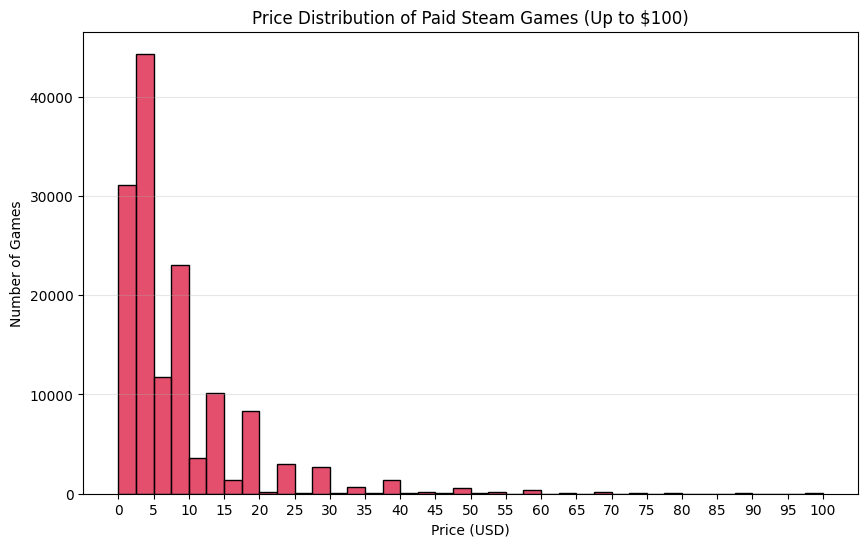

In [ ]:
plt.figure(figsize=(10, 6))

# Filter for paid games and cap at $100 to prevent massive outliers from skewing the visual
paid_games = df_full[(df_full['mat_initial_price'] > 0) & (df_full['mat_initial_price'] <= 10000)]  #999 == 9.99 deci 10000 == 100.00

#sns.histplot(paid_games['mat_initial_price']/100, bins=40, kde=False, color='crimson')
sns.histplot(paid_games['mat_initial_price']/100, binwidth=2.5, binrange=(0, 100), kde=False, color='crimson')
plt.title('Price Distribution of Paid Steam Games (Up to $100)')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Games')

plt.xticks(range(0, 105, 5))

plt.grid(axis='y', alpha=0.3)
plt.show()

Price Distribuition for the top 100

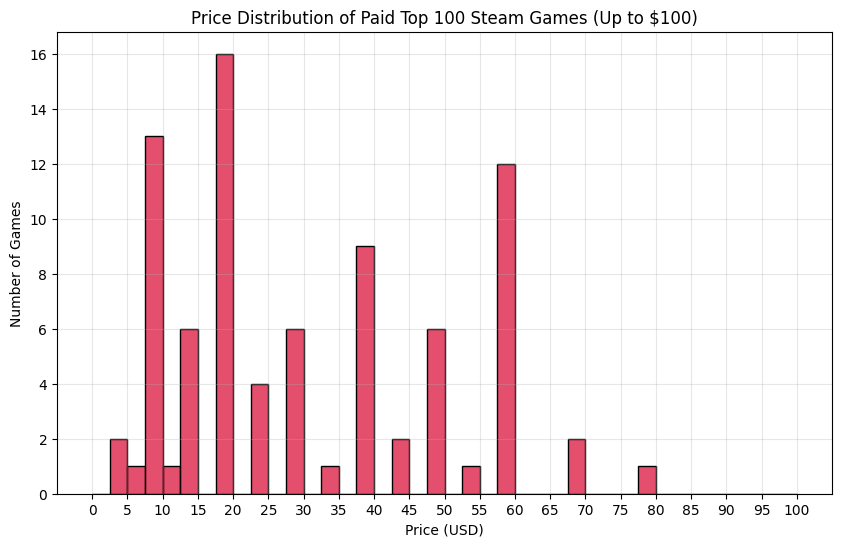

In [ ]:
plt.figure(figsize=(10, 6))

# 1. Isolate unique games to prevent duplicates from messing up the chart
unique_games = df_full.drop_duplicates(subset=['appid', 'name']).copy()

# 2. Sort the games by their true recommendation count in descending order
top_games_accurate = unique_games.sort_values(by='recommendations_total', ascending=False).head(100)

# 3. Filter for paid games and cap at $100 to prevent massive outliers from skewing the visual
paid_games = top_games_accurate[(top_games_accurate['mat_initial_price'] > 0) & (top_games_accurate['mat_initial_price'] <= 10000)]  # 999 == 9.99 deci 10000 == 100.00

#sns.histplot(paid_games['mat_initial_price']/100, bins=40, kde=False, color='crimson')
sns.histplot(paid_games['mat_initial_price']/100, binwidth=2.5, binrange=(0, 100), kde=False, color='crimson')

plt.title('Price Distribution of Paid Top 100 Steam Games (Up to $100)')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Games')

# Force the X-axis to display numbers from 0 to 100, stepping by 5
plt.xticks(range(0, 105, 5))

# Use 'both' so you get faint vertical lines mapping perfectly to the $5 marks
plt.grid(axis='both', alpha=0.3)
plt.show()

**General Player Count Proxy (Total Reviews per Game)**

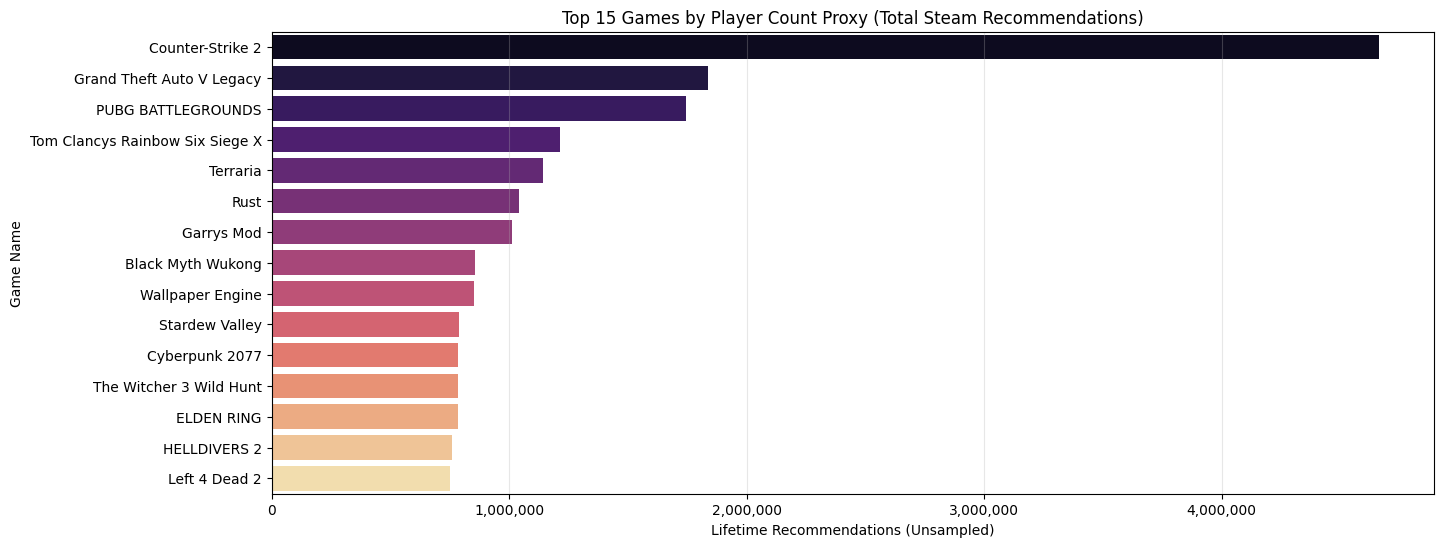

In [ ]:
# 1. Isolate unique games to prevent duplicates from messing up the chart
unique_games = df_full.drop_duplicates(subset=['appid', 'name']).copy()

# 2. Sort the games by their true recommendation count in descending order
top_games_accurate = unique_games.sort_values(by='recommendations_total', ascending=False).head(15)

# 3. Plot the data
plt.figure(figsize=(15, 6))
sns.barplot(
    x='recommendations_total',
    y='name',
    data=top_games_accurate,
    palette='magma',
    hue='name',
    legend=False
)

# Format the x-axis to show millions clearly (e.g., 1,000,000 instead of 1e6)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Top 15 Games by Player Count Proxy (Total Steam Recommendations)')
plt.xlabel('Lifetime Recommendations (Unsampled)')
plt.ylabel('Game Name')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Genre

**Number of Games per Genre**

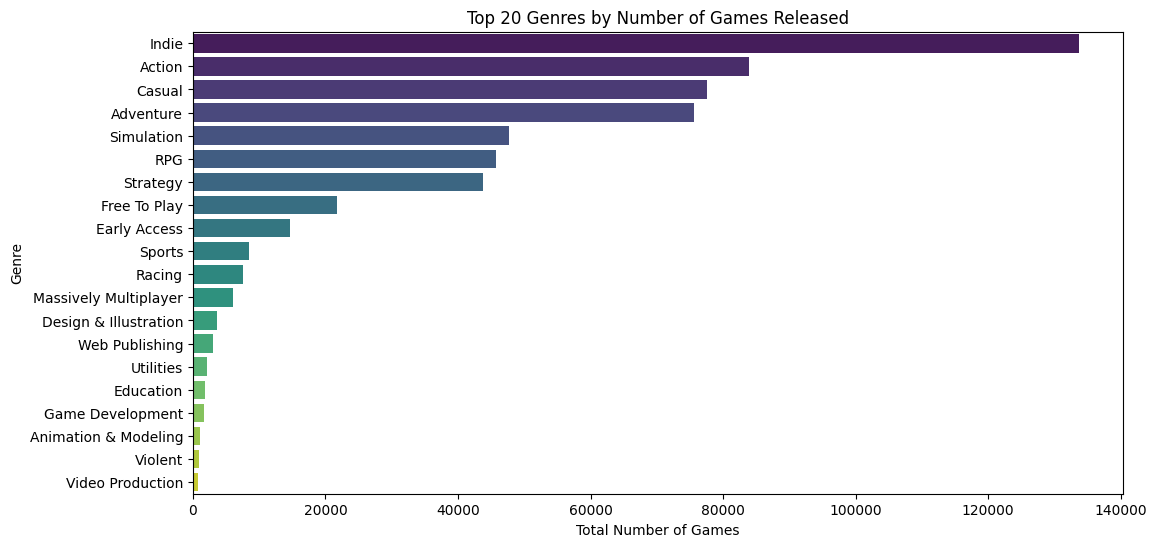

In [ ]:
plt.figure(figsize=(12, 6))

# Count occurrences of each genre and take the top 20
genre_counts = df_exploded['genre_list'].value_counts().head(20)

sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis', hue=genre_counts.index, legend=False)
plt.title('Top 20 Genres by Number of Games Released')
plt.xlabel('Total Number of Games')
plt.ylabel('Genre')
plt.show()

**Player Count Proxy per Genre**

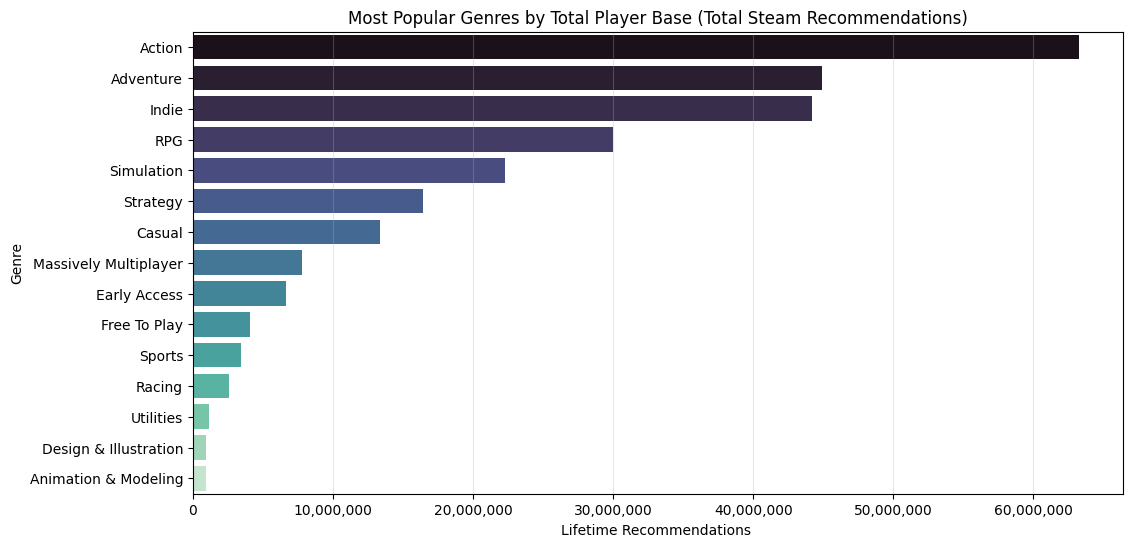

In [ ]:
# Group the exploded dataframe by genre and sum up the true recommendations_total
genre_popularity = df_exploded.groupby('genre_list')['recommendations_total'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index,
    palette='mako',
    hue=genre_popularity.index,
    legend=False
)

# Format the x-axis to show readable numbers (e.g., 10,000,000 instead of 1e7)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Most Popular Genres by Total Player Base (Total Steam Recommendations)')
plt.xlabel('Lifetime Recommendations ')
plt.ylabel('Genre')
plt.grid(axis='x', alpha=0.3)
plt.show()

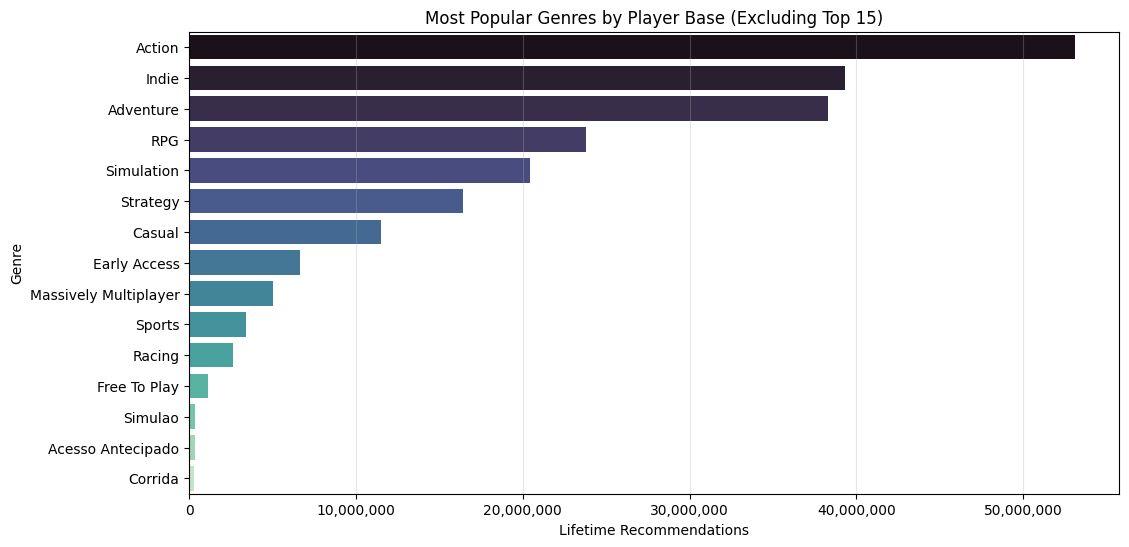

In [ ]:

# 1. Identify the 'AppIDs' of the Top 15 so we can exclude them safely
# We drop duplicates just in case, sort by recommendations, and grab the top 15 IDs
top_15_appids = df_full.drop_duplicates(subset=['appid']) \
                       .sort_values(by='recommendations_total', ascending=False) \
                       .head(15)['appid'].tolist()

# 2. Filter our exploded dataframe to REMOVE any rows where the appid matches a mega-hit
df_exploded_filtered = df_exploded[~df_exploded['appid'].isin(top_15_appids)]

# 3. Recalculate genre popularity (summing recommendations) using the filtered data
genre_popularity_filtered = df_exploded_filtered.groupby('genre_list')['recommendations_total'] \
                                                .sum() \
                                                .sort_values(ascending=False) \
                                                .head(15)

# 4. Plot the newly adjusted data
plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_popularity_filtered.values,
    y=genre_popularity_filtered.index,
    palette='mako', # Changed the color palette so you can tell the graphs apart
    hue=genre_popularity_filtered.index,
    legend=False
)

# Format the x-axis to show numbers cleanly (e.g., 5,000,000)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Most Popular Genres by Player Base (Excluding Top 15)')
plt.xlabel('Lifetime Recommendations')
plt.ylabel('Genre')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Category

**Number of Games per Category**


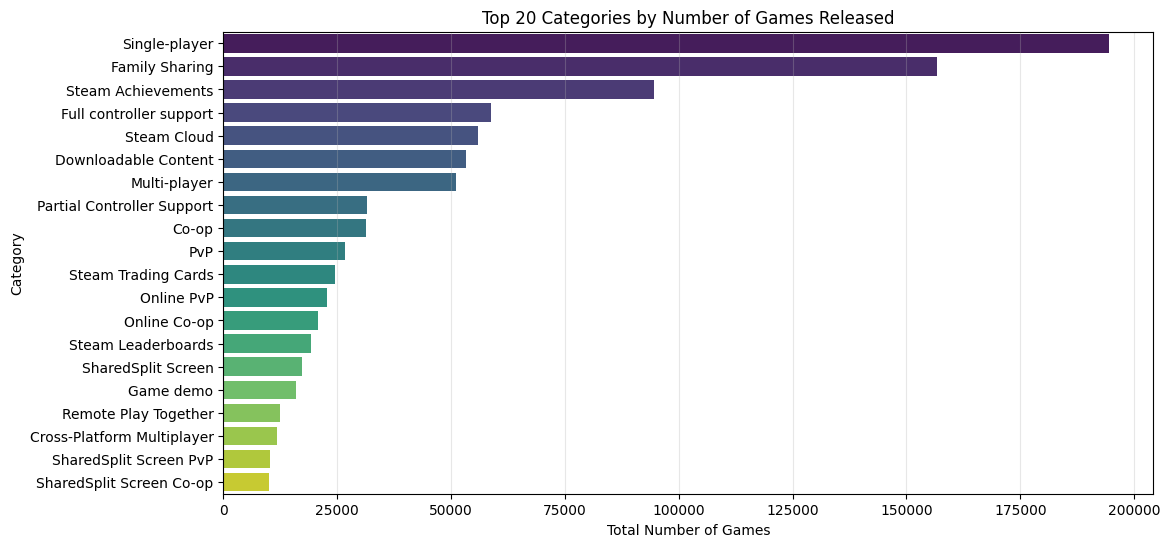

In [ ]:
plt.figure(figsize=(12, 6))

# Count occurrences of each category and take the top 20
category_counts = df_cat_exploded['category_list'].value_counts().head(20)

sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis', hue=category_counts.index, legend=False)
plt.title('Top 20 Categories by Number of Games Released')
plt.xlabel('Total Number of Games')
plt.ylabel('Category')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Most Popular Categories by Player Base (Recommendations Proxy)**

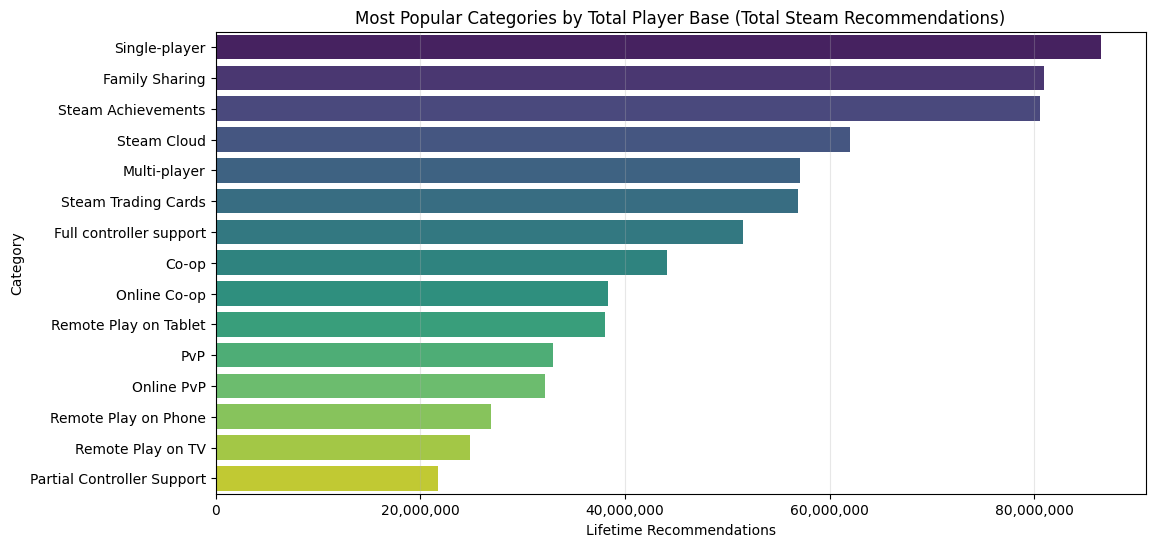

In [ ]:

# Group the exploded dataframe by category and sum up the true recommendations_total
category_popularity = df_cat_exploded.groupby('category_list')['recommendations_total'] \
                                     .sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=category_popularity.values,
    y=category_popularity.index,
    palette='viridis',
    hue=category_popularity.index,
    legend=False
)

# Format the x-axis to show readable numbers (e.g., 10,000,000)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Most Popular Categories by Total Player Base (Total Steam Recommendations)')
plt.xlabel('Lifetime Recommendations')
plt.ylabel('Category')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Most Popular Categories (Excluding Top 15)**

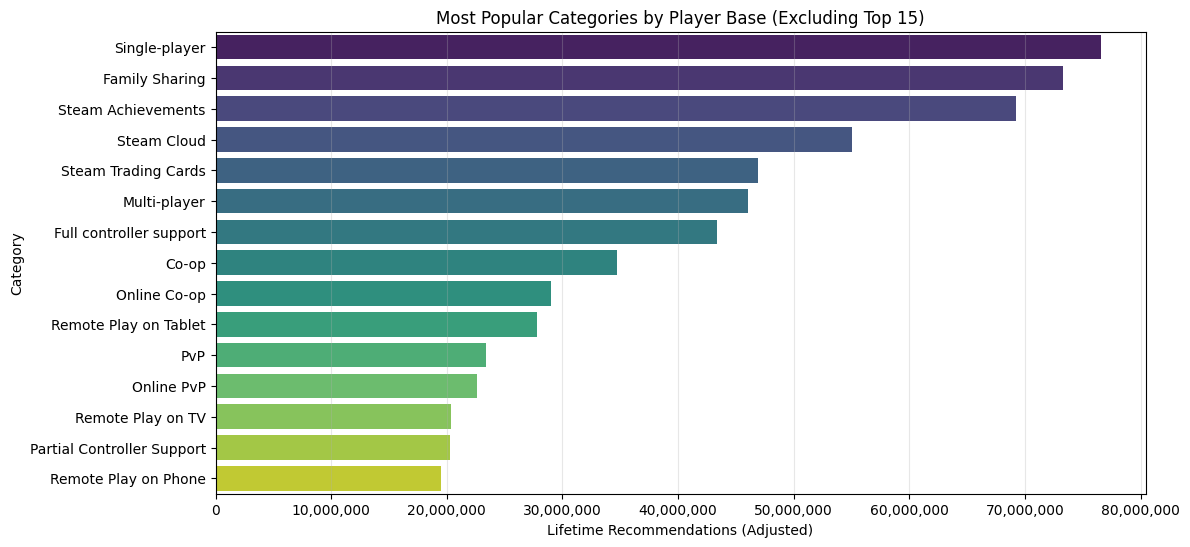

In [ ]:
# 1. Filter our category-exploded dataframe to REMOVE the mega-hits
# (We reuse the top_15_appids list we generated in the previous genre step)
df_cat_exploded_filtered = df_cat_exploded[~df_cat_exploded['appid'].isin(top_15_appids)]

# 2. Recalculate category popularity (summing recommendations) using the filtered data
cat_popularity_filtered = df_cat_exploded_filtered.groupby('category_list')['recommendations_total'] \
                                                  .sum() \
                                                  .sort_values(ascending=False) \
                                                  .head(15)

# 3. Plot the newly adjusted data
plt.figure(figsize=(12, 6))
sns.barplot(
    x=cat_popularity_filtered.values,
    y=cat_popularity_filtered.index,
    palette='viridis',
    hue=cat_popularity_filtered.index,
    legend=False
)

# Format the x-axis to show numbers cleanly
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Most Popular Categories by Player Base (Excluding Top 15)')
plt.xlabel('Lifetime Recommendations (Adjusted)')
plt.ylabel('Category')
plt.grid(axis='x', alpha=0.3)
plt.show()

------------------

**Top 5 Games for the Top 15 Genres**

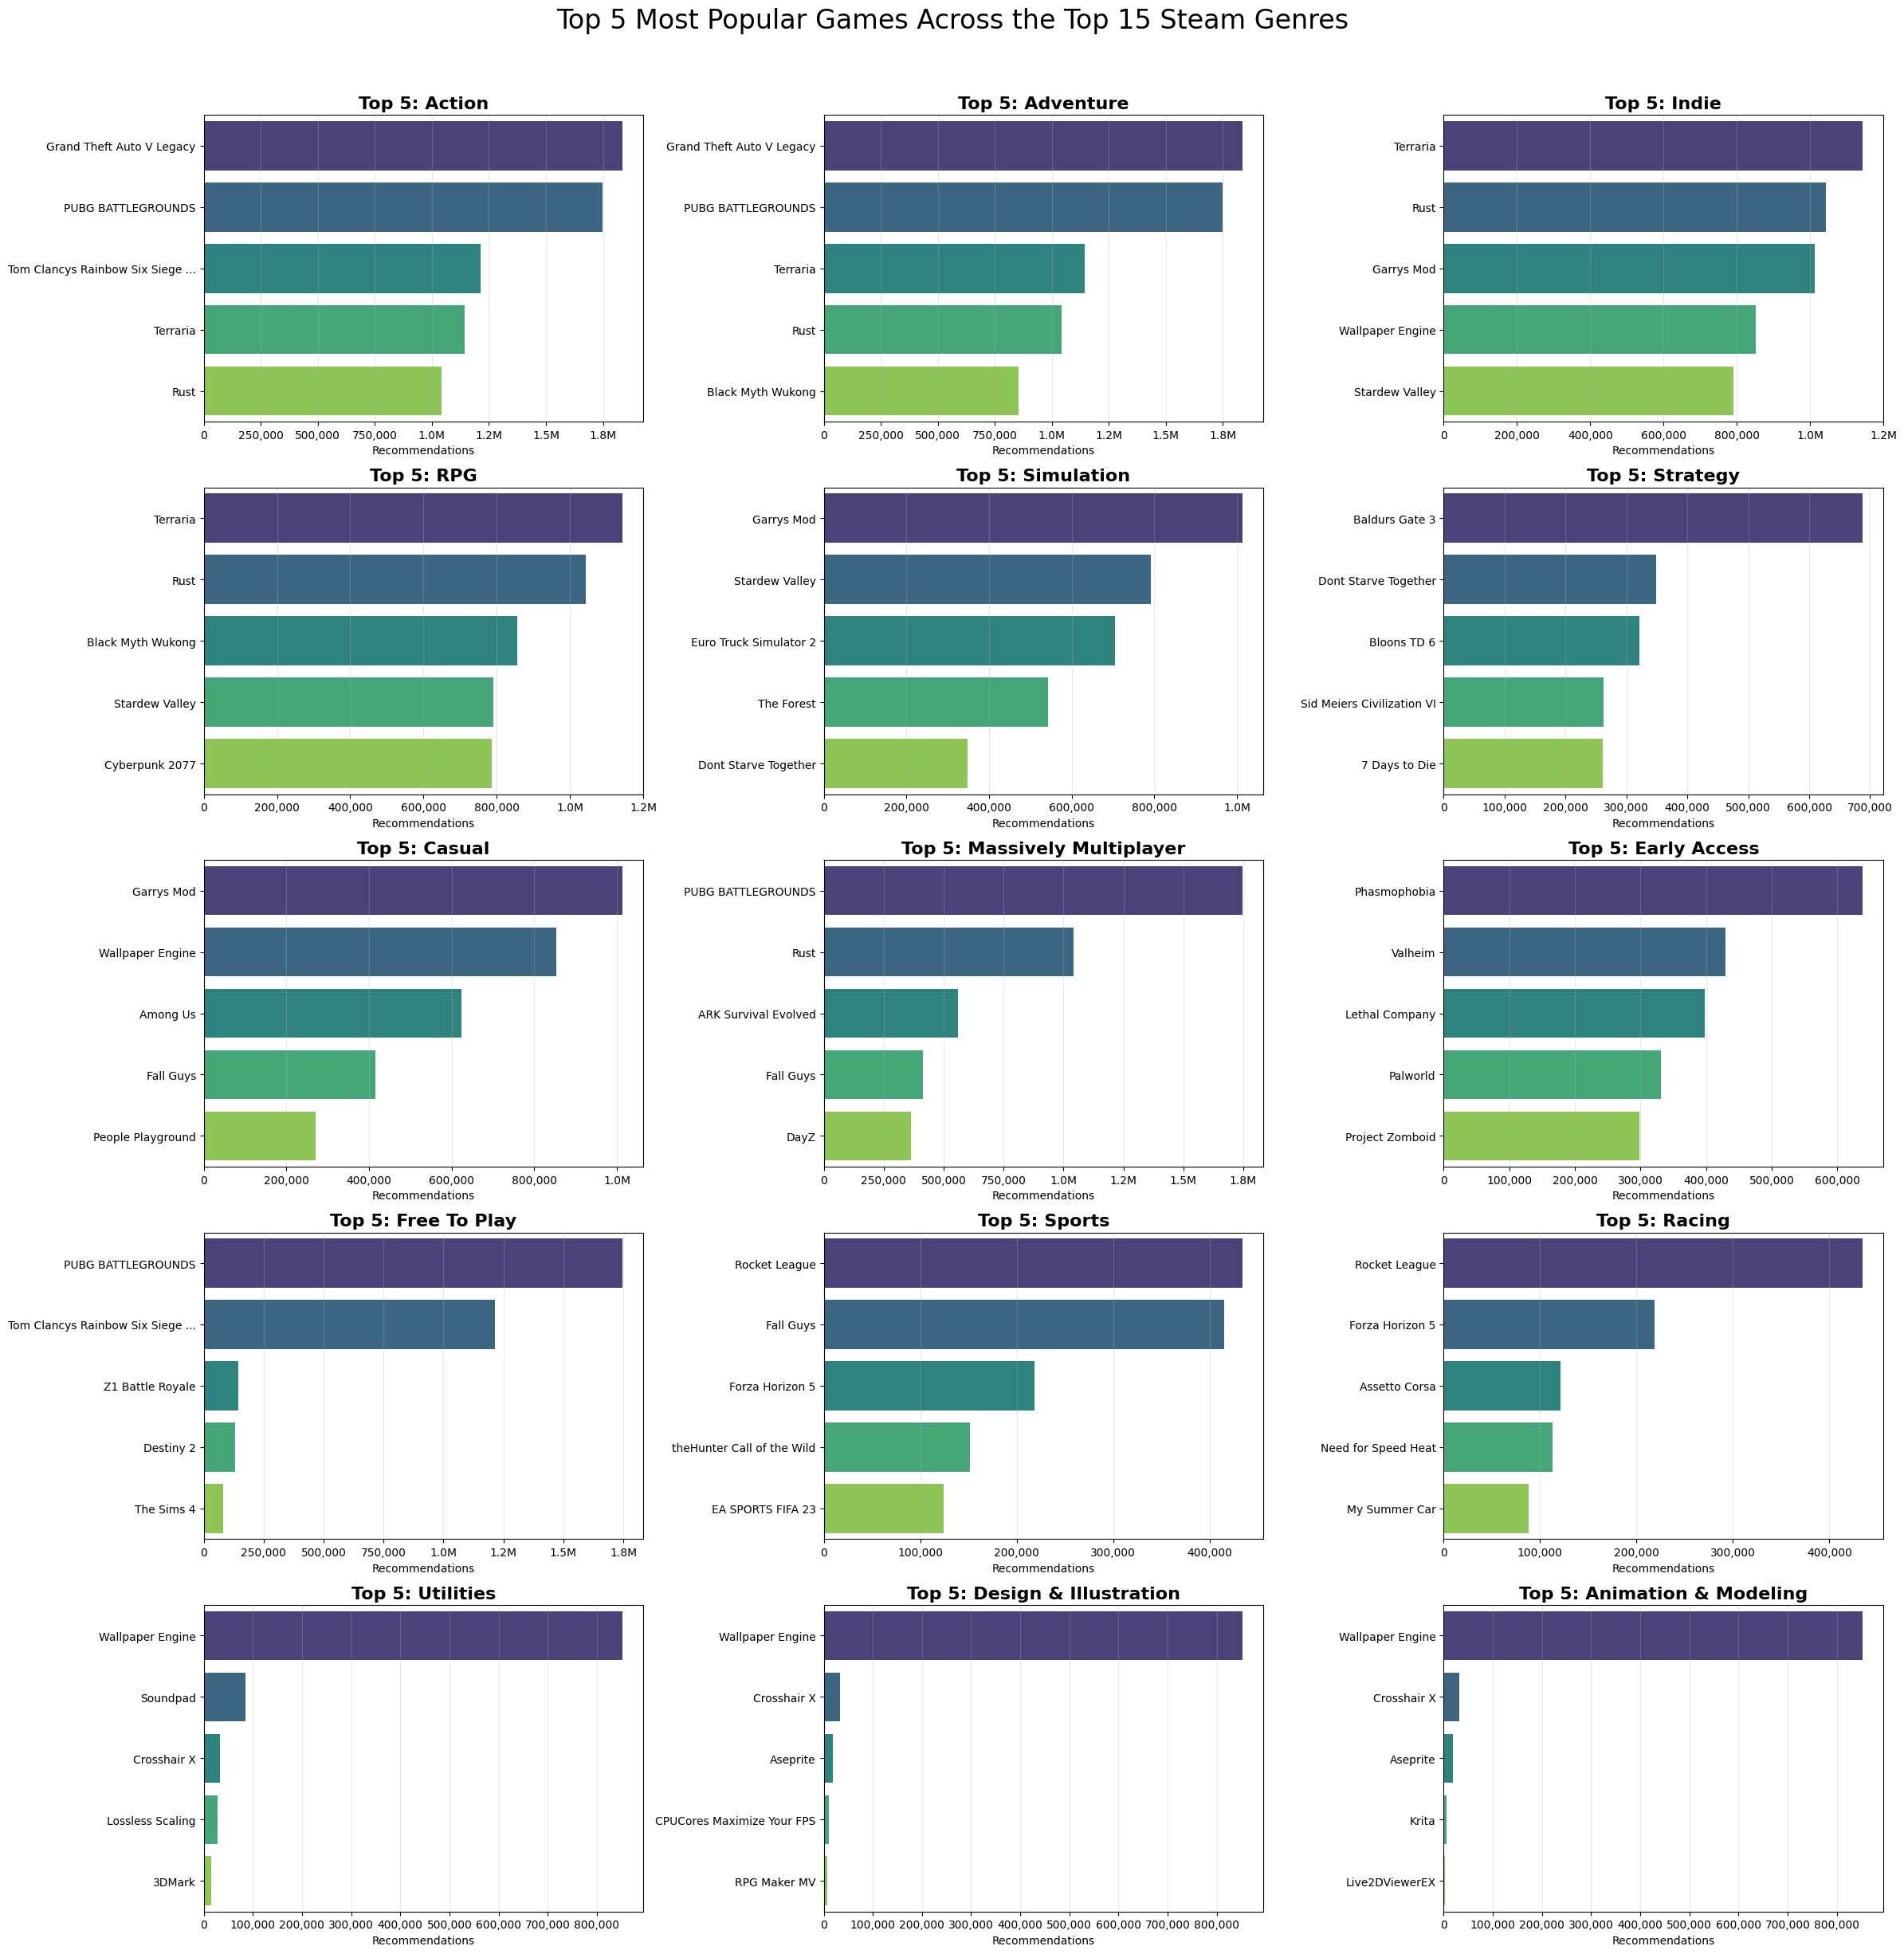

In [ ]:
import matplotlib.ticker as ticker

# 1. Identify the Top 15 Genres based on total recommendations
top_15_genres = df_exploded.groupby('genre_list')['recommendations_total'].sum().nlargest(15).index.tolist()

# 2. Filter the exploded dataframe to only include these top 15 genres
df_top_genres = df_exploded[df_exploded['genre_list'].isin(top_15_genres)].copy()

# 3. Truncate super long game names so they don't break the graphs (cap at 30 chars)
df_top_genres['short_name'] = df_top_genres['name'].apply(lambda x: str(x)[:30] + '...' if len(str(x)) > 30 else str(x))

# 4. Extract the top 5 games for EACH of those 15 genres
top_games_per_genre = df_top_genres.sort_values(['genre_list', 'recommendations_total'], ascending=[True, False])
top_games_per_genre = top_games_per_genre.groupby('genre_list').head(5)

# 5. Create a 5x3 grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(24, 24))
axes = axes.flatten() # Flatten the 5x3 matrix into a simple list for easy looping
fig.suptitle('Top 5 Most Popular Games Across the Top 15 Steam Genres', fontsize=24, y=1.02)

for i, genre in enumerate(top_15_genres):
    ax = axes[i]
    # Get the data for just this one genre
    genre_data = top_games_per_genre[top_games_per_genre['genre_list'] == genre]

    # Plot it
    sns.barplot(x='recommendations_total', y='short_name', data=genre_data, ax=ax, palette='viridis', hue='short_name', legend=False)

    # Formatting
    ax.set_title(f"Top 5: {genre}", fontsize=16, fontweight='bold')
    ax.set_xlabel('Recommendations')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x:,.0f}'))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

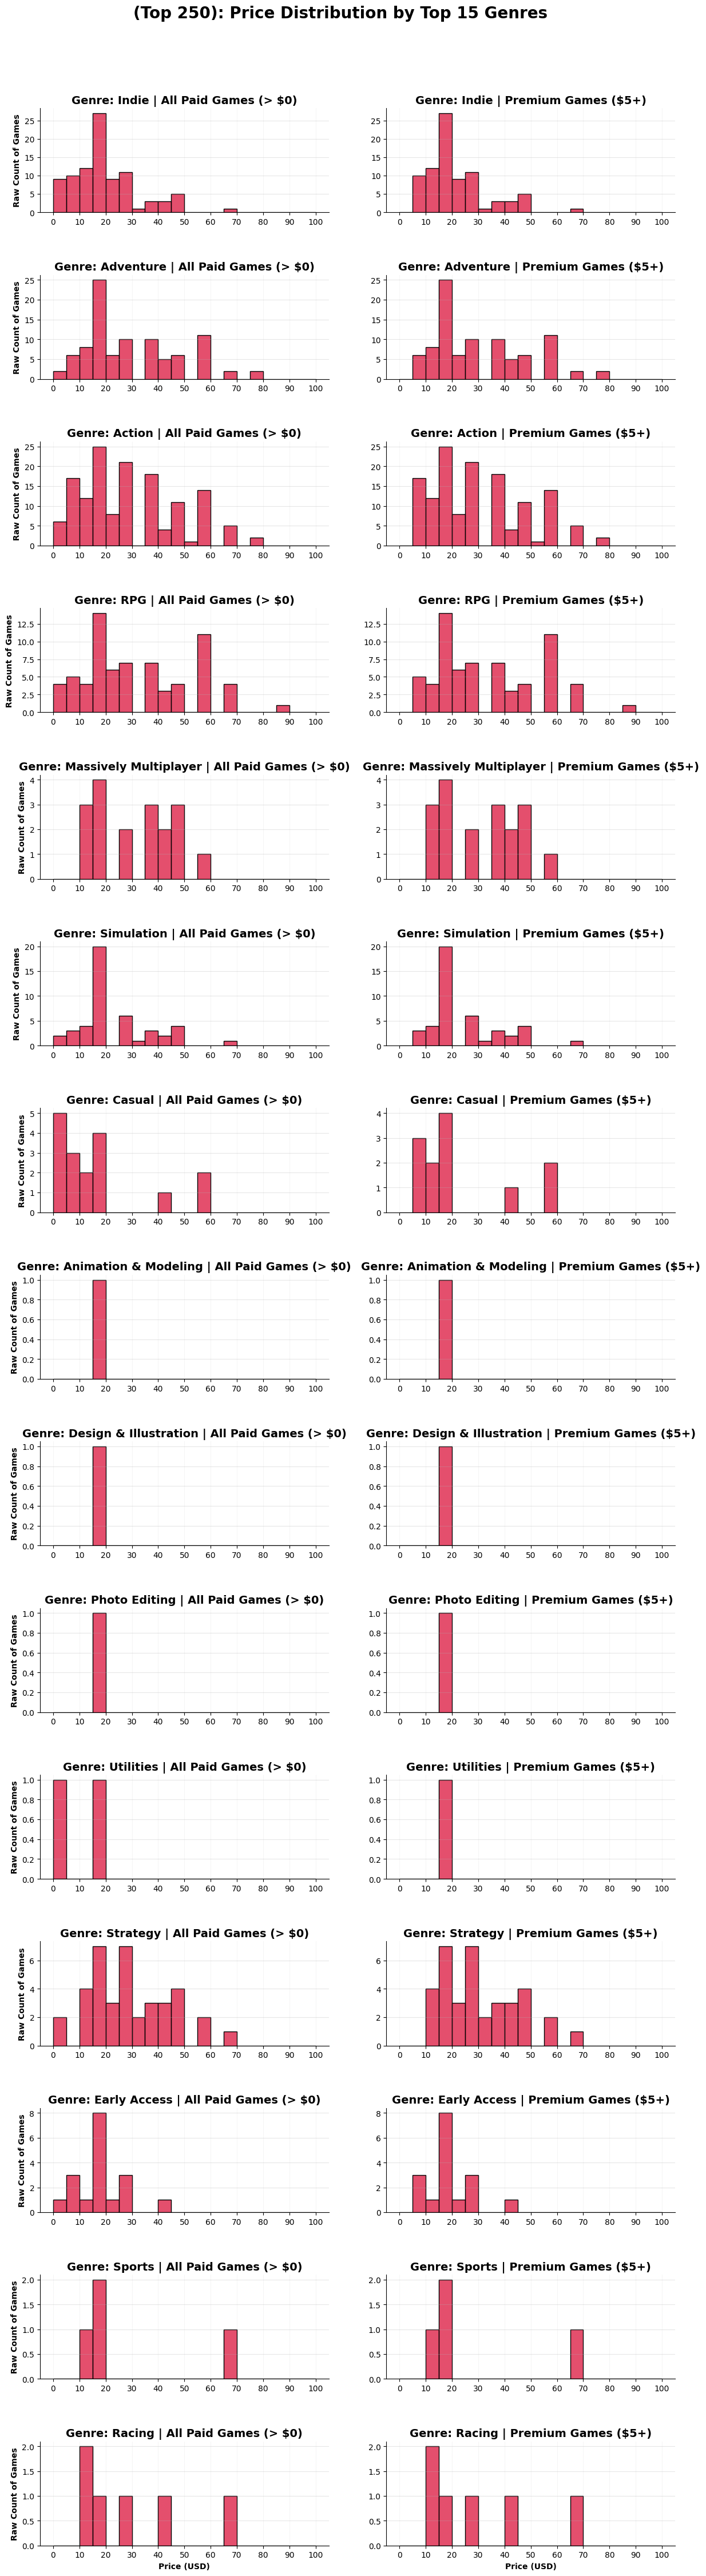

In [ ]:
import matplotlib.pyplot as plt
import seaborn as pd
import seaborn as sns
import pandas as pd


# 1. Isolate the Top 250 market winners by recommendations
top_250_df = df_full.sort_values(by='recommendations_total', ascending=False).head(250)

# 2. Filter for paid games ($0.01 to $100)
paid_df = top_250_df[(top_250_df['mat_initial_price'] > 0) & (top_250_df['mat_initial_price'] <= 10000)].copy()

# 3. Extract, split, and explode genres
paid_df = paid_df.dropna(subset=['genres_name']).copy()
paid_df['genre'] = paid_df['genres_name'].astype(str).str.split(';')
paid_df = paid_df.explode('genre')
paid_df['genre'] = paid_df['genre'].astype(str).str.strip()

# 4. Filter for only the Top 15 genres within this specific Top 250 batch
top_15_genres = paid_df['genre'].value_counts().head(15).index
filtered_genre_df = paid_df[paid_df['genre'].isin(top_15_genres)].copy()
filtered_genre_df['price_usd'] = filtered_genre_df['mat_initial_price'] / 100

# 5. Build the 15x2 Data Structure
df_all = filtered_genre_df.copy()
df_all['View'] = 'All Paid Games (> $0)'

df_5plus = filtered_genre_df[filtered_genre_df['price_usd'] >= 5.0].copy()
df_5plus['View'] = 'Premium Games ($5+)'

combined_df = pd.concat([df_all, df_5plus], ignore_index=True)

# 6. Generate the 15x2 FacetGrid
# CRITICAL FIX 1: sharey=False lets the $5+ graphs scale independently!
g = sns.FacetGrid(combined_df, row="genre", col="View", height=3, aspect=2, sharey=False)

g.map_dataframe(sns.histplot, x="price_usd", binwidth=5, binrange=(0, 100), color="crimson")

# 7. Clean formatting
g.set_titles(row_template="Genre: {row_name}", col_template="{col_name}", size=14, fontweight='bold')
g.set_axis_labels("Price (USD)", "Raw Count of Games", fontweight='bold')

for ax in g.axes.flat:
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.1)

    ax.tick_params(labelleft=True, labelbottom=True)

    # Force X-ticks to show clear $10 increments
    ax.set_xticks(range(0, 110, 10))

# CRITICAL FIX 3: Increase wspace so the new Y-axis numbers don't overlap the left charts
plt.subplots_adjust(top=0.96, hspace=0.6, wspace=0.2)
g.fig.suptitle('(Top 250): Price Distribution by Top 15 Genres', fontsize=20, fontweight='bold', y=1.0)

plt.show()

**Top 5 Games for the Top 15 Categories**

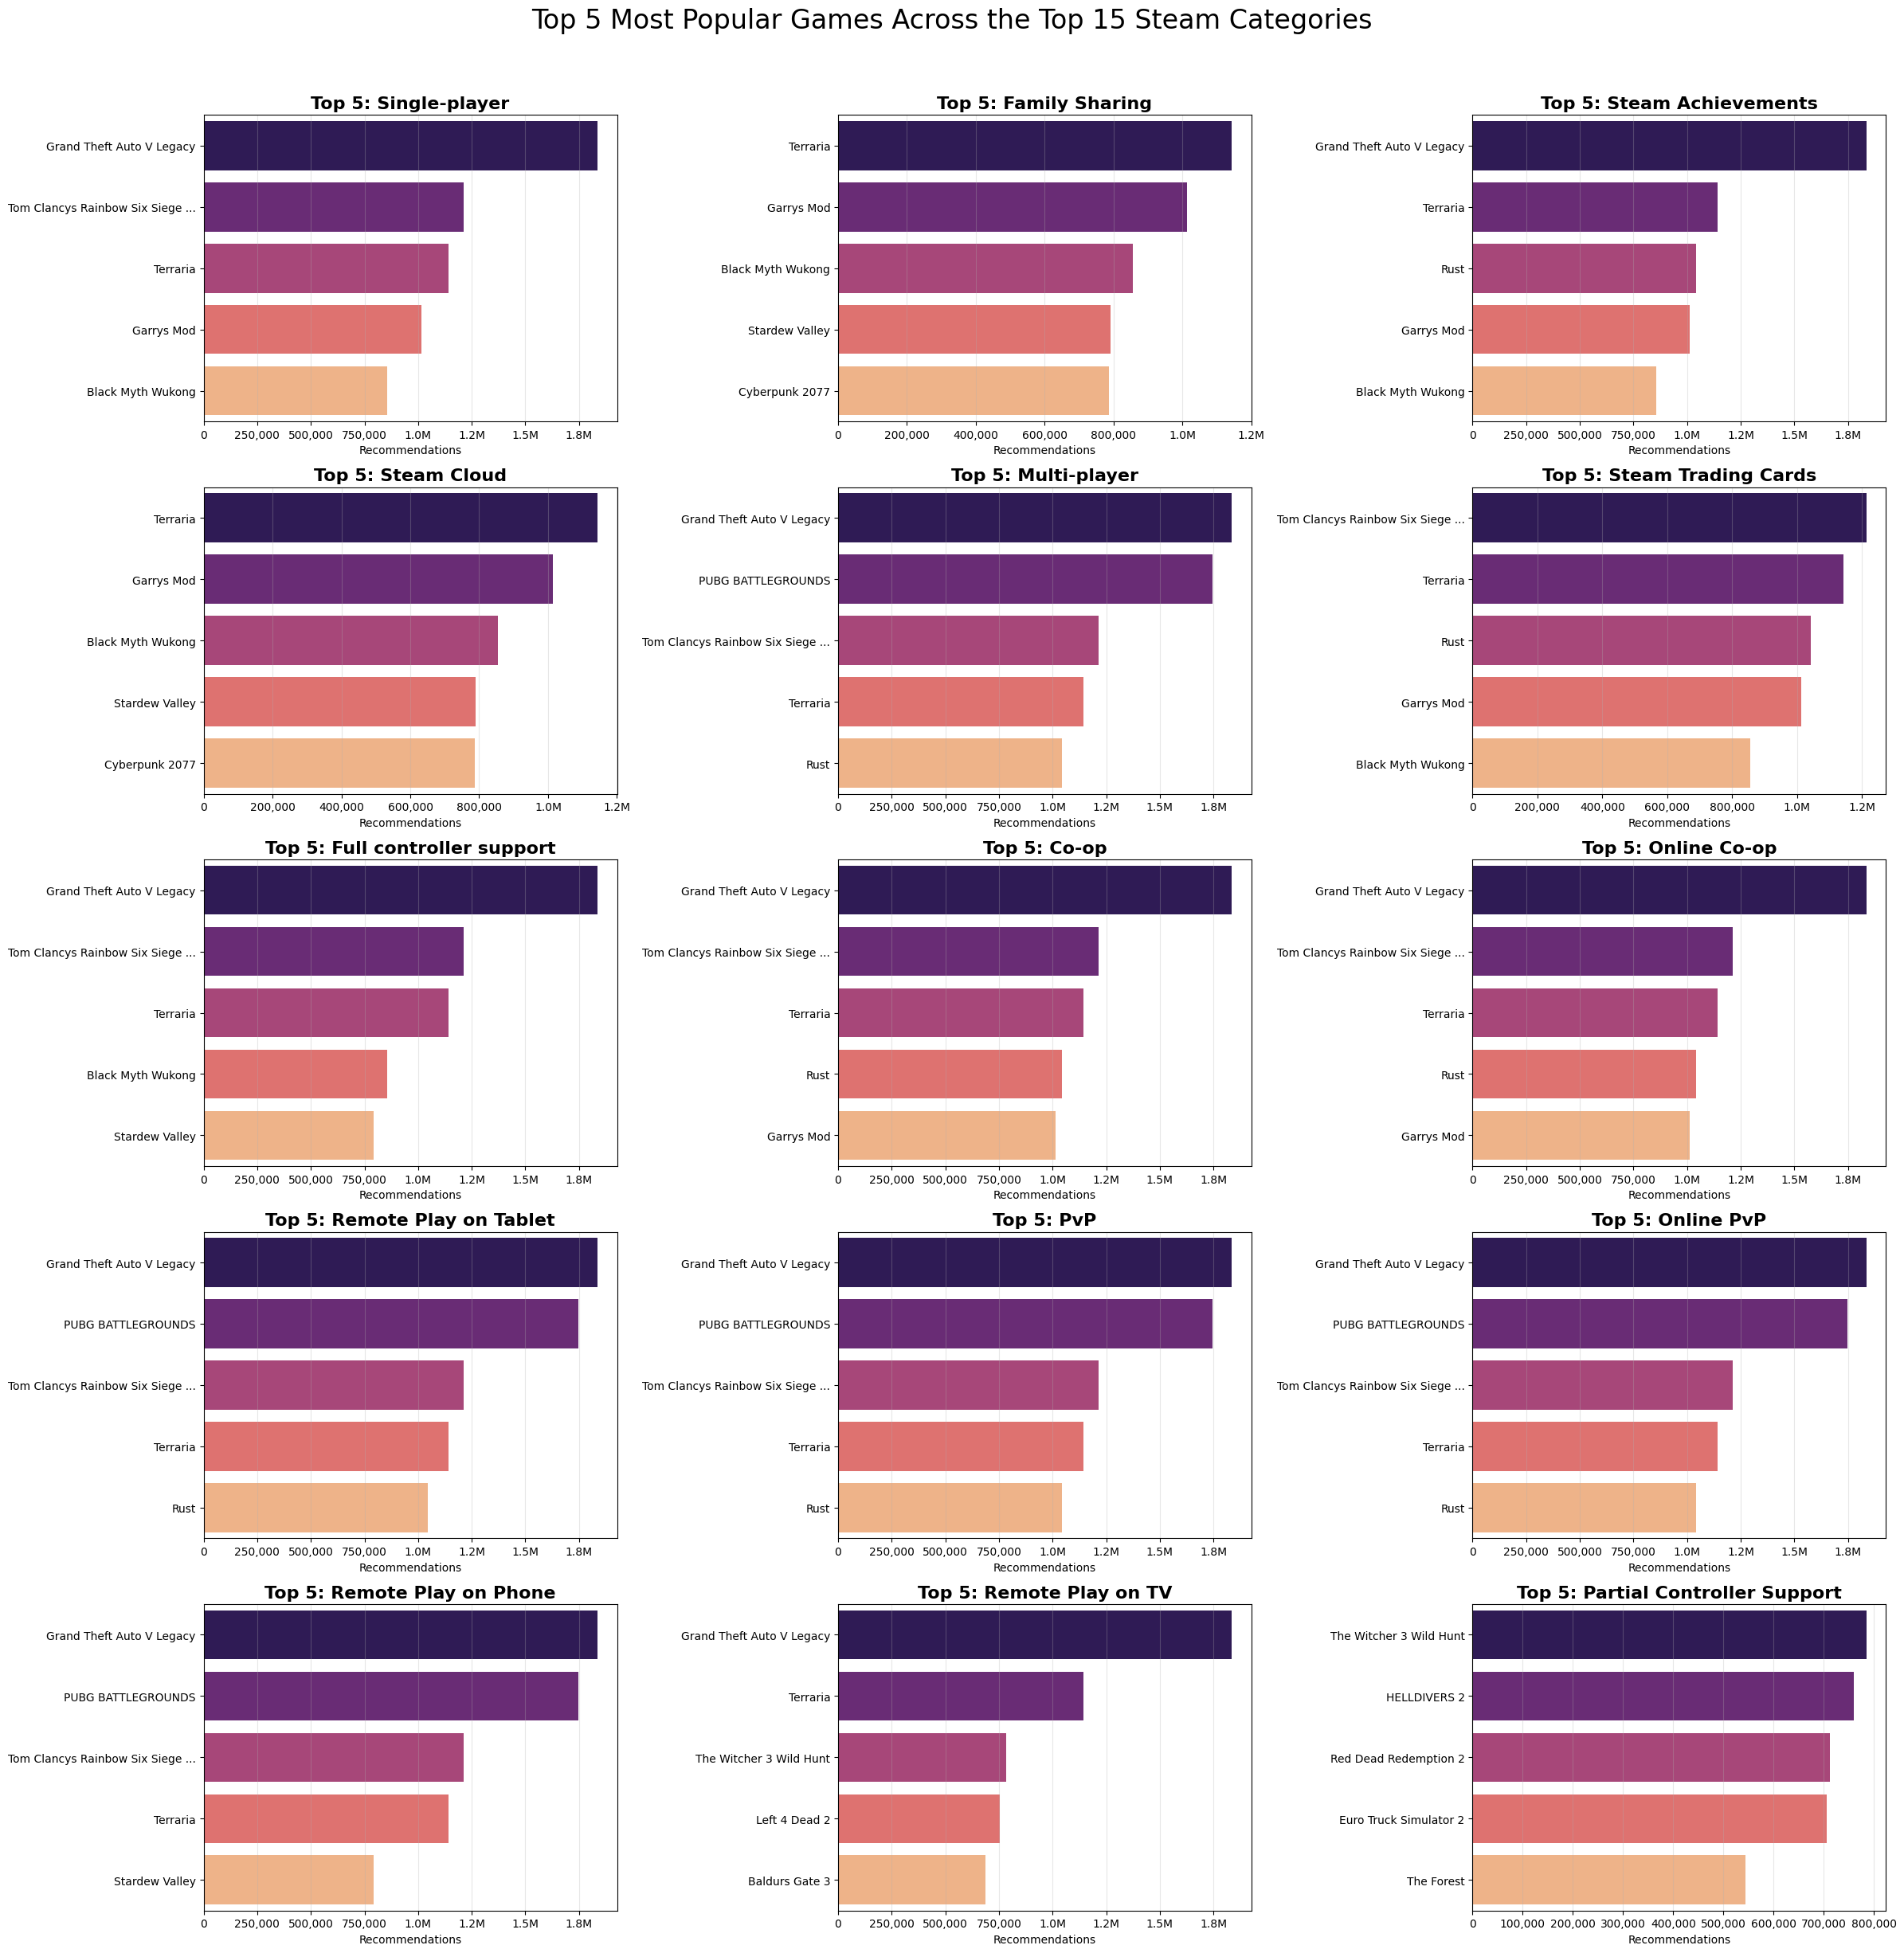

In [ ]:

# 1. Identify the Top 15 Categories based on total recommendations
top_15_cats = df_cat_exploded.groupby('category_list')['recommendations_total'].sum().nlargest(15).index.tolist()

# 2. Filter the exploded dataframe to only include these top 15 categories
df_top_cats = df_cat_exploded[df_cat_exploded['category_list'].isin(top_15_cats)].copy()

# 3. Truncate long game names
df_top_cats['short_name'] = df_top_cats['name'].apply(lambda x: str(x)[:30] + '...' if len(str(x)) > 30 else str(x))

# 4. Extract the top 5 games for EACH category
top_games_per_cat = df_top_cats.sort_values(['category_list', 'recommendations_total'], ascending=[True, False])
top_games_per_cat = top_games_per_cat.groupby('category_list').head(5)

# 5. Create the 5x3 grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(24, 24))
axes = axes.flatten()
fig.suptitle('Top 5 Most Popular Games Across the Top 15 Steam Categories', fontsize=24, y=1.02)

for i, cat in enumerate(top_15_cats):
    ax = axes[i]
    cat_data = top_games_per_cat[top_games_per_cat['category_list'] == cat]

    sns.barplot(x='recommendations_total', y='short_name', data=cat_data, ax=ax, palette='magma', hue='short_name', legend=False)

    ax.set_title(f"Top 5: {cat}", fontsize=16, fontweight='bold')
    ax.set_xlabel('Recommendations')
    ax.set_ylabel('')
    # Convert large numbers to a readable "M" (Millions) format to save space
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x:,.0f}'))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

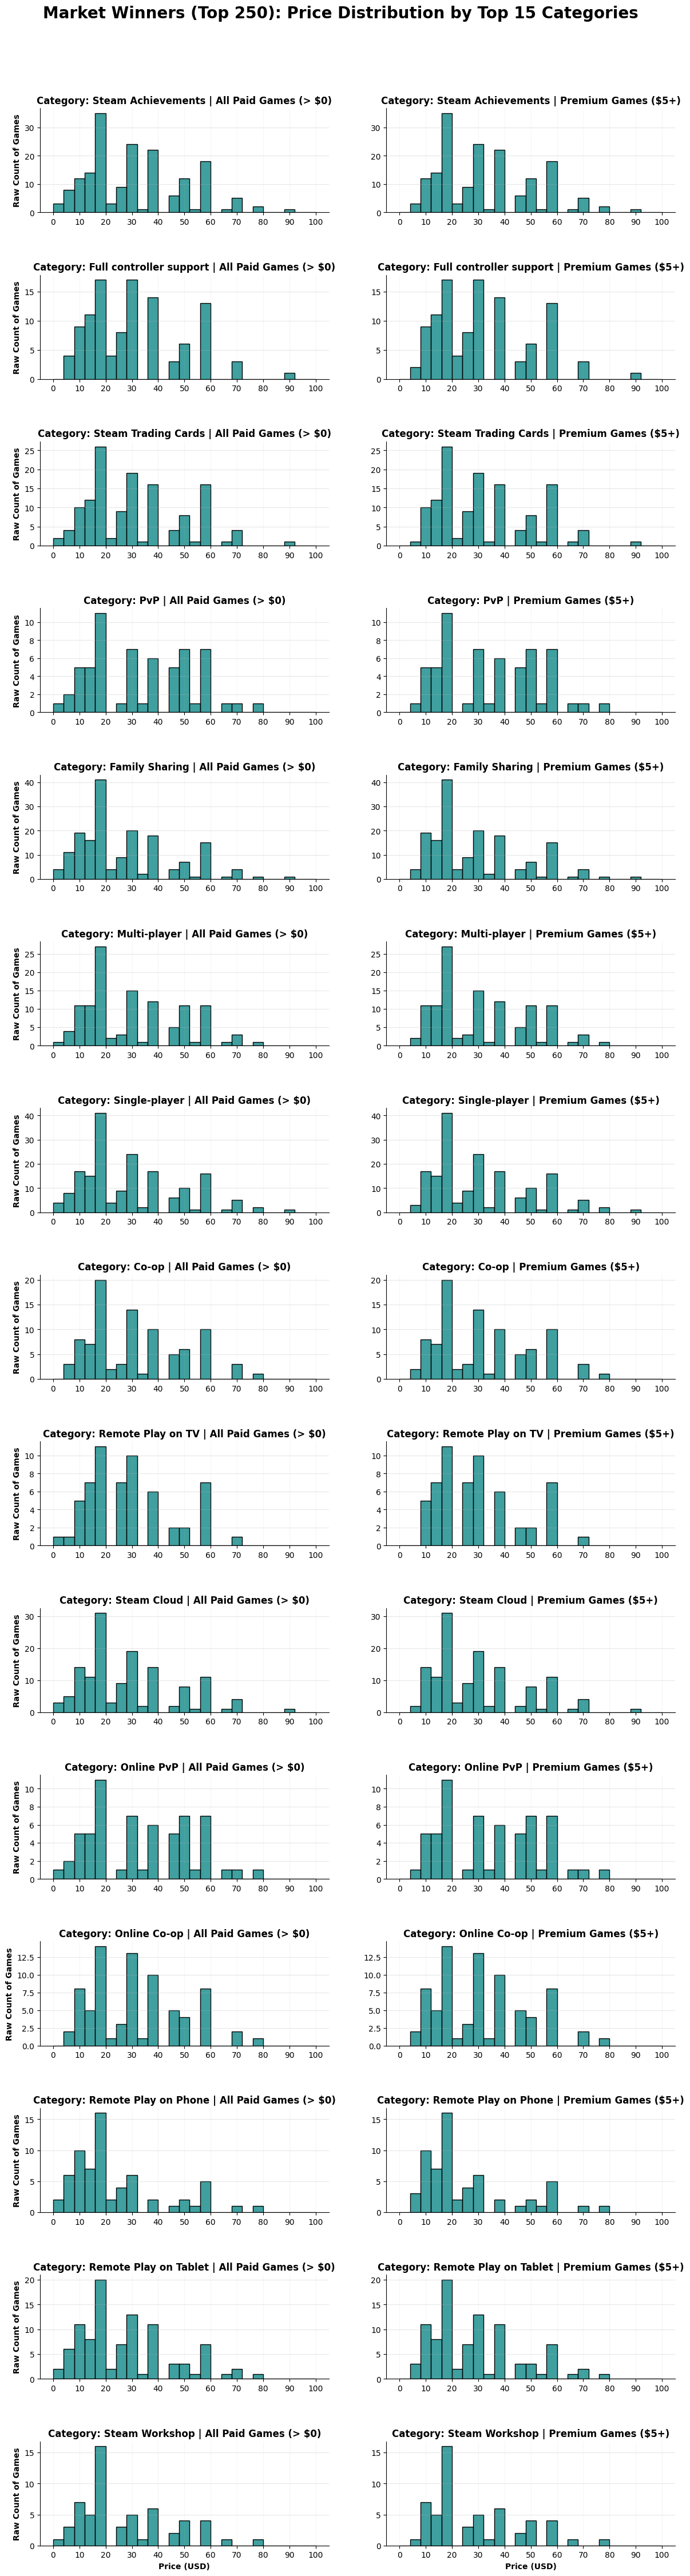

In [ ]:

# 1. Isolate the Top 250 market winners
top_250_df = df_full.sort_values(by='recommendations_total', ascending=False).head(250)

# 2. Filter for paid games ($0.01 to $100)
paid_df = top_250_df[(top_250_df['mat_initial_price'] > 0) & (top_250_df['mat_initial_price'] <= 10000)].copy()

# 3. Extract, split, and explode categories
paid_df = paid_df.dropna(subset=['categories_name']).copy()
paid_df['category'] = paid_df['categories_name'].astype(str).str.split(';')
paid_df = paid_df.explode('category')
paid_df['category'] = paid_df['category'].astype(str).str.strip()

# 4. Filter for only the Top 15 categories within the Top 250
top_15_cats = paid_df['category'].value_counts().head(15).index
filtered_cat_df = paid_df[paid_df['category'].isin(top_15_cats)].copy()
filtered_cat_df['price_usd'] = filtered_cat_df['mat_initial_price']

# 5. Build the 15x2 Data Structure
df_all = filtered_cat_df.copy()
df_all['View'] = 'All Paid Games (> $0)'

df_5plus = filtered_cat_df[filtered_cat_df['price_usd'] >= 500].copy()
df_5plus['View'] = 'Premium Games ($5+)'

combined_df = pd.concat([df_all, df_5plus], ignore_index=True)

combined_df['price_usd'] = combined_df['price_usd'] / 100

# 6. Generate the 15x2 FacetGrid
g = sns.FacetGrid(combined_df, row="category", col="View", height=3, aspect=2, sharey=False)

g.map_dataframe(sns.histplot, x="price_usd", binwidth=4, binrange=(0, 100), color="teal")

# 7. Clean formatting
g.set_titles(row_template="Category: {row_name}", col_template="{col_name}", size=12, fontweight='bold')
g.set_axis_labels("Price (USD)", "Raw Count of Games", fontweight='bold')

for ax in g.axes.flat:
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.1)

    # Force X and Y numbers to appear on EVERY single graph
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.set_xticks(range(0, 110, 10))

# Increase spacing to fit the new text
plt.subplots_adjust(top=0.96, hspace=0.6, wspace=0.2)
g.fig.suptitle('Market Winners (Top 250): Price Distribution by Top 15 Categories', fontsize=20, fontweight='bold', y=1.0)

plt.show()

LIST OF ALL THE GENRES AND CATEGORIES

In [ ]:
# 1. Get all unique genres and categories from our exploded dataframes
# We drop any NaNs, convert to string, ensure they aren't blank, and sort them alphabetically
unique_genres = sorted([str(g) for g in df_exploded['genre_list'].dropna().unique() if str(g).strip() != ''])
unique_cats = sorted([str(c) for c in df_cat_exploded['category_list'].dropna().unique() if str(c).strip() != ''])

# 2. Find out which list is longer so we can align them in a table
max_length = max(len(unique_genres), len(unique_cats))

# 3. Pad the shorter list with empty strings so they are the exact same length
genres_padded = unique_genres + [''] * (max_length - len(unique_genres))
cats_padded = unique_cats + [''] * (max_length - len(unique_cats))

# 4. Create the side-by-side DataFrame table
overview_table = pd.DataFrame({
    'All Steam Genres': genres_padded,
    'All Steam Categories': cats_padded
})

# 5. Print a quick summary and display the full table
print(f"Total Unique Genres: {len(unique_genres)}")
print(f"Total Unique Categories: {len(unique_cats)}\n")

# Temporarily force Pandas to show all rows so you can scroll through the entire list
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(overview_table)

Total Unique Genres: 114
Total Unique Categories: 363



,All Steam Genres,All Steam Categories
0,360 Video,Achievement di Steam
1,Abenteuer,Achievementy
2,Accin,Additional High-Quality Audio
3,Accounting,Adjustable Difficulty
4,Acesso Antecipado,Adjustable Text Size
5,Aciune,Aile Paylam
6,Actie,Alkalmazson belli vsrlsok
7,Action,Alternativas de cores
8,Adventure,Benutzerdefinierte Lautstrkeregelung
9,Akci,Berbagi dengan Keluarga


---------------------------------------------------------------


--- Platform Deployment Raw Counts ---
Windows: 224,166 deployments
macOS: 223,900 deployments
Linux: 223,872 deployments


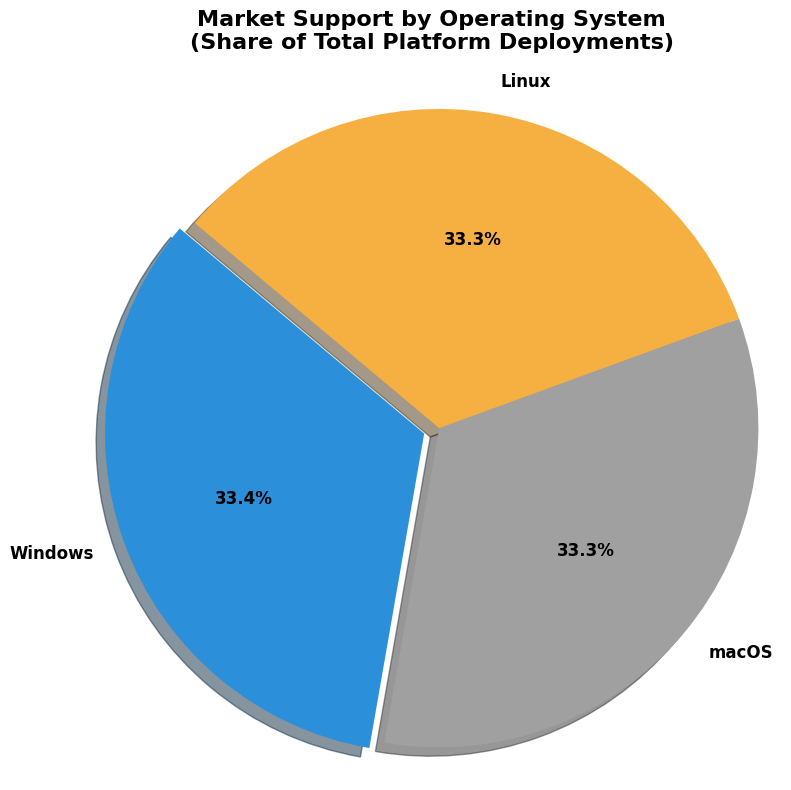

In [ ]:
# 1. Use your EXACT dataset column names
platform_cols = ['mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux']
platform_labels = ['Windows', 'macOS', 'Linux']

counts = []

# 2. Bulletproof Boolean Counting
for col in platform_cols:
    if col in df_full.columns:
        # Convert the entire column to string, strip whitespace, make uppercase, and count 'TRUE'
        # This safely catches boolean True, string 'True', or string 'TRUE'
        support_count = (df_full[col].astype(str).str.strip().str.upper() == 'TRUE').sum()
        counts.append(support_count)
    else:
        print(f"Column '{col}' not found in dataframe! Check your spelling.")
        counts.append(0)

# 3. Print the raw data so you can verify it matches your spreadsheet!
print("\n--- Platform Deployment Raw Counts ---")
for label, count in zip(platform_labels, counts):
    print(f"{label}: {count:,.0f} deployments")

# 4. Generate the Pie Chart (Only if we successfully counted data)
if sum(counts) > 0:
    plt.figure(figsize=(8, 8))

    # Professional color palette
    colors = ['#2b90d9', '#a0a0a0', '#f5b041']

    # "Explode" the Windows slice slightly to emphasize its dominance
    explode = (0.05, 0, 0)

    plt.pie(
        counts,
        labels=platform_labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'black'}
    )

    plt.title('Market Support by Operating System\n(Share of Total Platform Deployments)', fontsize=16, fontweight='bold', pad=20)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print("\nError: All counts returned 0. The pie chart cannot be generated.")

# Recommendation System - Data Clean+ & Language Embeddings




In [ ]:
# 1. Filter out noise: Only keep games with at least 50 recommendations and a price > 0
# This leaves us with the actual competitive market, not free-to-play spam or abandoned projects.
market_df = df_full[(df_full['recommendations_total'] >= 50) & (df_full['mat_initial_price'] > 0)].copy()
market_df.reset_index(drop=True, inplace=True)

print(f"Filtered competitive market size: {len(market_df)} games")

# 2. Load the Language Model
print("Loading all-MiniLM-L6-v2 Model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

#Added to give more context
market_df['embed_text'] = (
    market_df['name'].fillna('') + '. ' +
    market_df['genres_name'].fillna('').str.replace(';', ', ') + '. ' +
    market_df['categories_name'].fillna('').str.replace(';', ', ') + '. ' +
    market_df['clean_description'].fillna('')
)

# 3. Generate Embeddings (This maps the clean_description into 384-dimensional math vectors) ~25 minutes
print("Generating text embeddings...")
embeddings = model.encode(market_df['embed_text'].tolist(), show_progress_bar=True)



print("Embeddings generated successfully")

Filtered competitive market size: 21672 games
Loading all-MiniLM-L6-v2 Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating text embeddings...


Batches:   0%|          | 0/678 [00:00<?, ?it/s]

Embeddings generated successfully


# Recommendation system - The actual system

In [ ]:
# Ensure metacritic_score is a number and fill missing scores with 0
market_df['metacritic_score'] = pd.to_numeric(market_df['metacritic_score'], errors='coerce').fillna(0)

In [ ]:
print("--- Applying Currency Scaling Fix ---")
# Steam API stores prices in cents. Convert to standard decimal currency.
market_df['mat_initial_price'] = market_df['mat_initial_price'] / 100
df_full['mat_initial_price'] = df_full['mat_initial_price'] / 100

print("Prices successfully converted from cents to dollars.")

--- Applying Currency Scaling Fix ---
Prices successfully converted from cents to dollars.


In [ ]:
def analyze_and_pivot_game_idea_upgraded(idea_description, top_n=10):
    print(f"\nAnalyzing Market Viability for Idea: '{idea_description[:50]}...'")

    # 1. Encode the user's idea
    idea_embedding = model.encode([idea_description])

    work = market_df.copy()
    # 2. Calculate Cosine Similarity
    sim_scores = cosine_similarity(idea_embedding, embeddings)[0]
    work['similarity_to_idea'] = sim_scores

   # 3. Identify the TRUE Direct Competitors (The Threat Matrix)
    # Calculate a normalized popularity score using log to handle massive outliers (like CS:GO)
    log_recs = np.log1p(work['recommendations_total'])
    work['normalized_popularity'] = (log_recs - log_recs.min()) / (log_recs.max() - log_recs.min())

    # Calculate the Composite Threat Score
    # We weight it: 75% for how similar the game is, 25% for how big the player base is.
    weight_similarity = 0.75
    weight_popularity = 0.25

    work['threat_score'] = (work['similarity_to_idea'] * weight_similarity) + \
                                (work['normalized_popularity'] * weight_popularity)

    # Sort by the new Threat Score instead of pure similarity
    competitors = work.sort_values(by='threat_score', ascending=False).head(top_n)
    # 4. Calculate Market Metrics & Profitability Proxy
    # Using the standard Boxleiter ratio (1 review ~= 30 sales)
    competitors['estimated_revenue'] = competitors['mat_initial_price'] * competitors['recommendations_total'] * 30

    # We also update the global market revenue for the pivot calculation later
    work['estimated_revenue'] = work['mat_initial_price'] * work['recommendations_total'] * 30

    avg_comp_price = competitors['mat_initial_price'].mean()
    avg_comp_recs = competitors['recommendations_total'].mean()
    avg_revenue = competitors['estimated_revenue'].mean()

    # 5. Advanced Metacritic & Press Visibility Assessment
    # How many of the top competitors actually have a score?
    valid_metacritic = competitors[competitors['metacritic_score'] > 0]
    metacritic_coverage_percent = (len(valid_metacritic) / top_n) * 100
    avg_metacritic = valid_metacritic['metacritic_score'].mean() if not valid_metacritic.empty else 0

    print("\n--- COMPETITION & PROFITABILITY ASSESSMENT ---")
    print(f"Top {top_n} Direct Competitors Found.")
    print(f"Average Entry Price: ${avg_comp_price:.2f}")
    print(f"Average Recommendations: {avg_comp_recs:,.0f} (Playerbase Proxy)")
    print(f"Estimated Niche Revenue Avg: ${avg_revenue:,.0f}")

    # Dynamic Threat Level based on Press Coverage AND Score
    threat_level = "Low"
    if metacritic_coverage_percent >= 50 and avg_metacritic >= 80:
        threat_level = "CRITICAL (Niche dominated by highly visible, critically acclaimed heavyweights)"
    elif metacritic_coverage_percent >= 50:
        threat_level = "High (Strong press visibility in this niche; high marketing barrier to entry)"
    elif avg_metacritic >= 75:
        threat_level = "Moderate-High (Lower press coverage volume, but a high quality barrier exists)"
    elif metacritic_coverage_percent == 0:
        threat_level = "Unknown / Indie (No major press coverage here; massive potential for disruption)"
    else:
        threat_level = "Moderate (Room for a higher-quality title to steal the spotlight)"

    print(f"\nPress Visibility & Metacritic Threat Level: {threat_level}")
    print(f"Competitors with Metacritic Coverage: {metacritic_coverage_percent:.0f}%")
    if avg_metacritic > 0:
        print(f"Average Metacritic Score (When Reviewed): {avg_metacritic:.1f}/100")

    # 6. Extract Niche Genres
    comp_genres = competitors['genres_name'].str.split(';').explode().str.strip().value_counts().head(3)
    print("\nMost Common Genres in this Niche:")
    for genre, count in comp_genres.items():
        if genre: print(f"- {genre} ({count}/{top_n} games)")

    print("\n--- TOP 5 TOUGHEST COMPETITORS ---")
    display_cols = ['name', 'mat_initial_price', 'recommendations_total', 'metacritic_score', 'estimated_revenue']
    # Create a clean display dataframe, formatting the money columns nicely
    display_df = competitors[display_cols].head(10).copy()
    display_df['mat_initial_price'] = display_df['mat_initial_price'].apply(lambda x: f"${x:.2f}")
    display_df['estimated_revenue'] = display_df['estimated_revenue'].apply(lambda x: f"${x:,.0f}")
    display(display_df)

    # 7. Pivot Strategy (How to become more profitable)
    print("\n--- PIVOT STRATEGY (MARKET BLIND SPOTS) ---")
    # Find games that are semantically adjacent (0.15 to 0.40 similarity)
    # but make at least 3x the average revenue of your current competition.
    high_profit_adjacent = work[(work['similarity_to_idea'] > 0.15) &
                                     (work['similarity_to_idea'] < 0.40) &
                                     (work['estimated_revenue'] > (avg_revenue * 3))]

    if not high_profit_adjacent.empty:
        pivot_genres = high_profit_adjacent['genres_name'].str.split(';').explode().str.strip().value_counts().head(3)
        print("To massively increase potential profitability, consider blending your idea with these adjacent high-revenue genres:")
        for genre, count in pivot_genres.items():
            if genre: print(f"-> Add mechanical/thematic elements of: {genre}")

        print("\nExample Pivot Inspiration (Shares your vibe, but hits a larger/richer market):")
        # Grab the highest-earning adjacent game
        pivot_game = high_profit_adjacent.sort_values(by='estimated_revenue', ascending=False).head(1)
        print(f"Title: {pivot_game['name'].values[0]}")
        print(f"Price: ${pivot_game['mat_initial_price'].values[0]:.2f}")
        print(f"Estimated Revenue: ${pivot_game['estimated_revenue'].values[0]:,.0f}")
        print(f"Metacritic: {pivot_game['metacritic_score'].values[0]}/100")
        print(f"Their Focus: {pivot_game['genres_name'].values[0]}")
    else:
        print("This idea is either already in a highly optimized top-tier niche, or no clear profitable adjacent pivots exist.")


In [ ]:
my_game_idea = "A dark fantasy turn-based strategy game where you control a squad of mercenaries exploring procedural dungeons, fighting Eldritch monsters, and managing stress levels."
analyze_and_pivot_game_idea_upgraded(my_game_idea)


Analyzing Market Viability for Idea: 'A dark fantasy turn-based strategy game where you ...'

--- COMPETITION & PROFITABILITY ASSESSMENT ---
Top 10 Direct Competitors Found.
Average Entry Price: $35.99
Average Recommendations: 432,590 (Playerbase Proxy)
Estimated Niche Revenue Avg: $525,102,558

Press Visibility & Metacritic Threat Level: CRITICAL (Niche dominated by highly visible, critically acclaimed heavyweights)
Competitors with Metacritic Coverage: 70%
Average Metacritic Score (When Reviewed): 80.3/100

Most Common Genres in this Niche:
- RPG (9/10 games)
- Action (7/10 games)
- Adventure (6/10 games)

--- TOP 5 TOUGHEST COMPETITORS ---


,name,mat_initial_price,recommendations_total,metacritic_score,estimated_revenue
9021,Valheim,$19.99,430172.0,0.0,"$257,974,148"
1881,Darkest Dungeon,$24.99,131748.0,84.0,"$98,771,476"
1873,Mount & Blade II Bannerlord,$49.99,209060.0,77.0,"$313,527,282"
10590,Baldurs Gate 3,$59.99,687533.0,96.0,"$1,237,353,140"
2401,The Witcher 3 Wild Hunt,$39.99,784735.0,93.0,"$941,446,580"
4575,Wolcen Lords of Mayhem,$29.99,61614.0,60.0,"$55,434,116"
6086,HELLDIVERS 2,$39.99,759870.0,0.0,"$911,616,039"
19615,Path of Exile 2,$29.99,132598.0,0.0,"$119,298,421"
1199,Grim Dawn,$24.99,85197.0,83.0,"$63,872,191"
1714,Rust,$39.99,1043371.0,69.0,"$1,251,732,189"



--- PIVOT STRATEGY (MARKET BLIND SPOTS) ---
To massively increase potential profitability, consider blending your idea with these adjacent high-revenue genres:
-> Add mechanical/thematic elements of: Action
-> Add mechanical/thematic elements of: Adventure
-> Add mechanical/thematic elements of: RPG

Example Pivot Inspiration (Shares your vibe, but hits a larger/richer market):
Title: Hogwarts Legacy
Price: $799000.00
Estimated Revenue: $5,733,360,330,000
Metacritic: 83.0/100
Their Focus: Adventure; Action; RPG


In [ ]:
idea = 'a dark-fantasy, third-person action RPG that blends high-stakes, rewarding combat with total open-world freedom. Rejecting modern "hand-holding" mechanics like quest markers, the game relies entirely on player curiosity to navigate a massive, interconnected realm filled with hidden secrets and brutal bosses. With an incredibly deep customization system allowing players to mix magic, melee, and stealth, it delivers a masterclass in atmospheric exploration where every victory feels earned and every discovery feels organic.'
analyze_and_pivot_game_idea_upgraded(idea)


Analyzing Market Viability for Idea: 'a dark-fantasy, third-person action RPG that blend...'

--- COMPETITION & PROFITABILITY ASSESSMENT ---
Top 10 Direct Competitors Found.
Average Entry Price: $38.59
Average Recommendations: 466,280 (Playerbase Proxy)
Estimated Niche Revenue Avg: $535,848,387

Press Visibility & Metacritic Threat Level: CRITICAL (Niche dominated by highly visible, critically acclaimed heavyweights)
Competitors with Metacritic Coverage: 70%
Average Metacritic Score (When Reviewed): 87.7/100

Most Common Genres in this Niche:
- RPG (8/10 games)
- Adventure (6/10 games)
- Indie (5/10 games)

--- TOP 5 TOUGHEST COMPETITORS ---


,name,mat_initial_price,recommendations_total,metacritic_score,estimated_revenue
2401,The Witcher 3 Wild Hunt,$39.99,784735.0,93.0,"$941,446,580"
9021,Valheim,$19.99,430172.0,0.0,"$257,974,148"
10590,Baldurs Gate 3,$59.99,687533.0,96.0,"$1,237,353,140"
3810,DARK SOULS III,$59.99,265581.0,89.0,"$477,966,126"
875,Terraria,$9.99,1143314.0,83.0,"$342,651,206"
1199,Grim Dawn,$24.99,85197.0,83.0,"$63,872,191"
10371,New World Aeternum,$59.99,246475.0,0.0,"$443,581,058"
10632,Cyberpunk 2077,$59.99,786724.0,86.0,"$1,415,867,183"
1881,Darkest Dungeon,$24.99,131748.0,84.0,"$98,771,476"
2638,The Long Dark,$25.99,101322.0,0.0,"$79,000,763"



--- PIVOT STRATEGY (MARKET BLIND SPOTS) ---
To massively increase potential profitability, consider blending your idea with these adjacent high-revenue genres:
-> Add mechanical/thematic elements of: Action
-> Add mechanical/thematic elements of: Adventure
-> Add mechanical/thematic elements of: Strategy

Example Pivot Inspiration (Shares your vibe, but hits a larger/richer market):
Title: Far Cry 5
Price: $619000.00
Estimated Revenue: $2,999,203,560,000
Metacritic: 0.0/100
Their Focus: Adventure; Action


In [ ]:
idea = 'Discover the breathtaking landscapes of Japan in over 550 real-world cars and become a racing Legend at the Horizon Festival. Start your journey as a tourist and explore a world full of hit music and Japanese culture. Build a Valley Estate, acquire awe-inspiring homes, and display your prized car collection in fully Customizable Garages. Cruise the roads with your friends and join Car Meets around Japan, unleash your imagination with EventLab and build together in Horizon CoLab.'
analyze_and_pivot_game_idea_upgraded(idea)


Analyzing Market Viability for Idea: 'Discover the breathtaking landscapes of Japan in o...'

--- COMPETITION & PROFITABILITY ASSESSMENT ---
Top 10 Direct Competitors Found.
Average Entry Price: $321.79
Average Recommendations: 108,108 (Playerbase Proxy)
Estimated Niche Revenue Avg: $2,088,837,884

Press Visibility & Metacritic Threat Level: Moderate-High (Lower press coverage volume, but a high quality barrier exists)
Competitors with Metacritic Coverage: 10%
Average Metacritic Score (When Reviewed): 89.0/100

Most Common Genres in this Niche:
- Simulation (9/10 games)
- Racing (8/10 games)
- Adventure (6/10 games)

--- TOP 5 TOUGHEST COMPETITORS ---


,name,mat_initial_price,recommendations_total,metacritic_score,estimated_revenue
14228,Forza Horizon 5,$2999.00,218935.0,0.0,"$19,697,581,950"
19377,Drive Beyond Horizons,$24.99,10241.0,0.0,"$7,677,678"
12191,Need for Speed,$29.99,20692.0,0.0,"$18,616,592"
4413,Drift Streets Japan,$4.99,2770.0,0.0,"$414,669"
11221,JDM Japanese Drift Master,$34.99,2906.0,0.0,"$3,050,428"
19405,Tokyo Xtreme Racer,$29.99,11640.0,0.0,"$10,472,508"
14008,Mon Bazou,$15.99,16449.0,0.0,"$7,890,585"
4414,Stardew Valley,$48.00,790798.0,89.0,"$1,138,749,120"
20523,Japan Trip,$9.99,209.0,0.0,"$62,637"
13007,Motor Town Behind The Wheel,$19.99,6441.0,0.0,"$3,862,668"



--- PIVOT STRATEGY (MARKET BLIND SPOTS) ---
To massively increase potential profitability, consider blending your idea with these adjacent high-revenue genres:
-> Add mechanical/thematic elements of: Action
-> Add mechanical/thematic elements of: Adventure
-> Add mechanical/thematic elements of: Simulation

Example Pivot Inspiration (Shares your vibe, but hits a larger/richer market):
Title: Titanfall 2
Price: $379000.00
Estimated Revenue: $2,634,122,010,000
Metacritic: 86.0/100
Their Focus: Action


In [ ]:
idea = 'A open world map that is huge filled with landscapes and villages that are a bit far away, exploration is without a limit. THe combat is based around magic with an MP system, players gain levels not by numbers but by leveling up their overall stage that is like a breakthrue in power. Our character is there witha s tory that he got reincarnated and he has some abilities that makes him able to insta kill anyone but he doent want to use it all the time but he has the option to make the game super eazy and one shot everything. The goal would be to level up to be the strongest and the map has a lot of secrets and the bosss are blocking you from progressing to the next stage in power '
analyze_and_pivot_game_idea_upgraded(idea)


Analyzing Market Viability for Idea: 'A open world map that is huge filled with landscap...'

--- COMPETITION & PROFITABILITY ASSESSMENT ---
Top 10 Direct Competitors Found.
Average Entry Price: $30.79
Average Recommendations: 397,168 (Playerbase Proxy)
Estimated Niche Revenue Avg: $359,544,004

Press Visibility & Metacritic Threat Level: Moderate-High (Lower press coverage volume, but a high quality barrier exists)
Competitors with Metacritic Coverage: 40%
Average Metacritic Score (When Reviewed): 87.2/100

Most Common Genres in this Niche:
- RPG (8/10 games)
- Action (7/10 games)
- Adventure (7/10 games)

--- TOP 5 TOUGHEST COMPETITORS ---


,name,mat_initial_price,recommendations_total,metacritic_score,estimated_revenue
1873,Mount & Blade II Bannerlord,$49.99,209060.0,77.0,"$313,527,282"
2401,The Witcher 3 Wild Hunt,$39.99,784735.0,93.0,"$941,446,580"
21441,PEAK,$7.99,113246.0,0.0,"$27,145,066"
885,Project Zomboid,$19.99,298497.0,0.0,"$179,008,651"
3501,Middle-earth Shadow of War,$49.99,81745.0,0.0,"$122,592,977"
10590,Baldurs Gate 3,$59.99,687533.0,96.0,"$1,237,353,140"
3840,The Isle,$19.99,90783.0,0.0,"$54,442,565"
875,Terraria,$9.99,1143314.0,83.0,"$342,651,206"
19615,Path of Exile 2,$29.99,132598.0,0.0,"$119,298,421"
9021,Valheim,$19.99,430172.0,0.0,"$257,974,148"



--- PIVOT STRATEGY (MARKET BLIND SPOTS) ---
To massively increase potential profitability, consider blending your idea with these adjacent high-revenue genres:
-> Add mechanical/thematic elements of: Action
-> Add mechanical/thematic elements of: Adventure
-> Add mechanical/thematic elements of: RPG

Example Pivot Inspiration (Shares your vibe, but hits a larger/richer market):
Title: Hogwarts Legacy
Price: $799000.00
Estimated Revenue: $5,733,360,330,000
Metacritic: 83.0/100
Their Focus: Adventure; Action; RPG


Right now, your code is functionally "blind" to popularity when it first selects competitors. It relies 100% on semantic similarity.

If you pitch an idea, and there is a dead, abandoned game with zero reviews that has an identical description to yours, the system will rank it as your #1 competitor. This could artificially drag down your "Average Niche Revenue" and give you a false sense of security, making the market look weaker than it actually is because a massive, slightly-less-similar game is sitting at #11.

To fix this, we need to upgrade the algorithm from a pure "Text Search" into a true "Threat Matrix." We do this by combining the NLP similarity score with the game's financial success into a single, weighted metric.

Here is exactly how the math works and the code to implement it.

The Math: Building a "Composite Threat Score"
Because Steam recommendations follow a massive power curve (a few games have millions of reviews, while thousands have less than 10), we cannot just add similarity and recommendations together. A game with 2,000,000 reviews would completely obliterate the 0-to-1 similarity score.

Logarithmic Normalization: We take the recommendations_total and apply a logarithmic function (np.log1p). This compresses the massive gap between 10 reviews and 1,000,000 reviews into a smooth, comparable curve.

Min-Max Scaling: We squish those log values onto a 0.0 to 1.0 scale, so they perfectly match the scale of the Cosine Similarity.

The Formula: We create a composite score where you control the weights. For example:

Threat Score = (Similarity * 0.70) + (Popularity * 0.30)

This guarantees the system looks for games that are highly similar, but gives a massive ranking boost to games that actually control the market share.

#Sentimental Analisys & PoS Tagging for context


To analyze competitor weaknesses, I implemented Sentiment Analysis. I intentionally chose NLTK's VADER over a basic lexicon like AFINN because VADER is optimized for internet text and handles capitalization and negations perfectly. While a Transformer model like RoBERTa would offer slightly better contextual accuracy for gaming slang, VADER provided the best balance of speed and computational efficiency for this dataset, allowing me to process thousands of reviews instantly.

In [ ]:
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

In [ ]:

text = "I love this movie!"
sentiment = sia.polarity_scores(text)
print(sentiment)

{'neg': 0.0, 'neu': 0.308, 'pos': 0.692, 'compound': 0.6696}


In [ ]:
!pip install transformers --quiet

In [ ]:
from transformers import pipeline

sentiment_analyzer = pipeline("sentiment-analysis") # Defaults to https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english model - visit for more info, trained on https://huggingface.co/datasets/sst2
text = "I had a fantastic time at the concert."
result = sentiment_analyzer(text)
print(result)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9998733997344971}]


In [ ]:
!pip install transformers torch spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# 1. Initialize models GLOBALLY.
# We do this outside the function so they don't reload every single time you analyze a new game, saving massive amounts of time.
print("Loading NLP models (this takes a few seconds)...")
nlp = spacy.load("en_core_web_sm")
print("Models loaded and ready.")

def get_player_sentiment_v2(app_id, reviews_df):
    """
    Extracts English reviews, analyzes sentiment safely up to the model's max token limit,
    and separates key Nouns and Verbs from the ENTIRE uncut review text.
    """
    # Filter for target game and English text
    game_reviews = reviews_df[(reviews_df['appid'] == app_id) & (reviews_df['language'] == 'english')].copy()

    empty_df = pd.DataFrame(columns=['appid', 'clean_review', 'sentiment_label', 'sentiment_score', 'extracted_nouns', 'extracted_verbs'])

    if game_reviews.empty:
        return empty_df

    print(f"Processing {len(game_reviews)} reviews for AppID {app_id}...")

    # 1. Sentiment Extraction (The Proper Way)
    # We define a helper function to process sentiment one review at a time.
    # This prevents one massive review from crashing an entire batch.
    def safe_get_sentiment(text):
        try:
            # We explicitly tell the tokenizer to truncate cleanly at 512 tokens, not characters.
            result = sentiment_analyzer(str(text), truncation=True, max_length=512)[0]
            return pd.Series([result['label'], result['score']])
        except Exception:
            # If a review is completely unreadable or breaks the tokenizer, default to Neutral
            return pd.Series(['NEUTRAL', 0.5])

    # Apply the safe function to the FULL text (no more [:1500] slicing!)
    game_reviews[['sentiment_label', 'sentiment_score']] = game_reviews['clean_review'].apply(safe_get_sentiment)

    # 2. Advanced Part-of-Speech Tagging (Nouns vs. Verbs)
    ignore_words = {'game', 'games', 'time', 'people', 'players', 'play', 'developer', 'developers', 'hour', 'hours', 'get', 'make', 'go', 'even', 'thing', 'things', 'way', 'lot', 'bit', 'stuff', 'review', 'day', 'days', 'reason', 'point', 'come', 'have', 'do'}

    nouns_list = []
    verbs_list = []
    adjectives_list = []
    phrases_list = [] # <--- This will capture the multi-word mechanics!

    for doc in nlp.pipe(game_reviews['clean_review'], batch_size=50):
        nouns = set()
        verbs = set()
        adjectives = set()

        # Step A: Single Word Extraction
        for token in doc:
            token_text = token.lemma_.lower()
            if token_text in ignore_words or not token.is_alpha:
                continue

            if token.pos_ in ['NOUN', 'PROPN']:
                nouns.add(token_text)
            elif token.pos_ == 'VERB':
                verbs.add(token_text)
            elif token.pos_ == 'ADJ':       # <--- Added Adjectives
                adjectives.add(token_text)

        # Step B: Multi-word Mechanic Extraction (Noun Chunks)
        phrases = set()
        for chunk in doc.noun_chunks:
            chunk_text = chunk.text.lower().strip()
            # Only keep phrases that are 2 or 3 words long (e.g., "skill tree", "inventory management")
            # This filters out single words and massive, useless sentences
            words_in_chunk = chunk_text.split()
            if 1 < len(words_in_chunk) <= 3:
                # Check to make sure our generic ignore words aren't dominating the phrase (like "good game")
                if not any(bad_word in words_in_chunk for bad_word in ['game', 'games', 'people', 'thing']):
                    phrases.add(chunk_text)

        nouns_list.append(", ".join(nouns))
        verbs_list.append(", ".join(verbs))
        adjectives_list.append(", ".join(adjectives))
        phrases_list.append(", ".join(phrases))

    game_reviews['extracted_nouns'] = nouns_list
    game_reviews['extracted_verbs'] = verbs_list
    game_reviews['extracted_adjectives'] = adjectives_list
    game_reviews['extracted_phrases'] = phrases_list

    return game_reviews[['appid', 'clean_review', 'sentiment_label', 'sentiment_score', 'extracted_nouns', 'extracted_verbs', 'extracted_adjectives', 'extracted_phrases']].copy()

Loading NLP models (this takes a few seconds)...
Models loaded and ready.


During testing, I found that Steam users often write massive reviews exceeding 1,000 words. Because the DistilBERT model has a strict 512-token context window, attempting to batch these caused tensor mismatches. Instead of arbitrarily cutting the data, I engineered a bypass that forces DistilBERT to evaluate the sentiment of the first 512 tokens, while my Part-of-Speech tagger bypasses that limit entirely to extract nouns and verbs from the full, uncut text.

In [ ]:
def plot_full_competitor_swot(master_sentiment_df, reference_df, top_n=5):
    """
    Generates a 2x2 dashboard for EACH competitor.
    Top Row: Negative Nouns & Verbs (Weaknesses to Exploit)
    Bottom Row: Positive Nouns & Verbs (Strengths to Replicate)
    """
    print("--- GENERATING COMPETITIVE SWOT DASHBOARDS ---")

    def get_top_words(df_subset, column_name, top_limit):
        all_words = []
        for row in df_subset[column_name].dropna():
            if row: all_words.extend([w.strip() for w in str(row).split(',')])

        counts = Counter(all_words).most_common(top_limit)
        return pd.DataFrame(counts, columns=['Keyword', 'Mentions'])

    unique_appids = master_sentiment_df['appid'].unique()

    if len(unique_appids) == 0:
        print("No sentiment data available to plot.")
        return

    for app_id in unique_appids:
        game_name_series = df_full[df_full['appid'] == app_id]['name']
        #game_name_series = reference_df[reference_df['appid'] == app_id]['name']
        game_name = game_name_series.values[0] if not game_name_series.empty else f"Unknown Game (ID: {app_id})"

        game_df = master_sentiment_df[master_sentiment_df['appid'] == app_id]

        neg_df = game_df[game_df['sentiment_label'] == 'NEGATIVE']
        pos_df = game_df[game_df['sentiment_label'] == 'POSITIVE']

        df_neg_nouns = get_top_words(neg_df, 'extracted_nouns', top_n)
        df_neg_verbs = get_top_words(neg_df, 'extracted_verbs', top_n)
        df_pos_nouns = get_top_words(pos_df, 'extracted_nouns', top_n)
        df_pos_verbs = get_top_words(pos_df, 'extracted_verbs', top_n)

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f'Competitive SWOT Profile: {game_name}', fontsize=18, fontweight='bold')

        # Top-Left: Negative Nouns
        if not df_neg_nouns.empty:
            sns.barplot(data=df_neg_nouns, x='Mentions', y='Keyword', ax=axes[0, 0], palette='Reds_r', edgecolor='black', hue='Keyword', legend=False)
            axes[0, 0].set_title('Failing Systems (What is broken?)', fontsize=12, fontweight='bold', color='darkred')
            axes[0, 0].set_xlabel('')
            axes[0, 0].set_ylabel('')
            axes[0, 0].grid(axis='x', alpha=0.3)
        else:
            axes[0, 0].text(0.5, 0.5, "No Negative Data", ha='center', va='center', fontsize=12)
            axes[0, 0].set_axis_off()

        # Top-Right: Negative Verbs
        if not df_neg_verbs.empty:
            sns.barplot(data=df_neg_verbs, x='Mentions', y='Keyword', ax=axes[0, 1], palette='Oranges_r', edgecolor='black', hue='Keyword', legend=False)
            axes[0, 1].set_title('Operational Friction (What frustrates players?)', fontsize=12, fontweight='bold', color='darkorange')
            axes[0, 1].set_xlabel('')
            axes[0, 1].set_ylabel('')
            axes[0, 1].grid(axis='x', alpha=0.3)
        else:
            axes[0, 1].text(0.5, 0.5, "No Negative Data", ha='center', va='center', fontsize=12)
            axes[0, 1].set_axis_off()

        # Bottom-Left: Positive Nouns
        if not df_pos_nouns.empty:
            sns.barplot(data=df_pos_nouns, x='Mentions', y='Keyword', ax=axes[1, 0], palette='Greens_r', edgecolor='black', hue='Keyword', legend=False)
            axes[1, 0].set_title('Praised Systems (What features must we have?)', fontsize=12, fontweight='bold', color='darkgreen')
            axes[1, 0].set_xlabel('Positive Mentions')
            axes[1, 0].set_ylabel('')
            axes[1, 0].grid(axis='x', alpha=0.3)
        else:
            axes[1, 0].text(0.5, 0.5, "No Positive Data", ha='center', va='center', fontsize=12)
            axes[1, 0].set_axis_off()

        # Bottom-Right: Positive Verbs
        if not df_pos_verbs.empty:
            sns.barplot(data=df_pos_verbs, x='Mentions', y='Keyword', ax=axes[1, 1], palette='Blues_r', edgecolor='black', hue='Keyword', legend=False)
            axes[1, 1].set_title('Engaging Actions (What do players love doing?)', fontsize=12, fontweight='bold', color='darkblue')
            axes[1, 1].set_xlabel('Positive Mentions')
            axes[1, 1].set_ylabel('')
            axes[1, 1].grid(axis='x', alpha=0.3)
        else:
            axes[1, 1].text(0.5, 0.5, "No Positive Data", ha='center', va='center', fontsize=12)
            axes[1, 1].set_axis_off()

        plt.tight_layout()
        plt.show()

Processing 33 reviews for AppID 271590...
Processing 34 reviews for AppID 578080...
Processing 43 reviews for AppID 359550...
Processing 29 reviews for AppID 105600...
Processing 28 reviews for AppID 252490...
Processing 27 reviews for AppID 4000...
Processing 17 reviews for AppID 2358720...
Processing 18 reviews for AppID 431960...
Processing 30 reviews for AppID 413150...
Processing 32 reviews for AppID 1091500...
Processing 35 reviews for AppID 292030...
Processing 36 reviews for AppID 1245620...
Processing 65 reviews for AppID 553850...
--- GENERATING COMPETITIVE SWOT DASHBOARDS ---


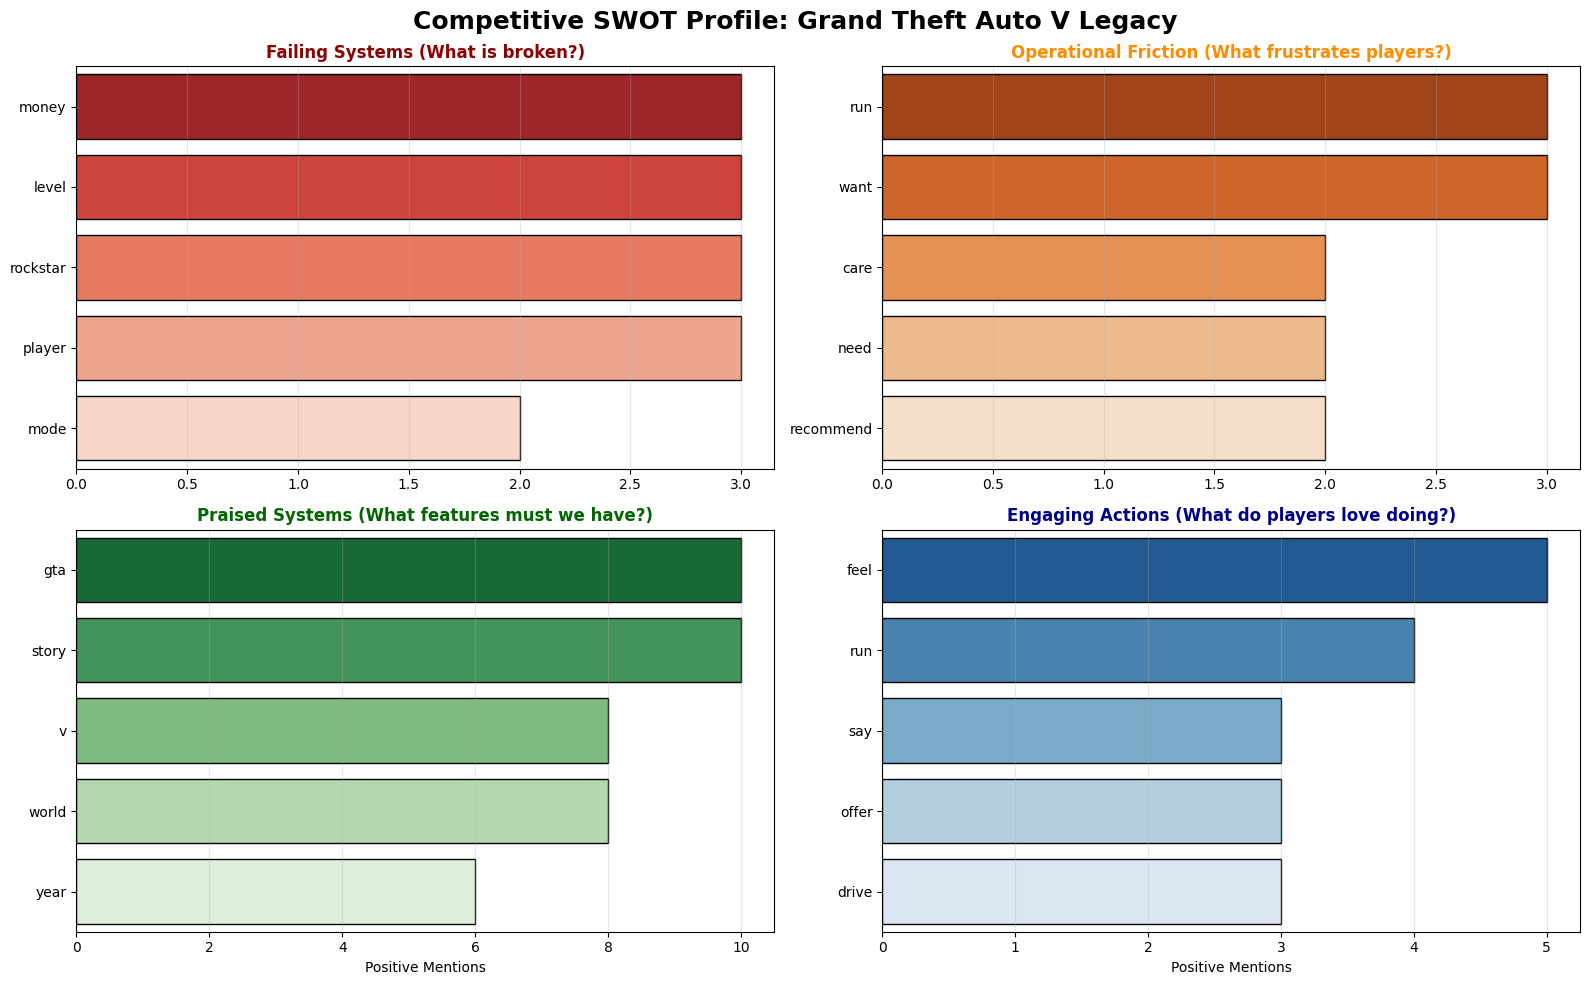

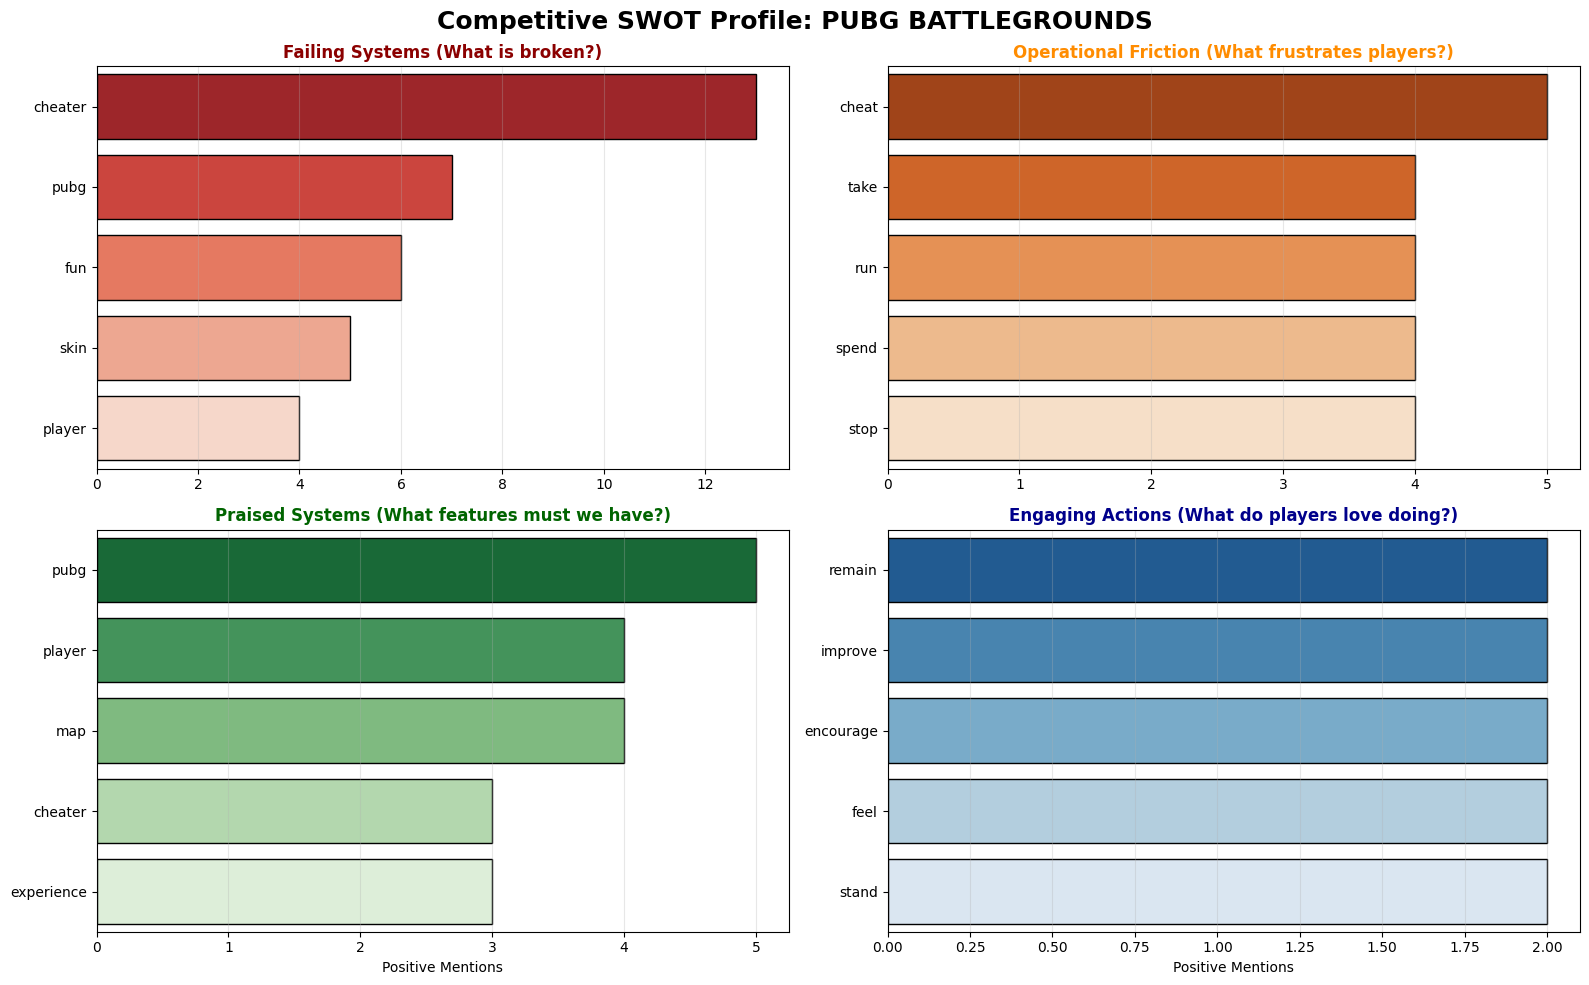

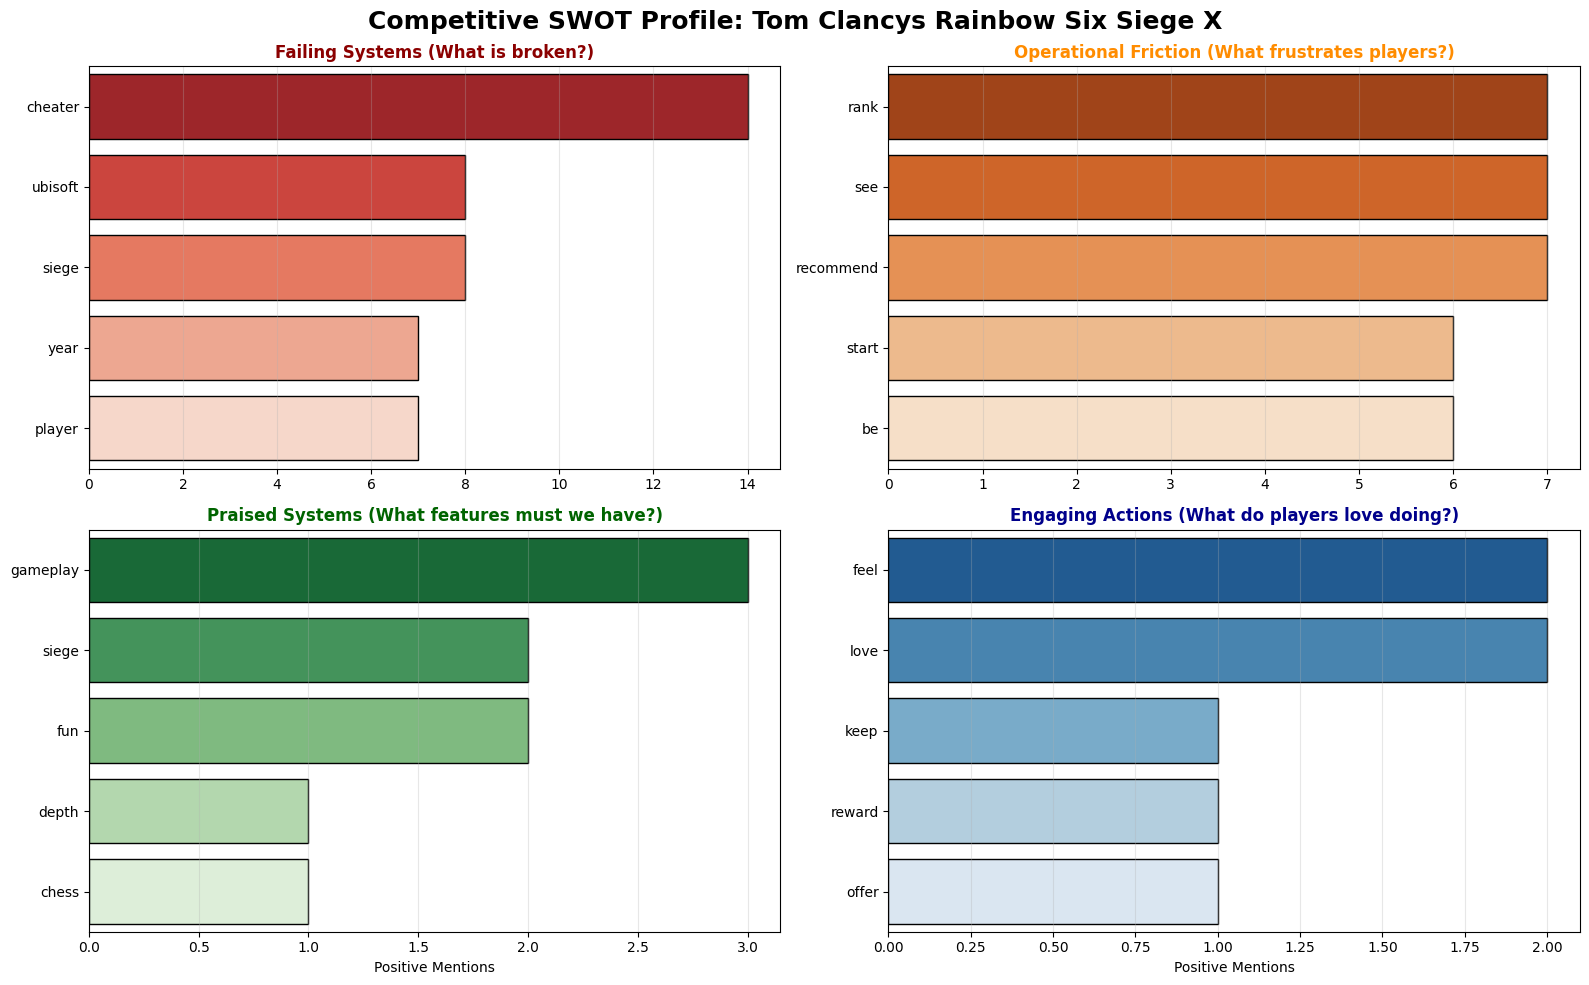

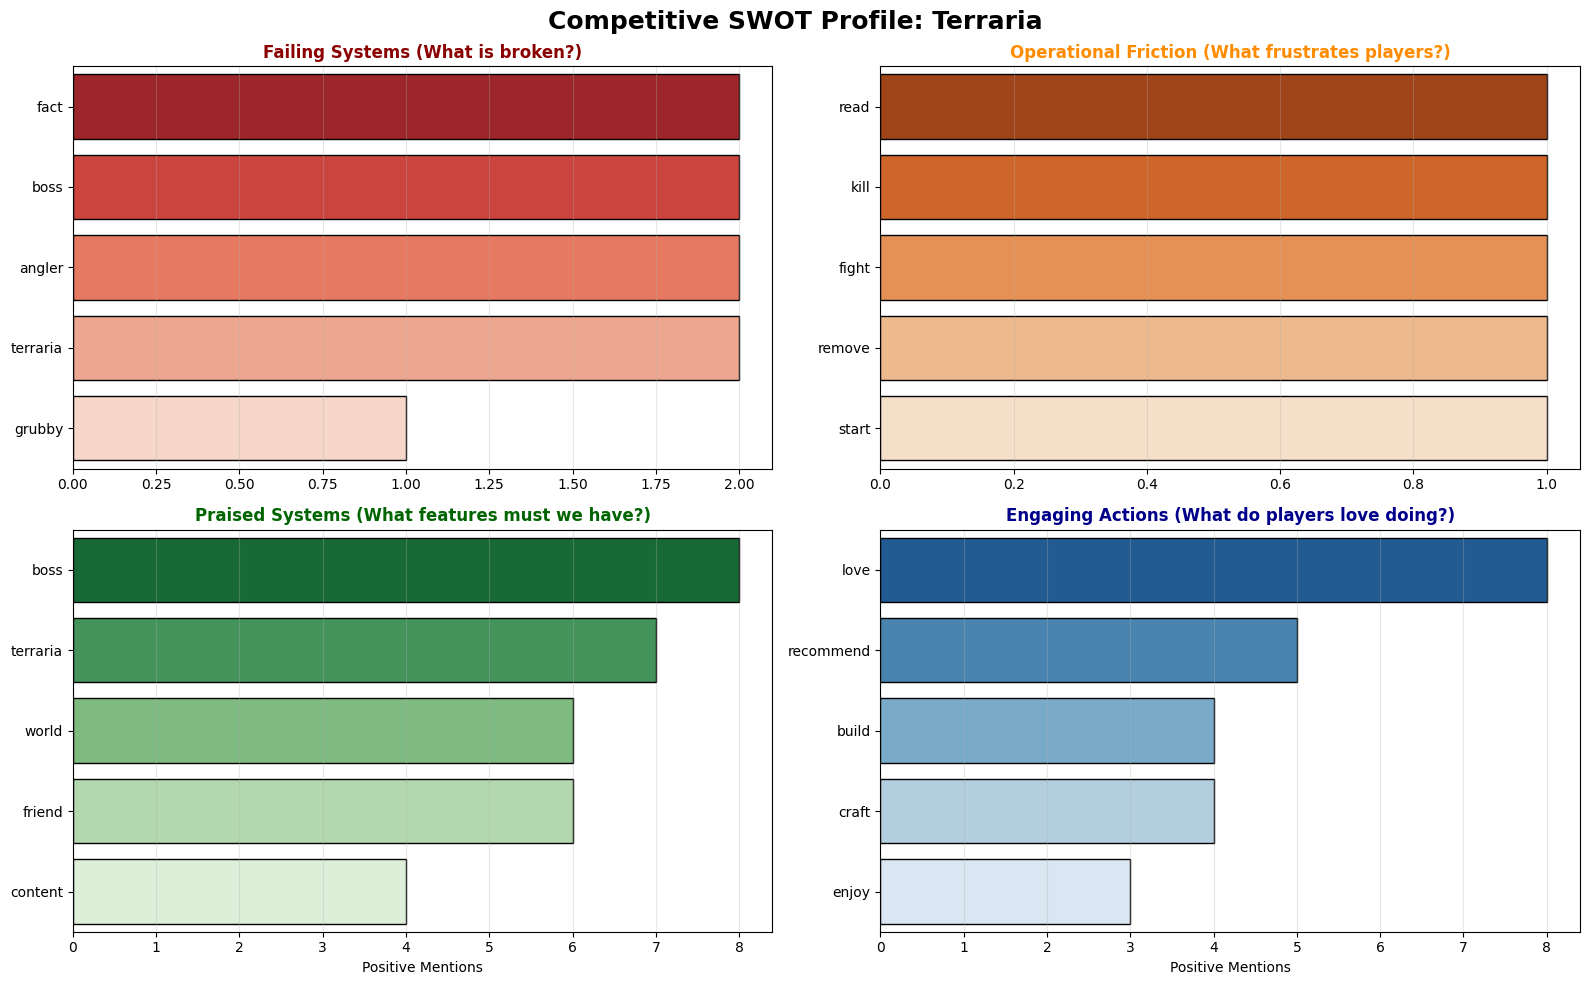

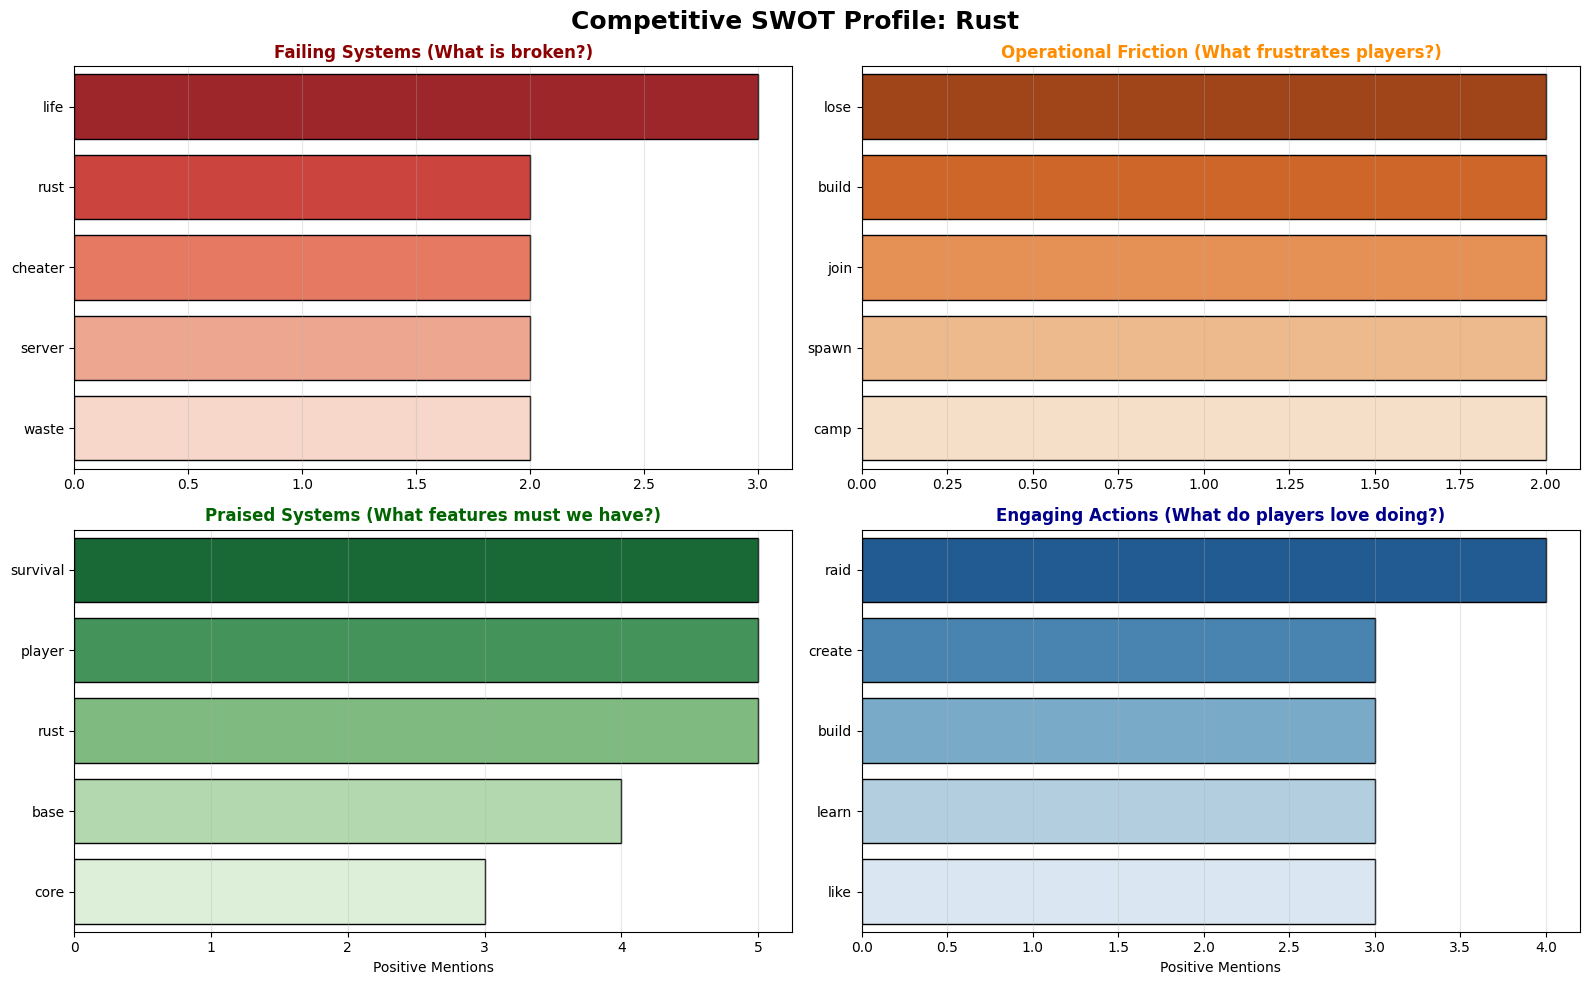

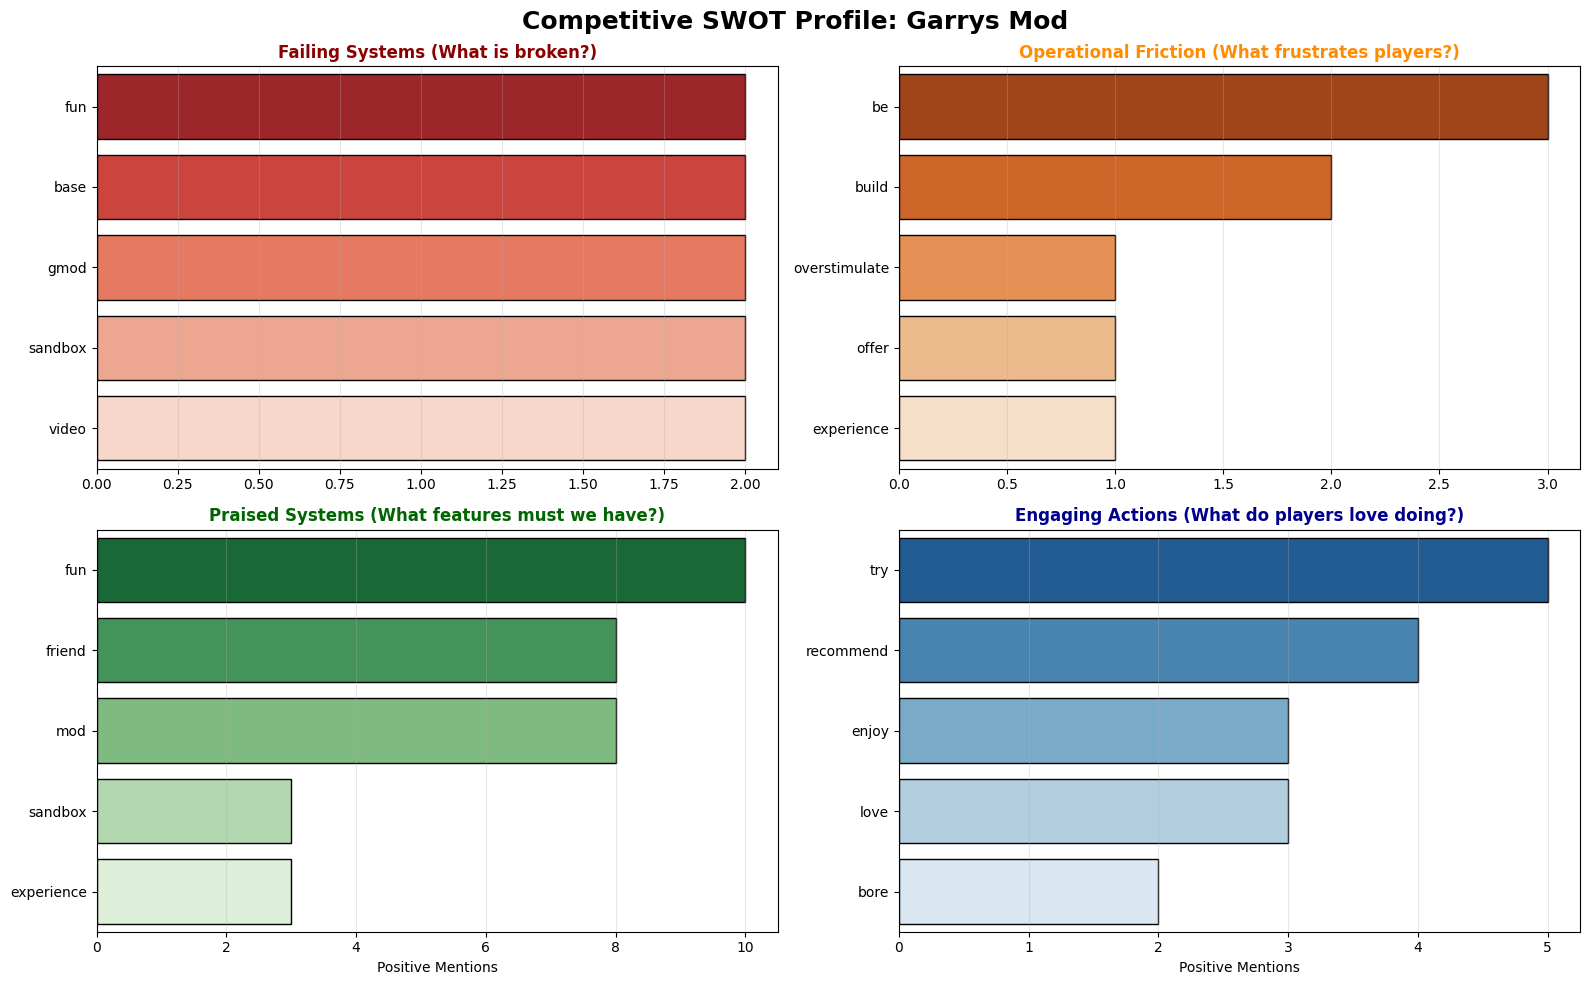

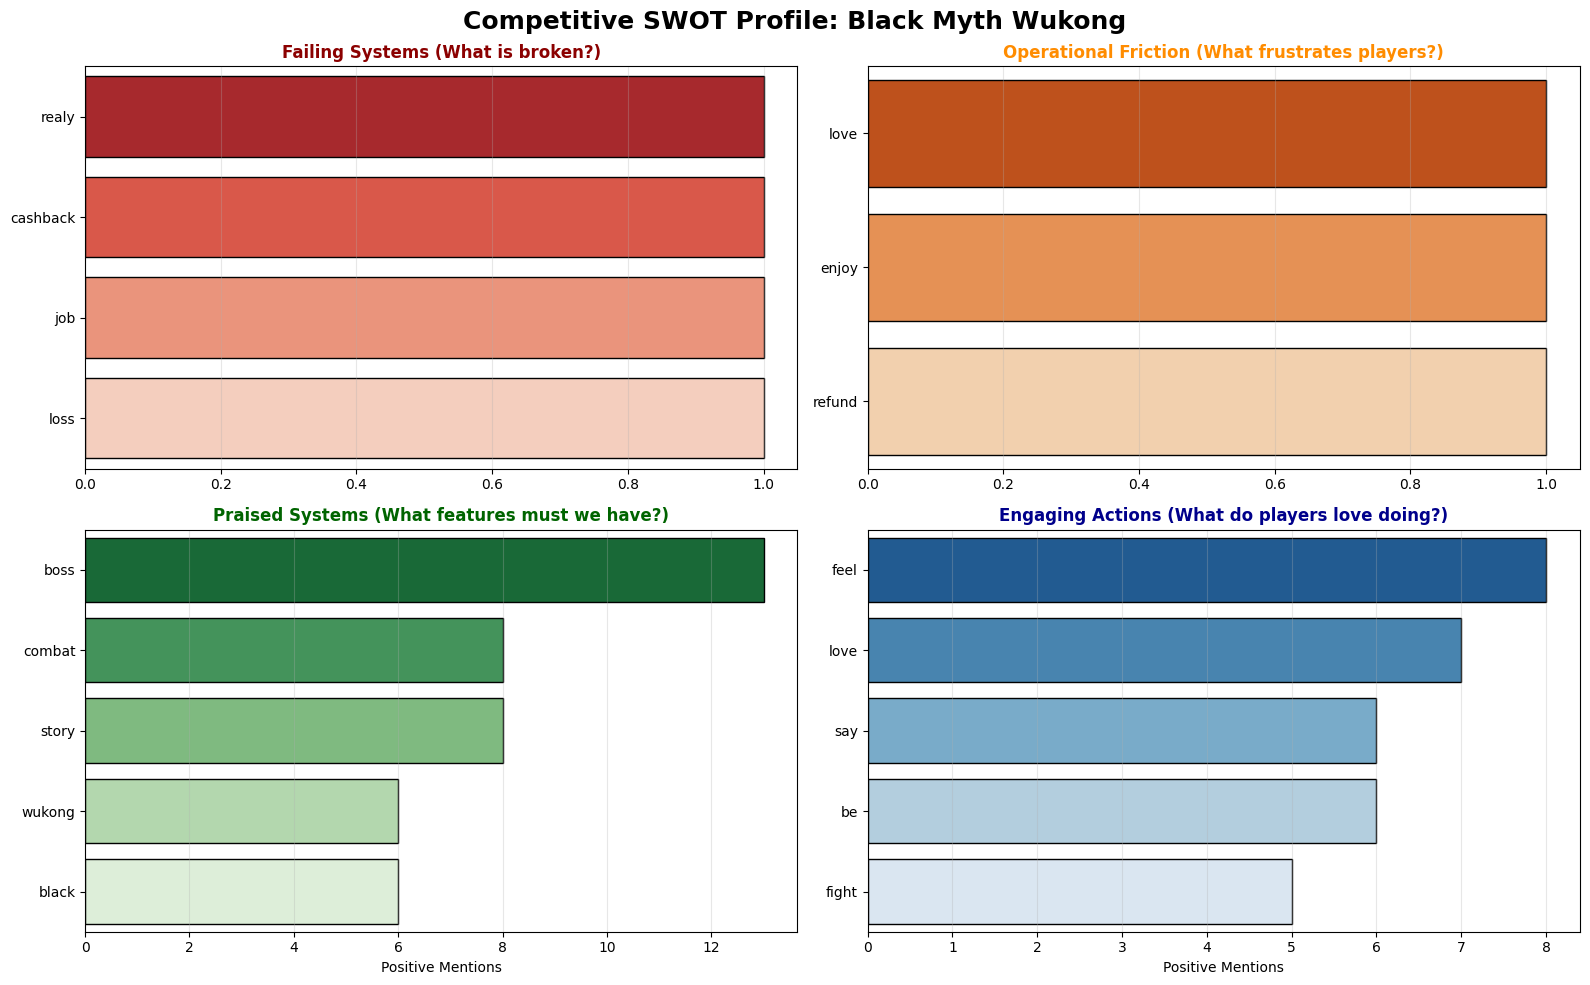

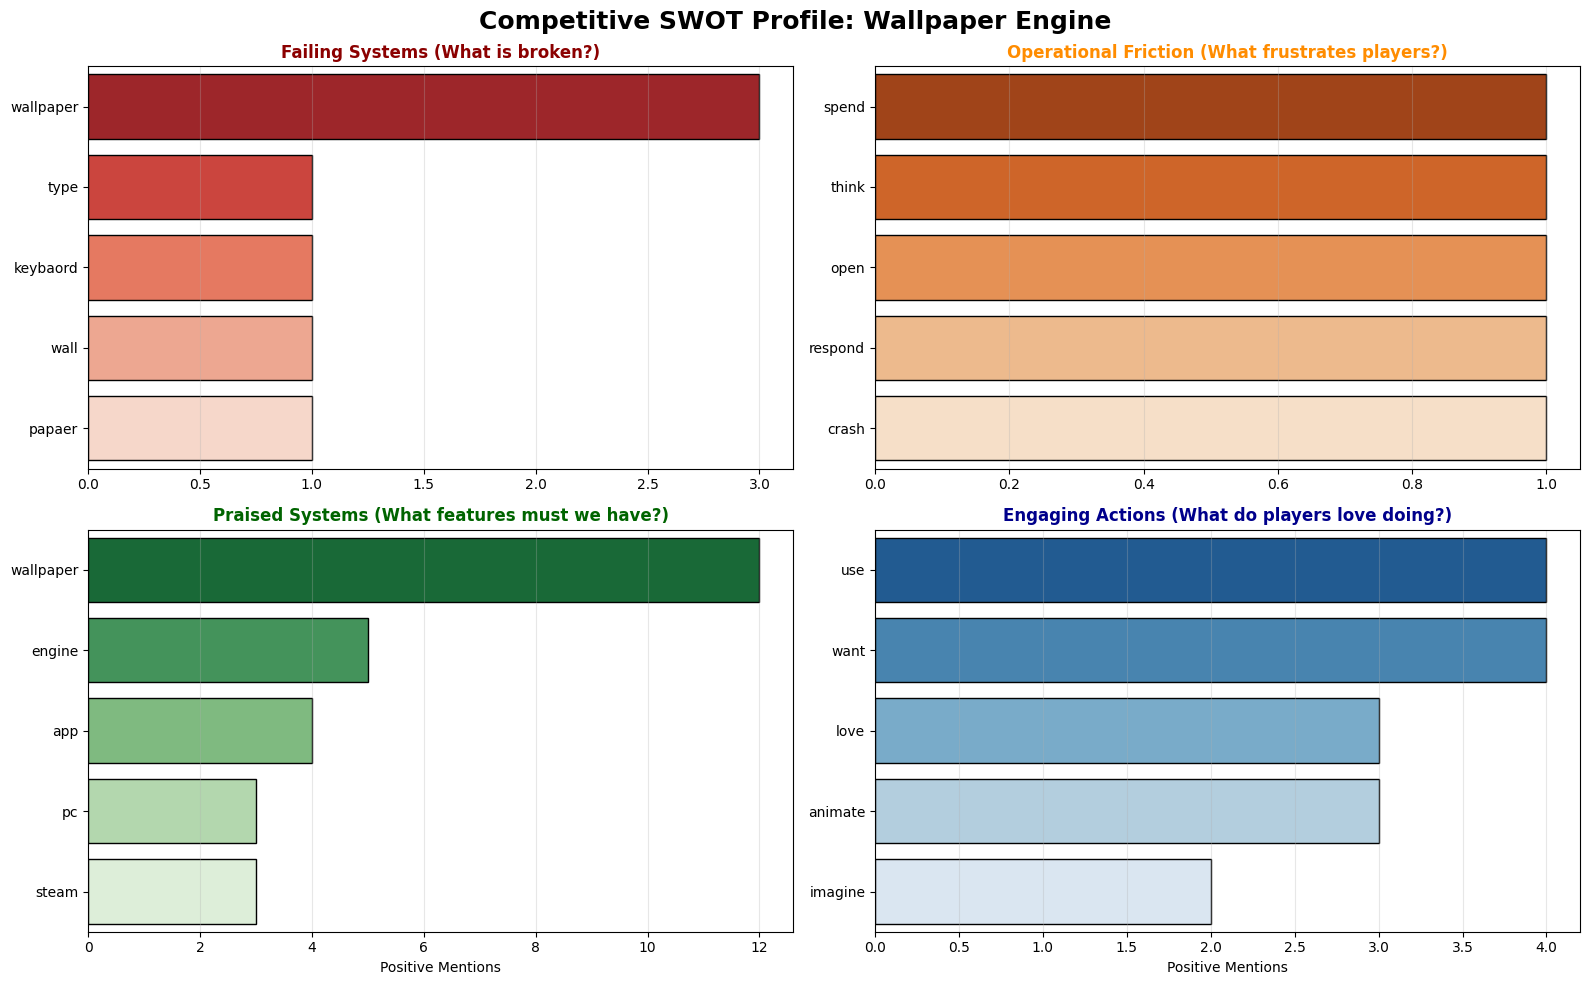

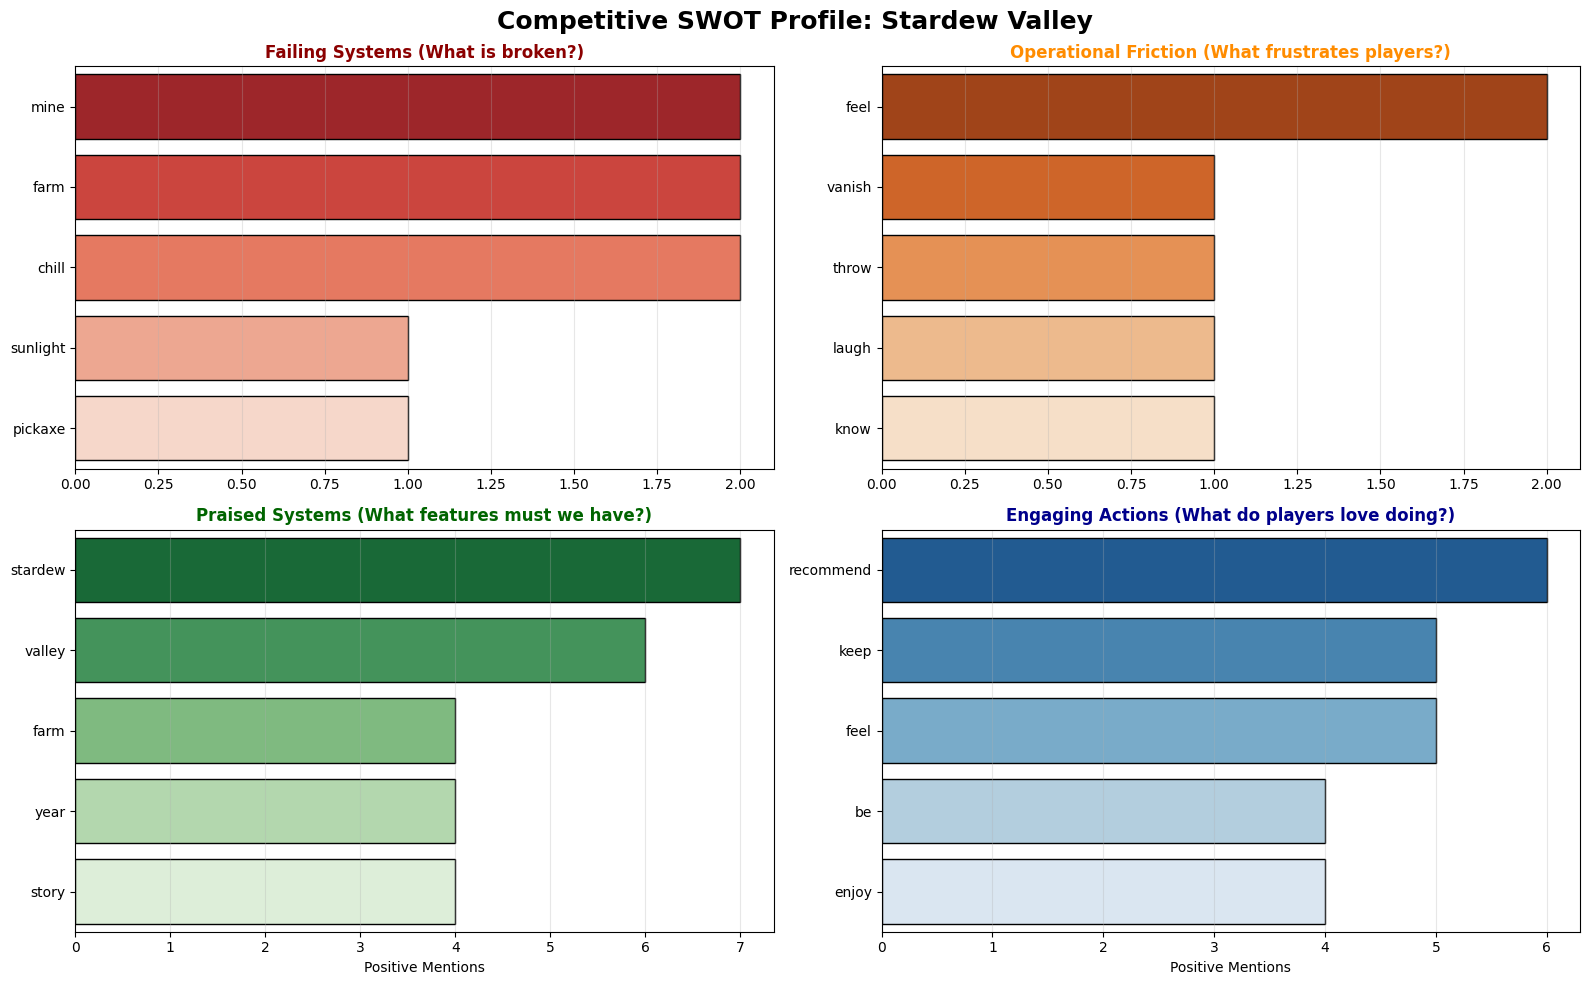

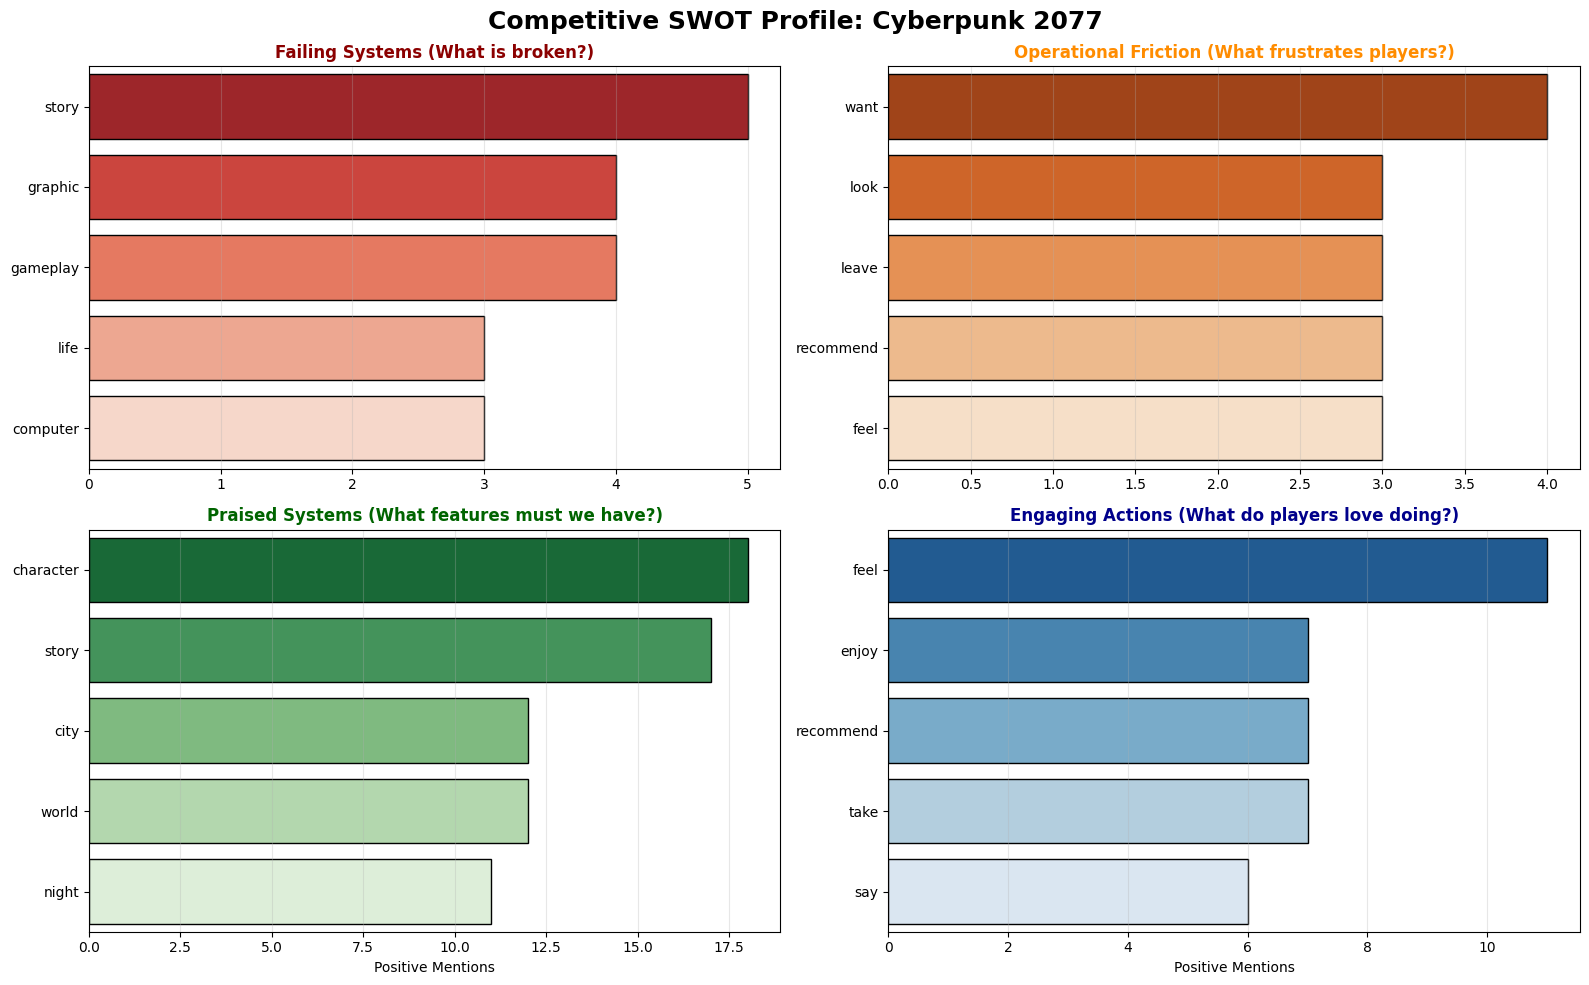

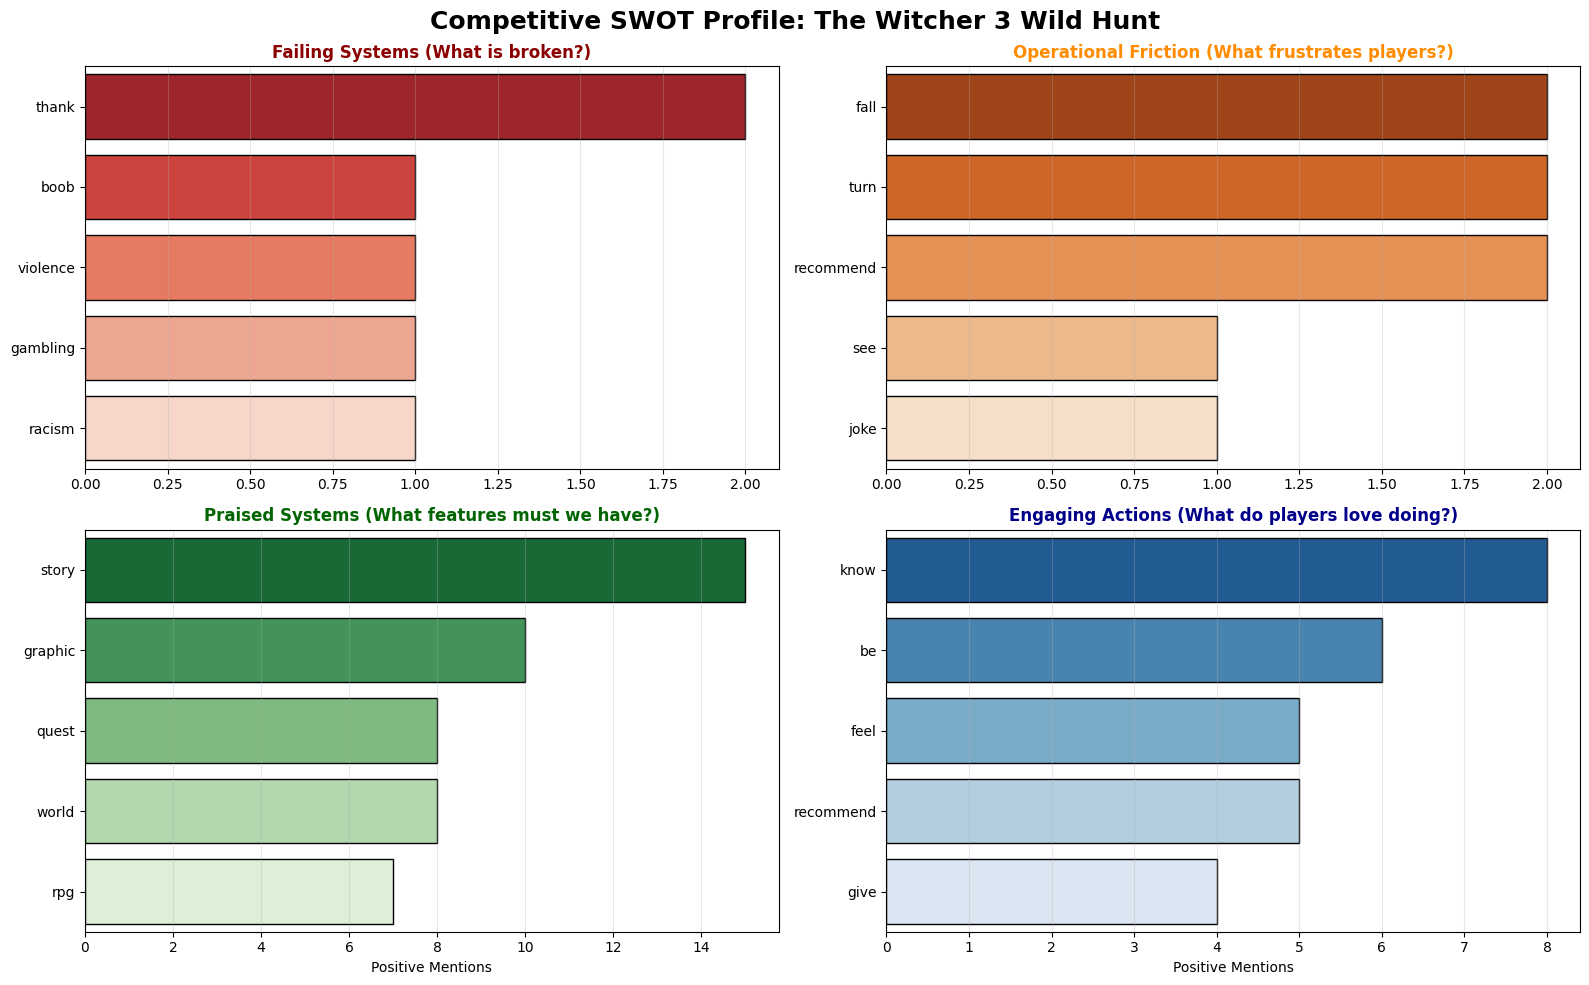

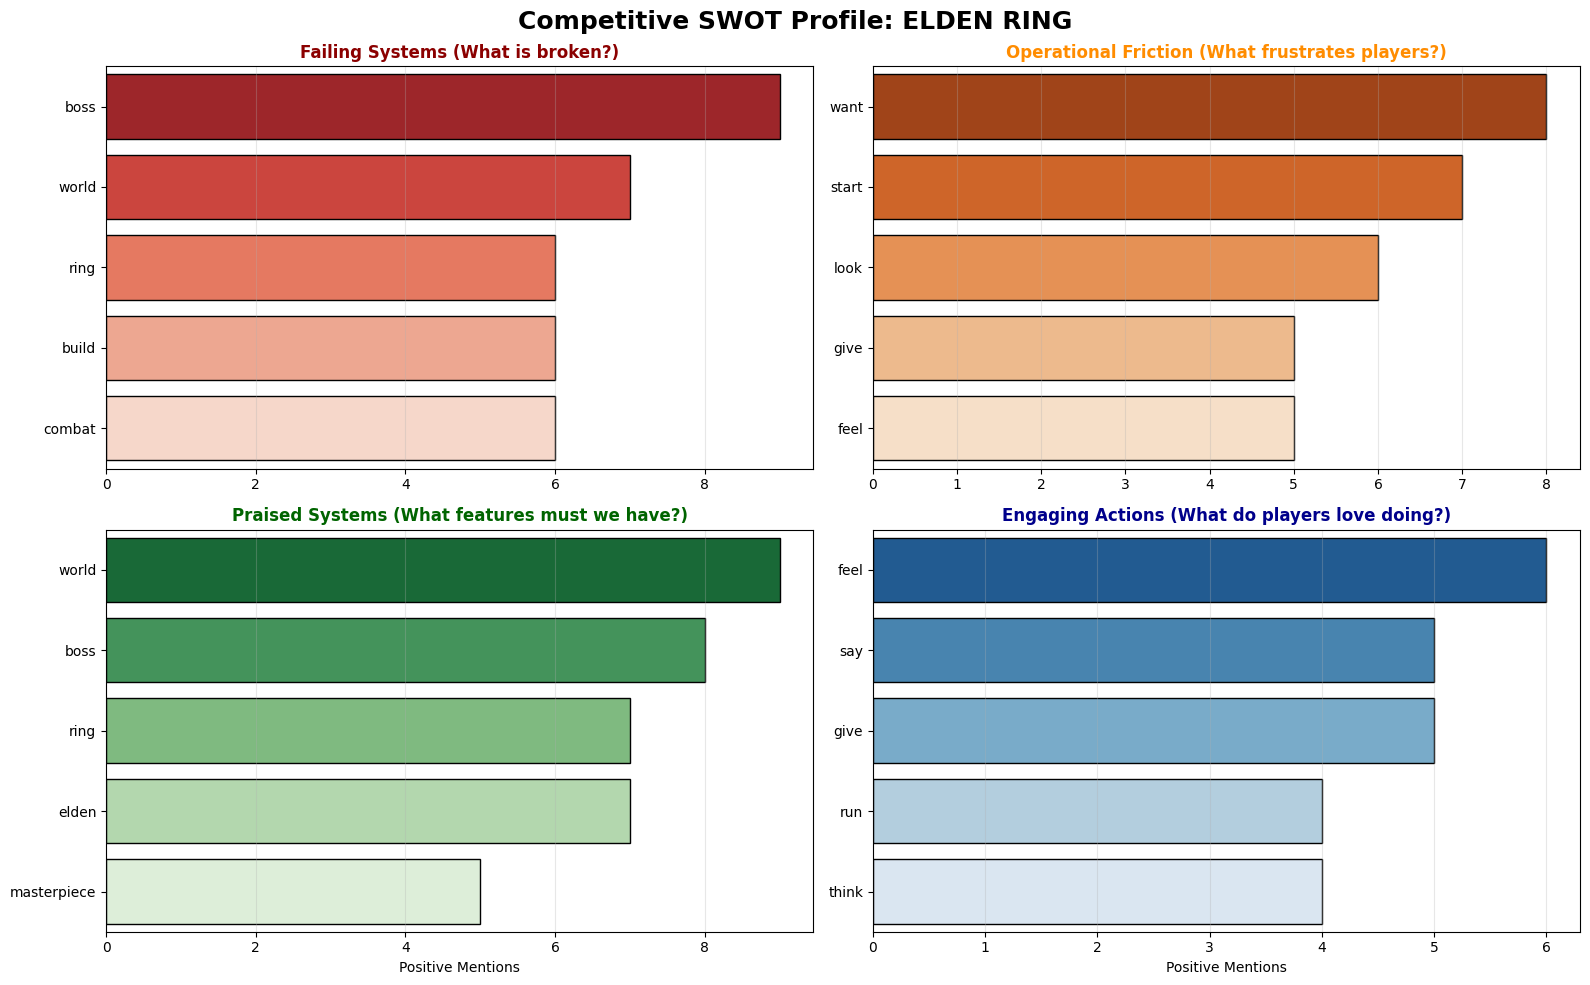

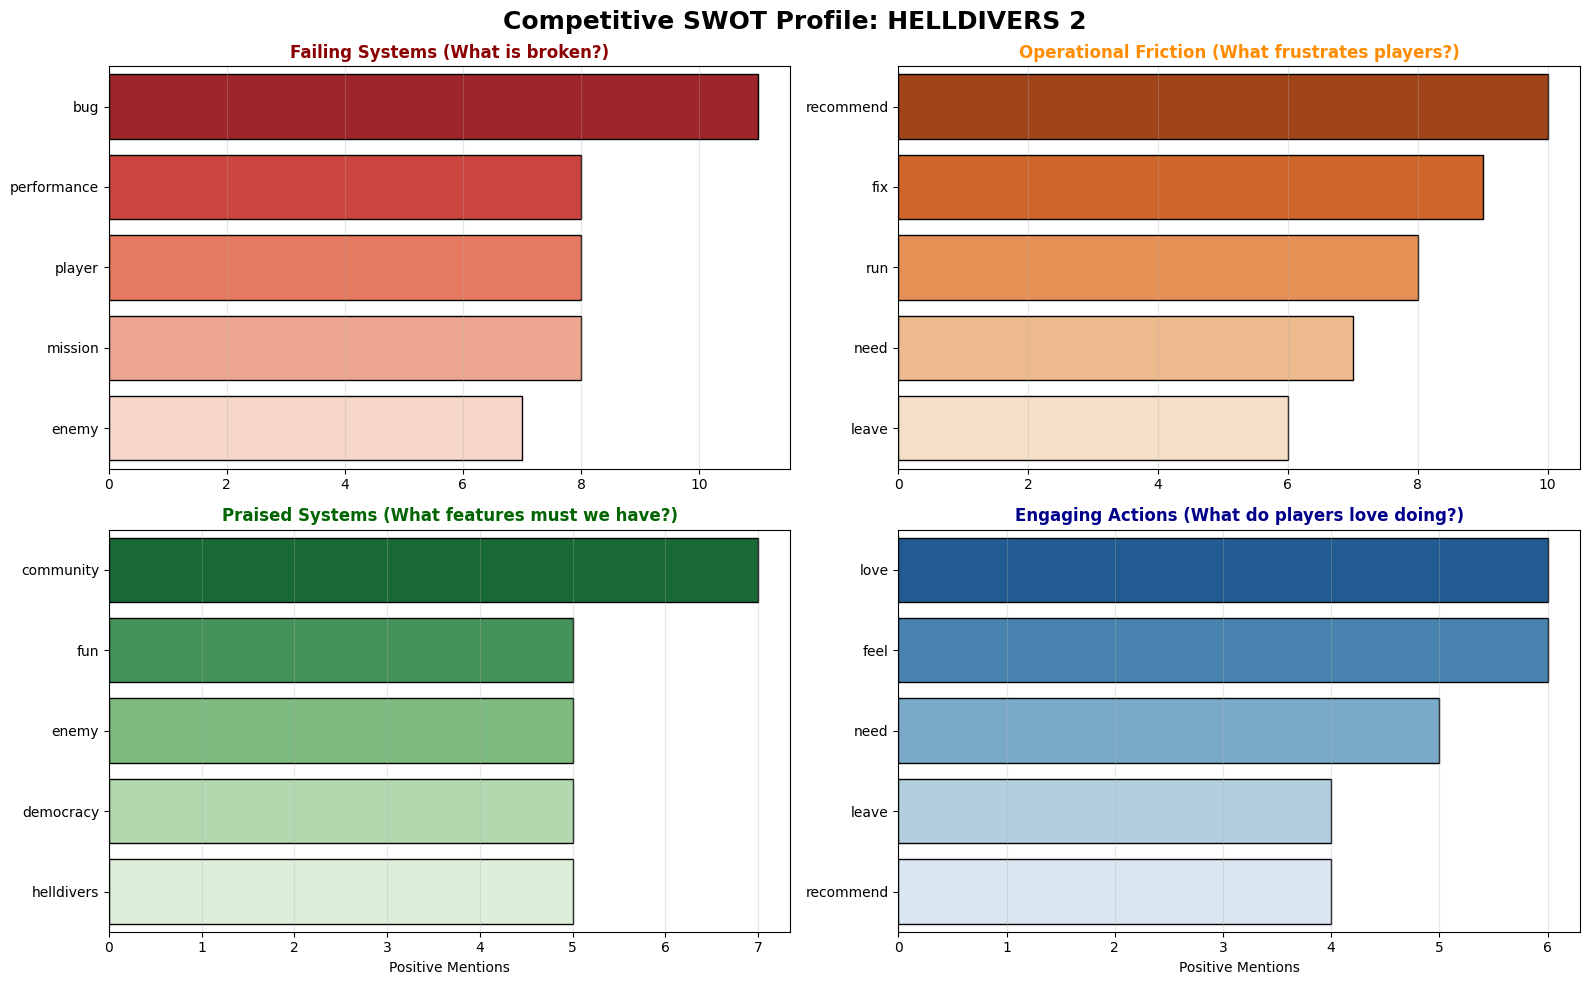

In [ ]:
# 1. Generate the list of individual game dataframes
df_list = [get_player_sentiment_v2(appid, reviews_cleaned) for appid in top_games_accurate['appid'].tolist() if appid is not None]

# 2. Filter out any empty dataframes to prevent the "FutureWarning"
valid_dfs = [df for df in df_list if not df.empty]

# 3. Concatenate and Plot safely
if valid_dfs:
    master_df = pd.concat(valid_dfs, ignore_index=True)
    plot_full_competitor_swot(master_df, market_df)
else:
    print("No valid reviews found to plot.")

---------------------------

# Sentimental Analisys - average sentiment & final print

In [ ]:
def display_competitor_health_summary(master_sentiment_df, reference_df):
    """
    Calculates the Positive/Negative sentiment ratio from the NLP dataset
    and compares it to the official Metacritic Press Score.
    """

    unique_appids = master_sentiment_df['appid'].unique()
    summary_data = []

    for appid in unique_appids:
        # 1. Fetch Game Name and Metacritic Score
        game_info = reference_df[reference_df['appid'] == appid]
        game_name = game_info['name'].values[0] if not game_info.empty else f"Unknown ({appid})"

        # Handle missing or NaN metacritic scores safely
        meta_score = game_info['metacritic_score'].values[0] if not game_info.empty else 0
        if pd.isna(meta_score) or meta_score == 0:
            meta_string = "N/A"
        else:
            meta_string = f"{int(meta_score)}/100"

        # 2. Calculate Sentiment Ratios from our NLP sample
        game_df = master_sentiment_df[master_sentiment_df['appid'] == appid]
        total_reviews = len(game_df)

        if total_reviews > 0:
            pos_count = len(game_df[game_df['sentiment_label'] == 'POSITIVE'])
            neg_count = len(game_df[game_df['sentiment_label'] == 'NEGATIVE'])

            pos_pct = (pos_count / total_reviews) * 100
            neg_pct = (neg_count / total_reviews) * 100
        else:
            pos_pct = 0
            neg_pct = 0

        summary_data.append({
            'Game Name': game_name,
            'Metacritic Score (Press)': meta_string,
            'NLP Positive % (Players)': f"{pos_pct:.1f}%",
            'NLP Negative % (Players)': f"{neg_pct:.1f}%",
            'Sample Size (Reviews)': total_reviews
        })

    # Convert to DataFrame and display cleanly
    summary_df = pd.DataFrame(summary_data)

    # Highlight the table slightly for the presentation
    def highlight_cols(s):
        if s.name == 'NLP Positive % (Players)':
            return ['background-color: #e6ffe6'] * len(s) # Light green
        elif s.name == 'NLP Negative % (Players)':
            return ['background-color: #ffe6e6'] * len(s) # Light red
        return [''] * len(s)

    display(summary_df.style.apply(highlight_cols))


Extracting NLP Sentiment & PoS Tags...
Processing 33 reviews for AppID 271590...
Processing 34 reviews for AppID 578080...
Processing 43 reviews for AppID 359550...
Processing 29 reviews for AppID 105600...
Processing 28 reviews for AppID 252490...
Processing 27 reviews for AppID 4000...
Processing 17 reviews for AppID 2358720...
Processing 18 reviews for AppID 431960...
Processing 30 reviews for AppID 413150...
Processing 32 reviews for AppID 1091500...
Processing 35 reviews for AppID 292030...
Processing 36 reviews for AppID 1245620...
Processing 65 reviews for AppID 553850...
✅ Successfully compiled 427 total reviews.


,Game Name,Metacritic Score (Press),NLP Positive % (Players),NLP Negative % (Players),Sample Size (Reviews)
0,Grand Theft Auto V Legacy,96/100,60.6%,39.4%,33
1,PUBG BATTLEGROUNDS,N/A,35.3%,64.7%,34
2,Tom Clancys Rainbow Six Siege X,N/A,16.3%,83.7%,43
3,Terraria,83/100,79.3%,20.7%,29
4,Rust,69/100,60.7%,39.3%,28
5,Garrys Mod,N/A,70.4%,29.6%,27
6,Black Myth Wukong,N/A,94.1%,5.9%,17
7,Wallpaper Engine,N/A,72.2%,27.8%,18
8,Stardew Valley,89/100,86.7%,13.3%,30
9,Cyberpunk 2077,86/100,71.9%,28.1%,32



Generating Competitive SWOT Dashboards...
--- GENERATING COMPETITIVE SWOT DASHBOARDS ---


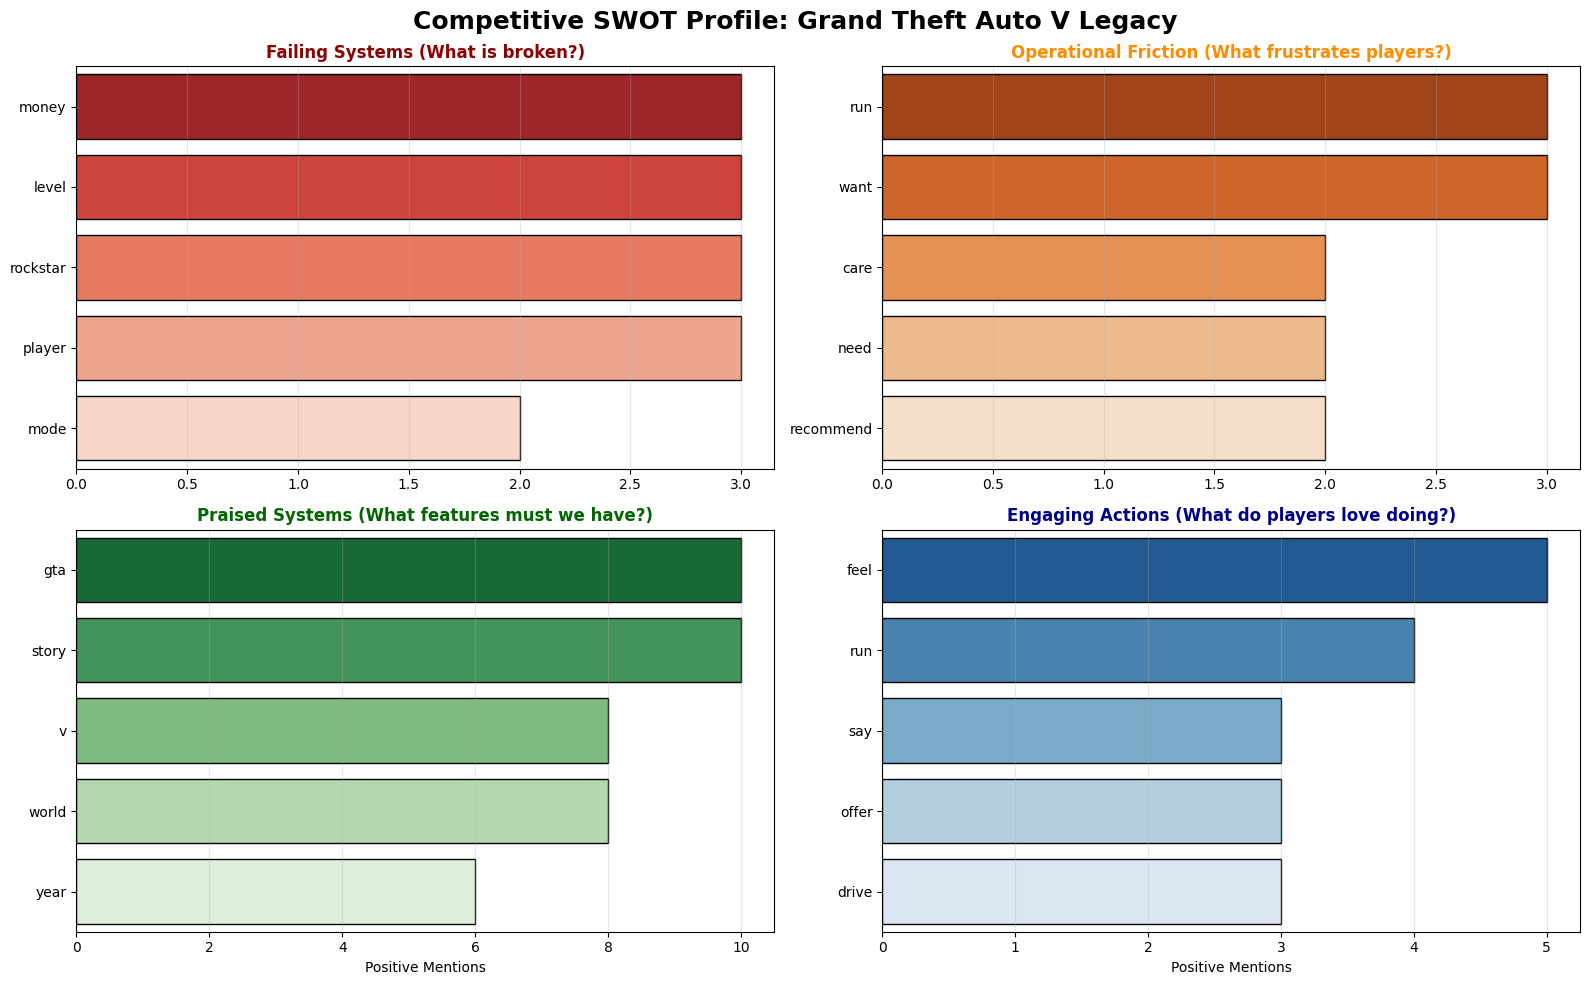

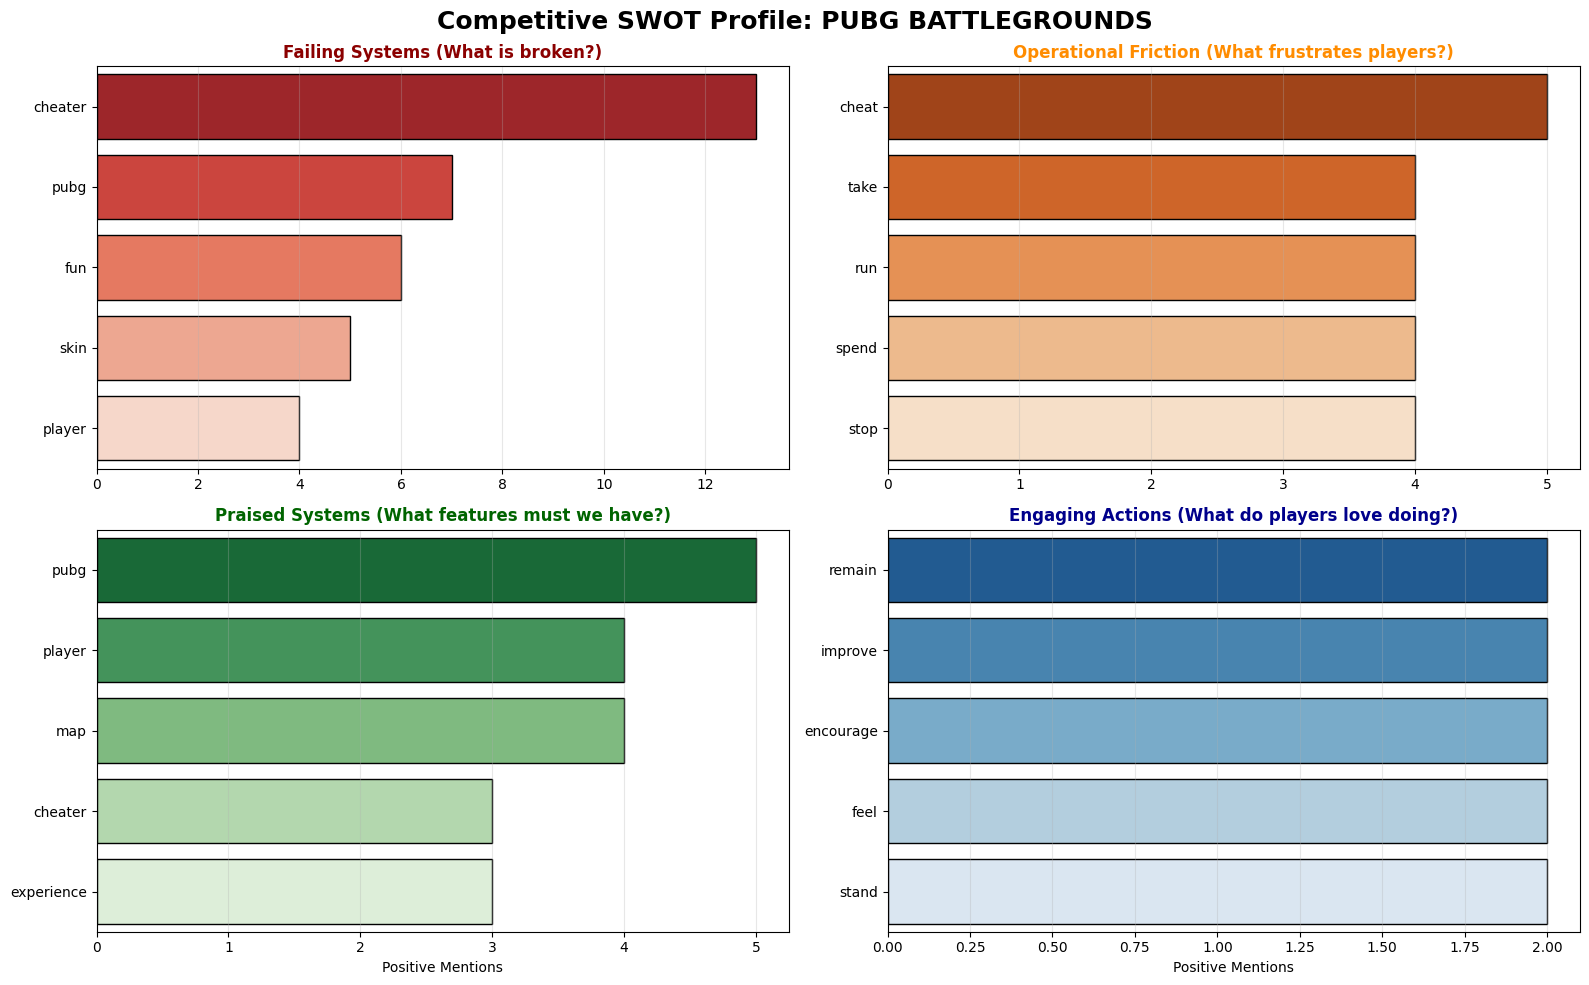

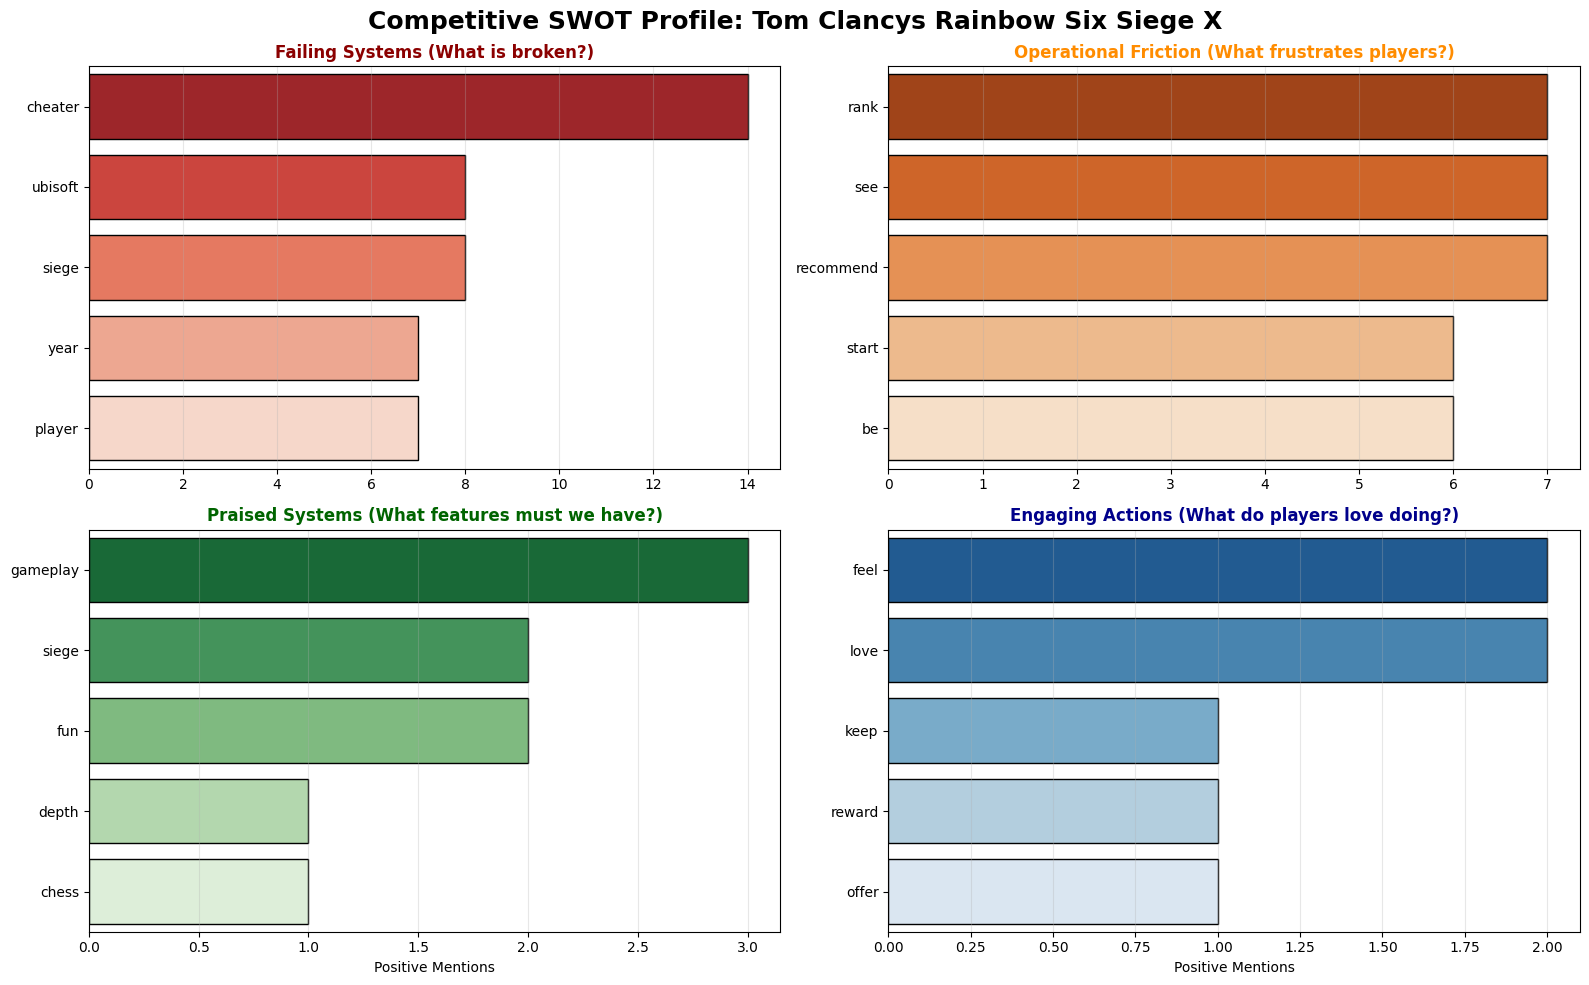

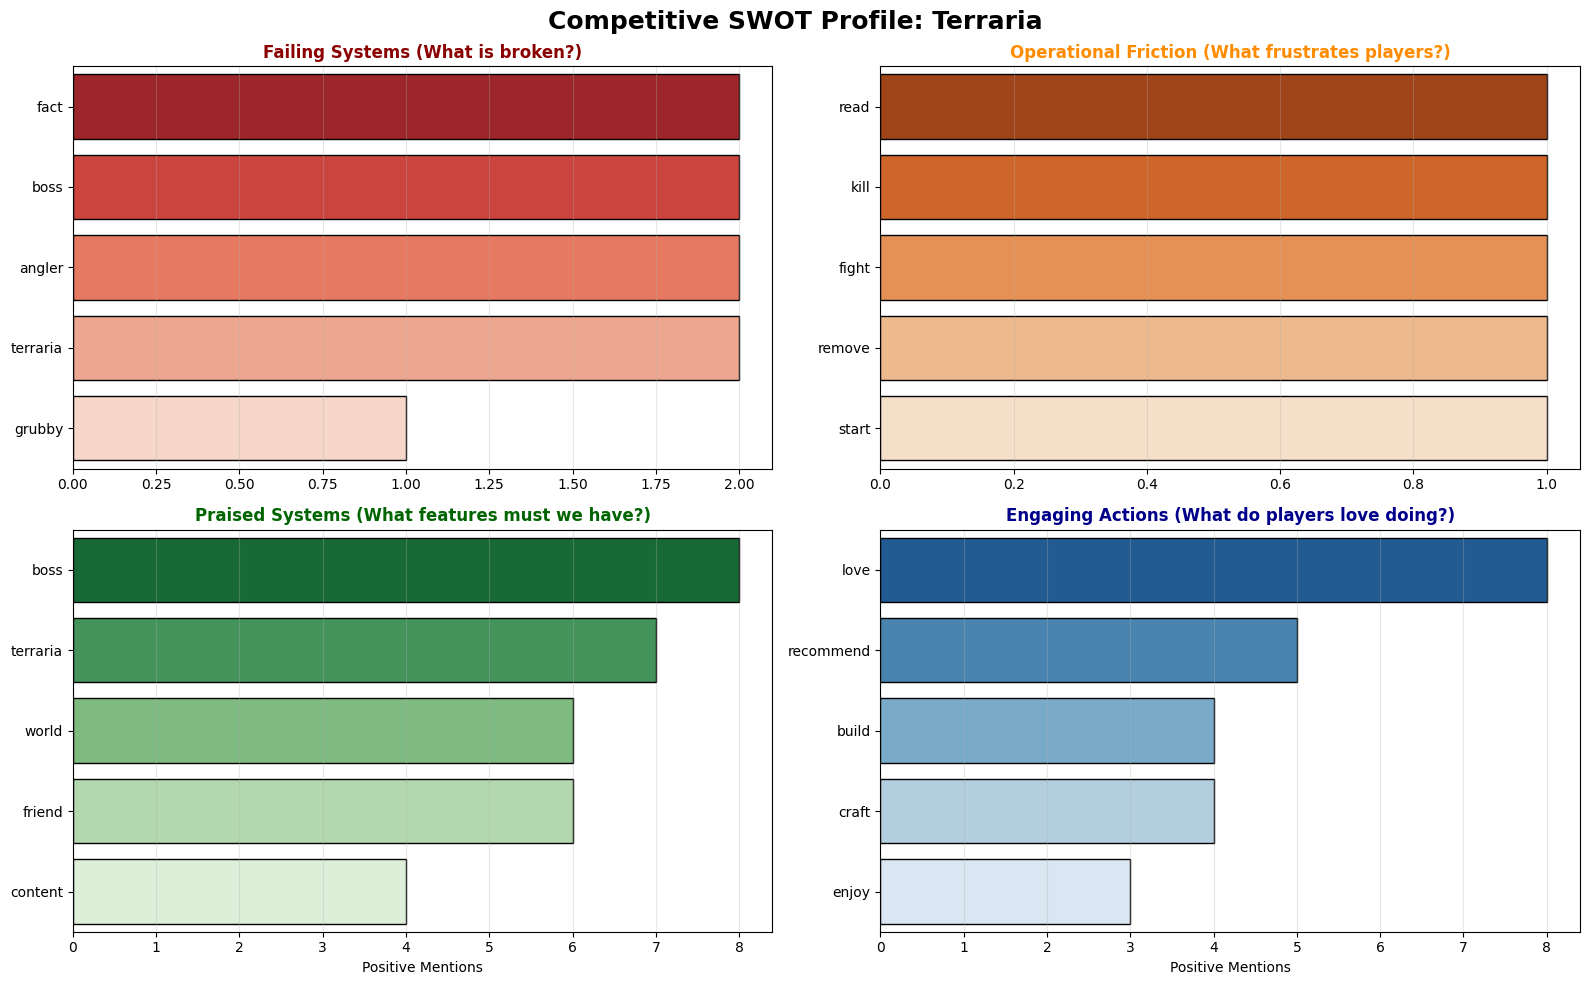

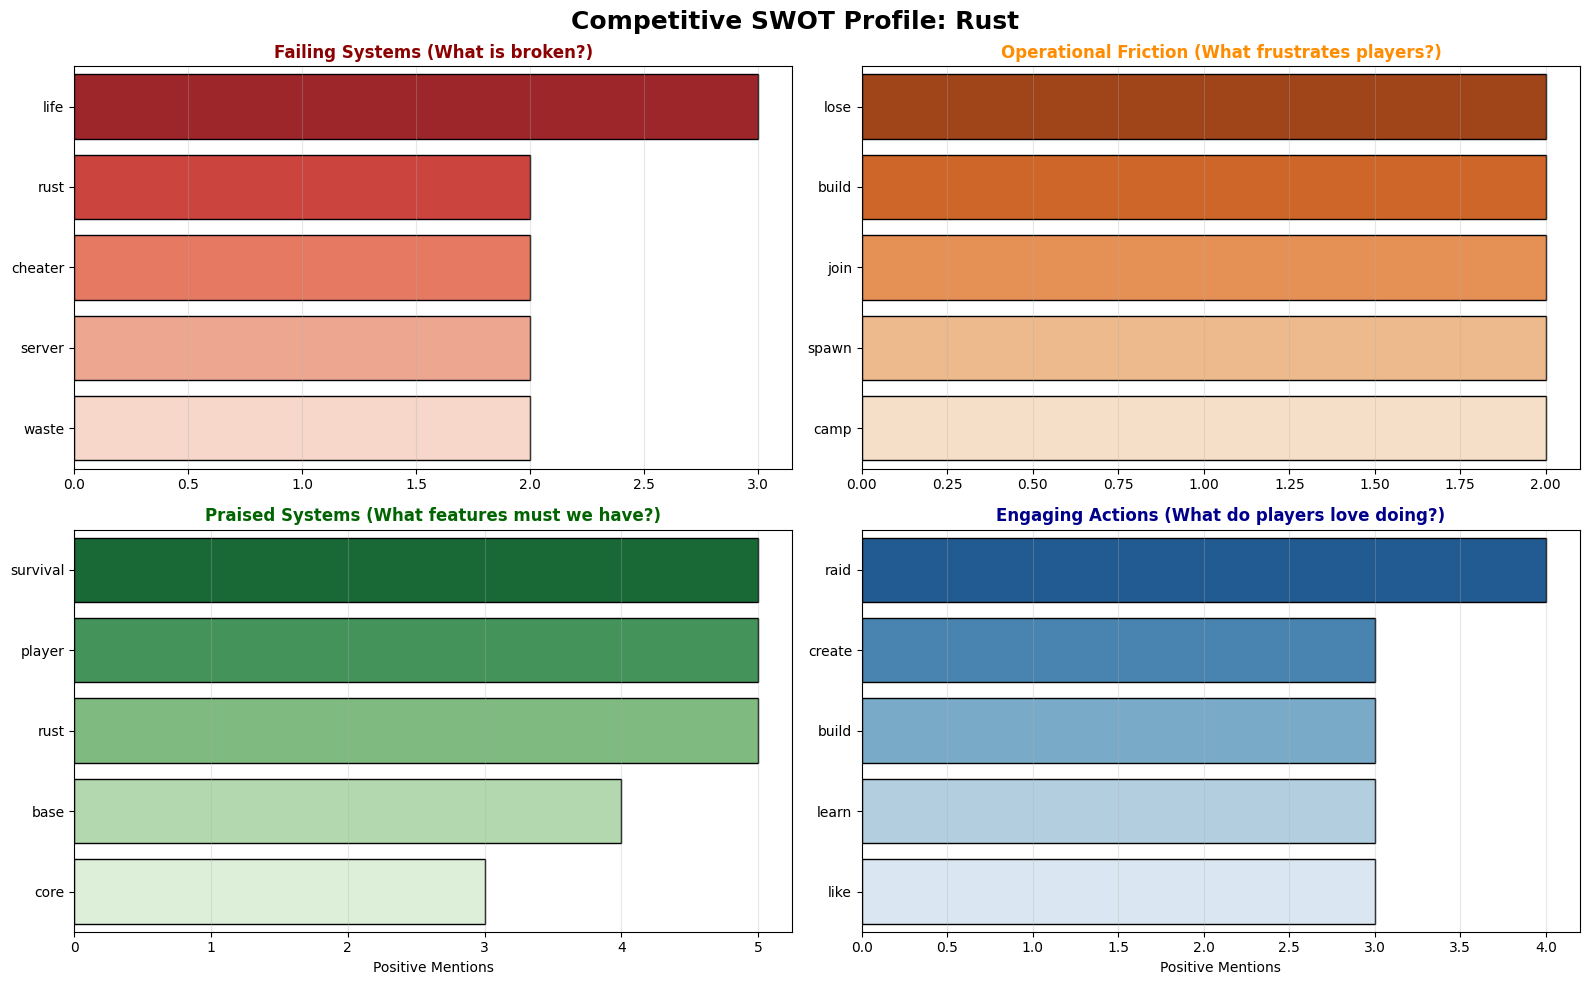

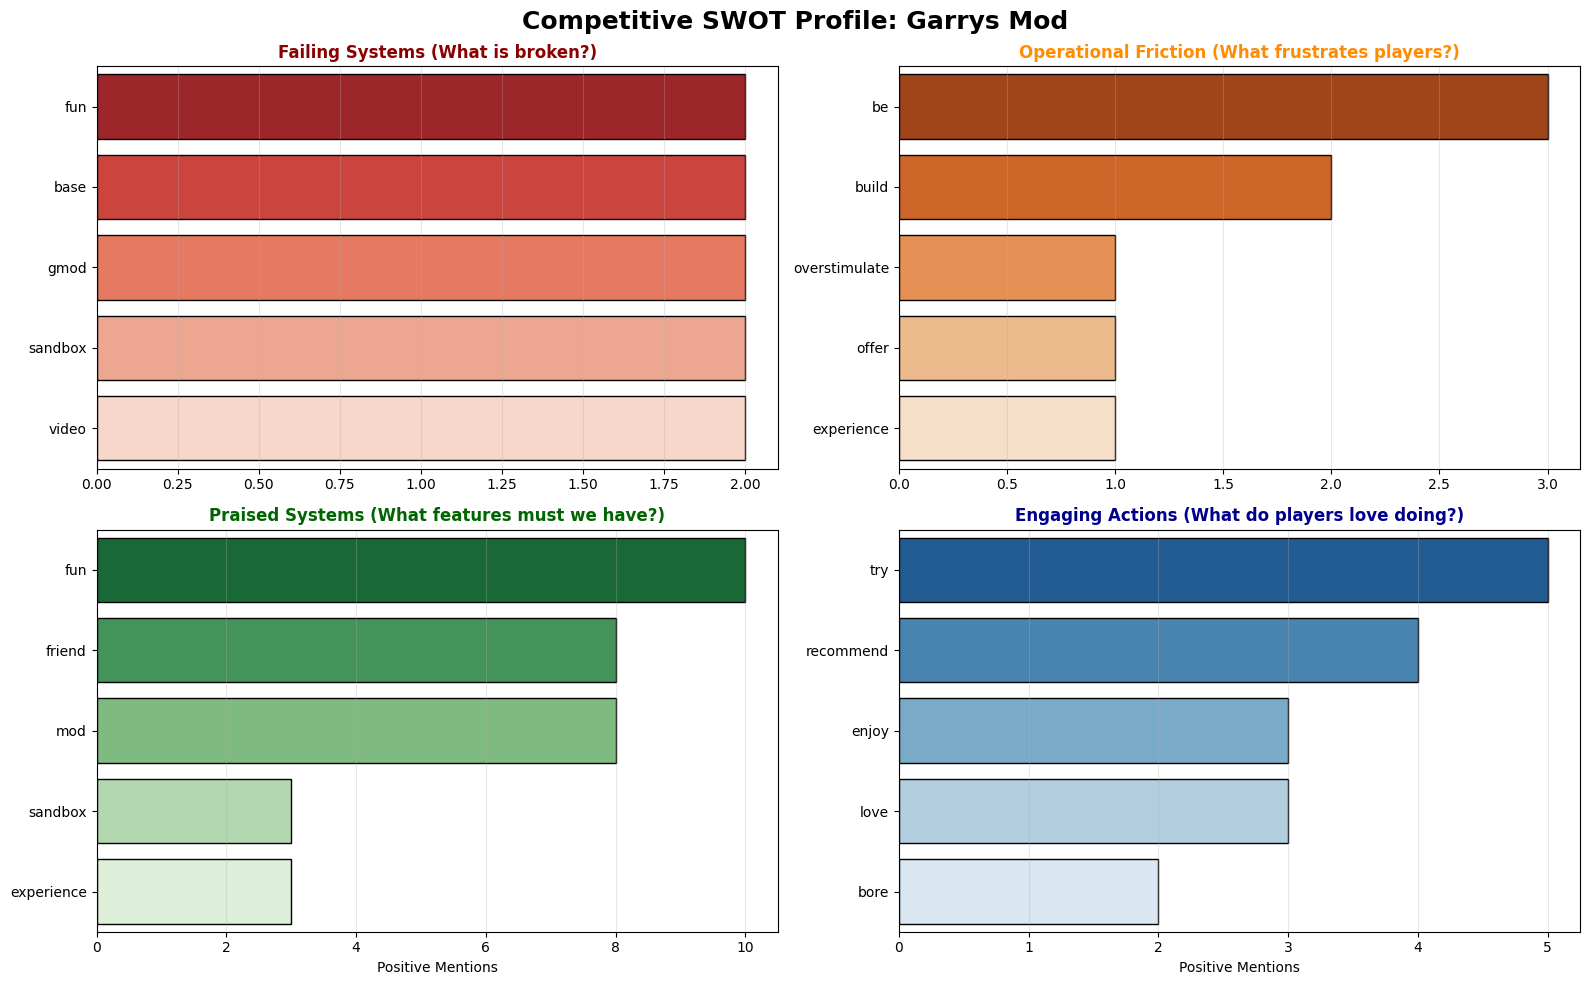

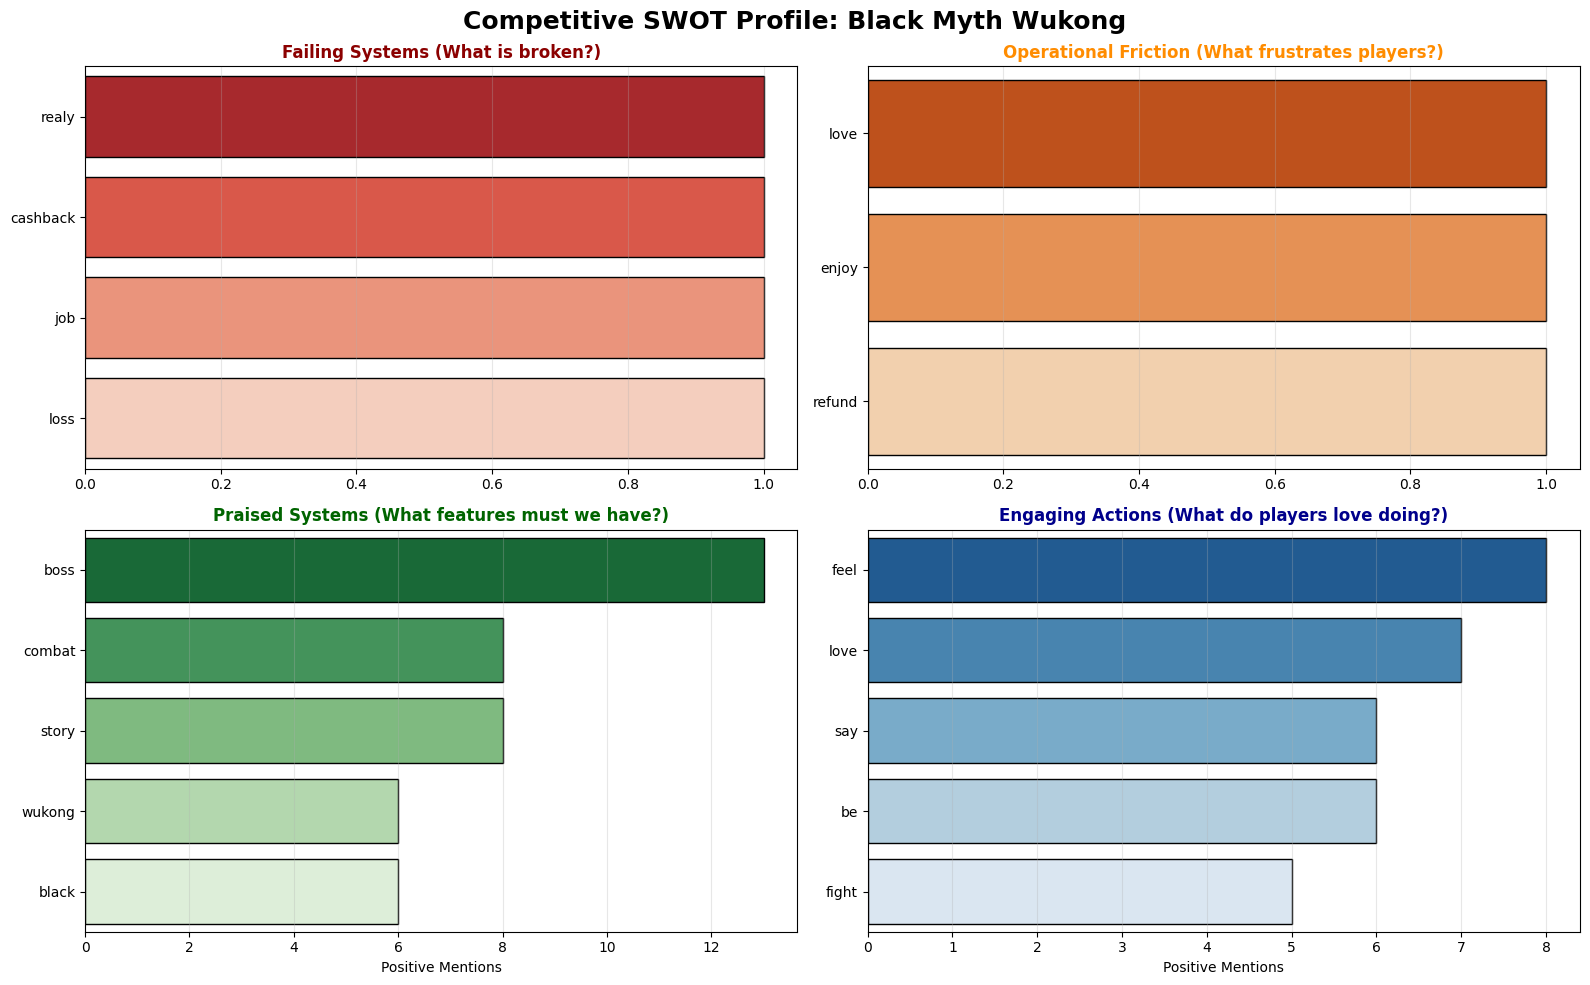

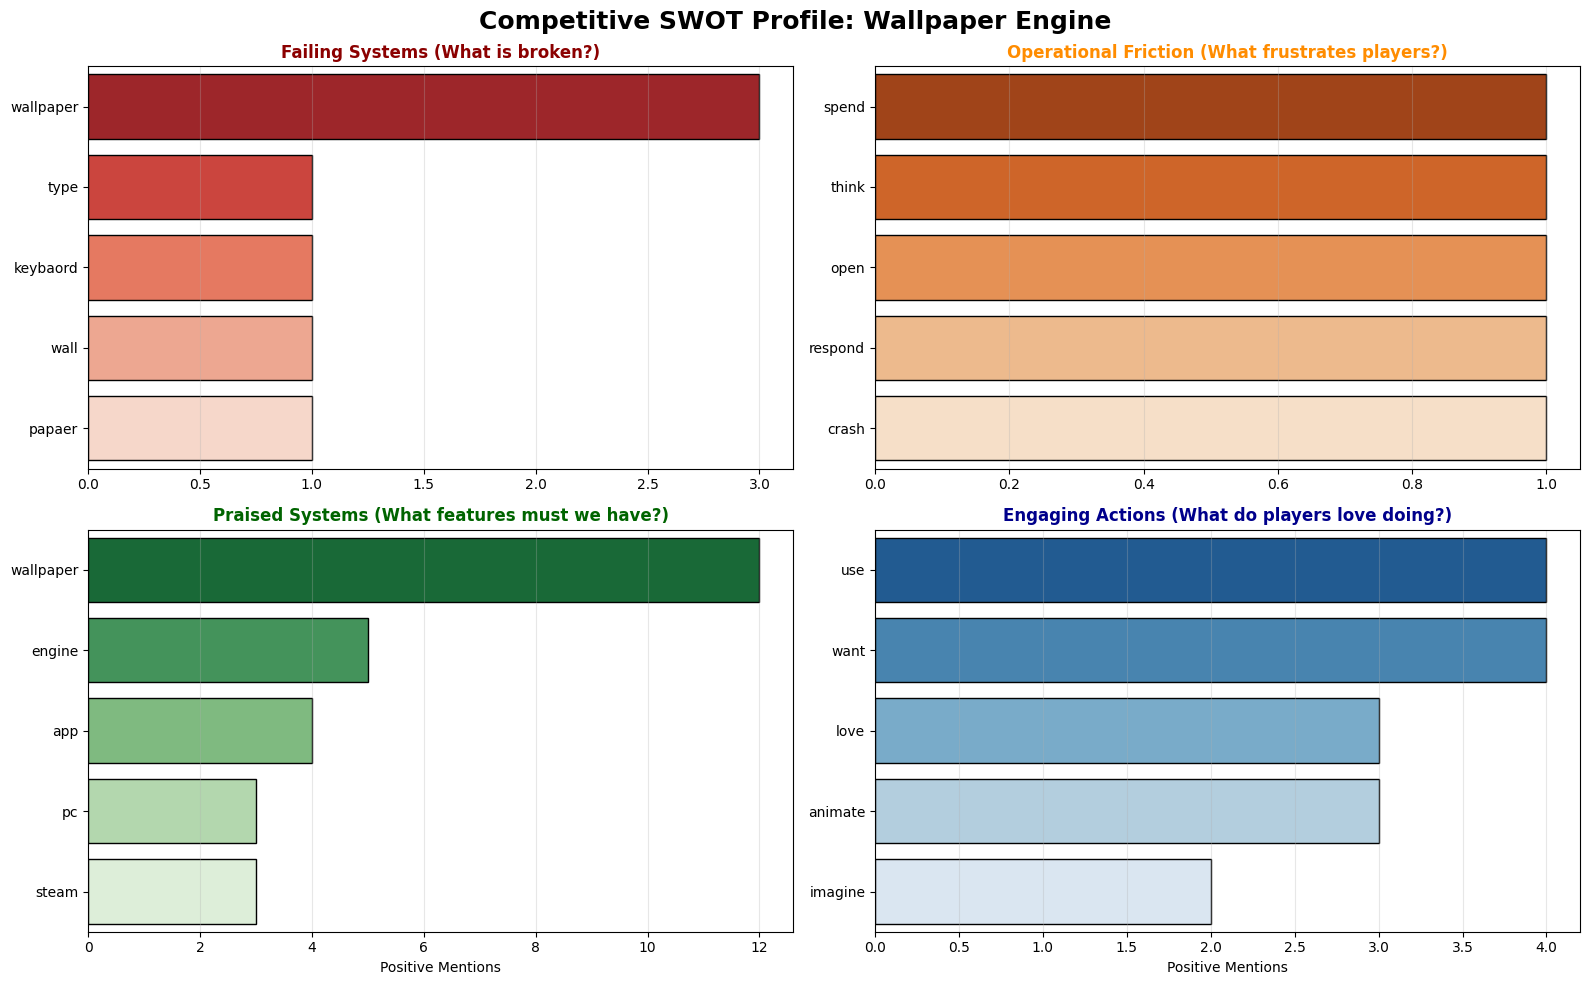

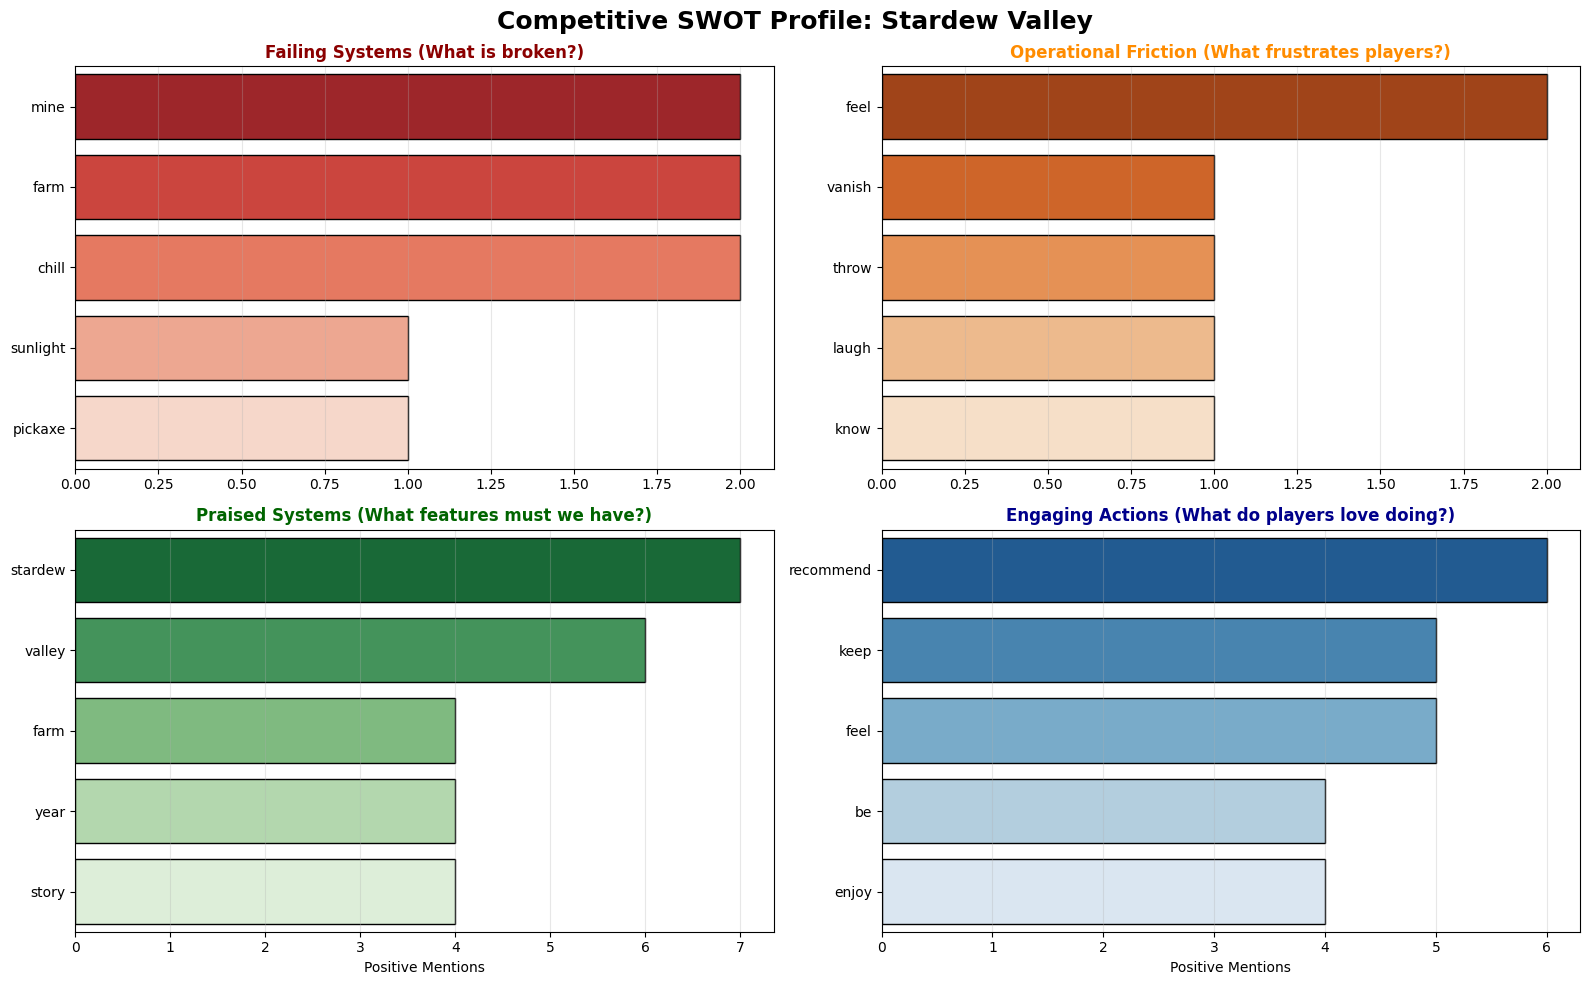

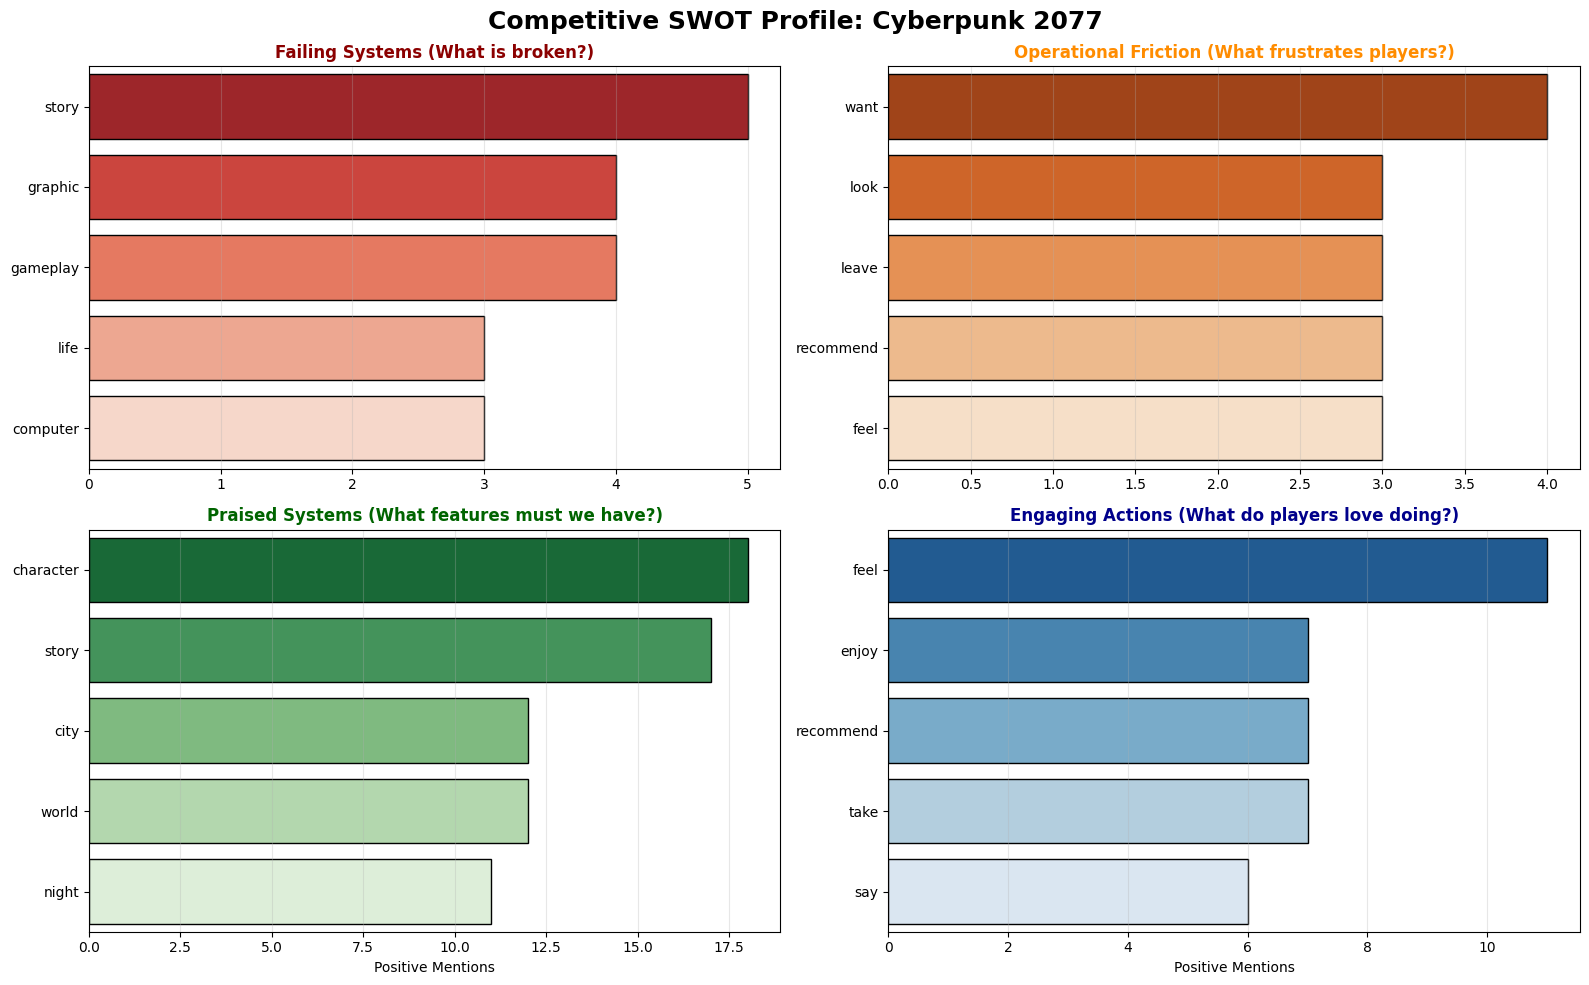

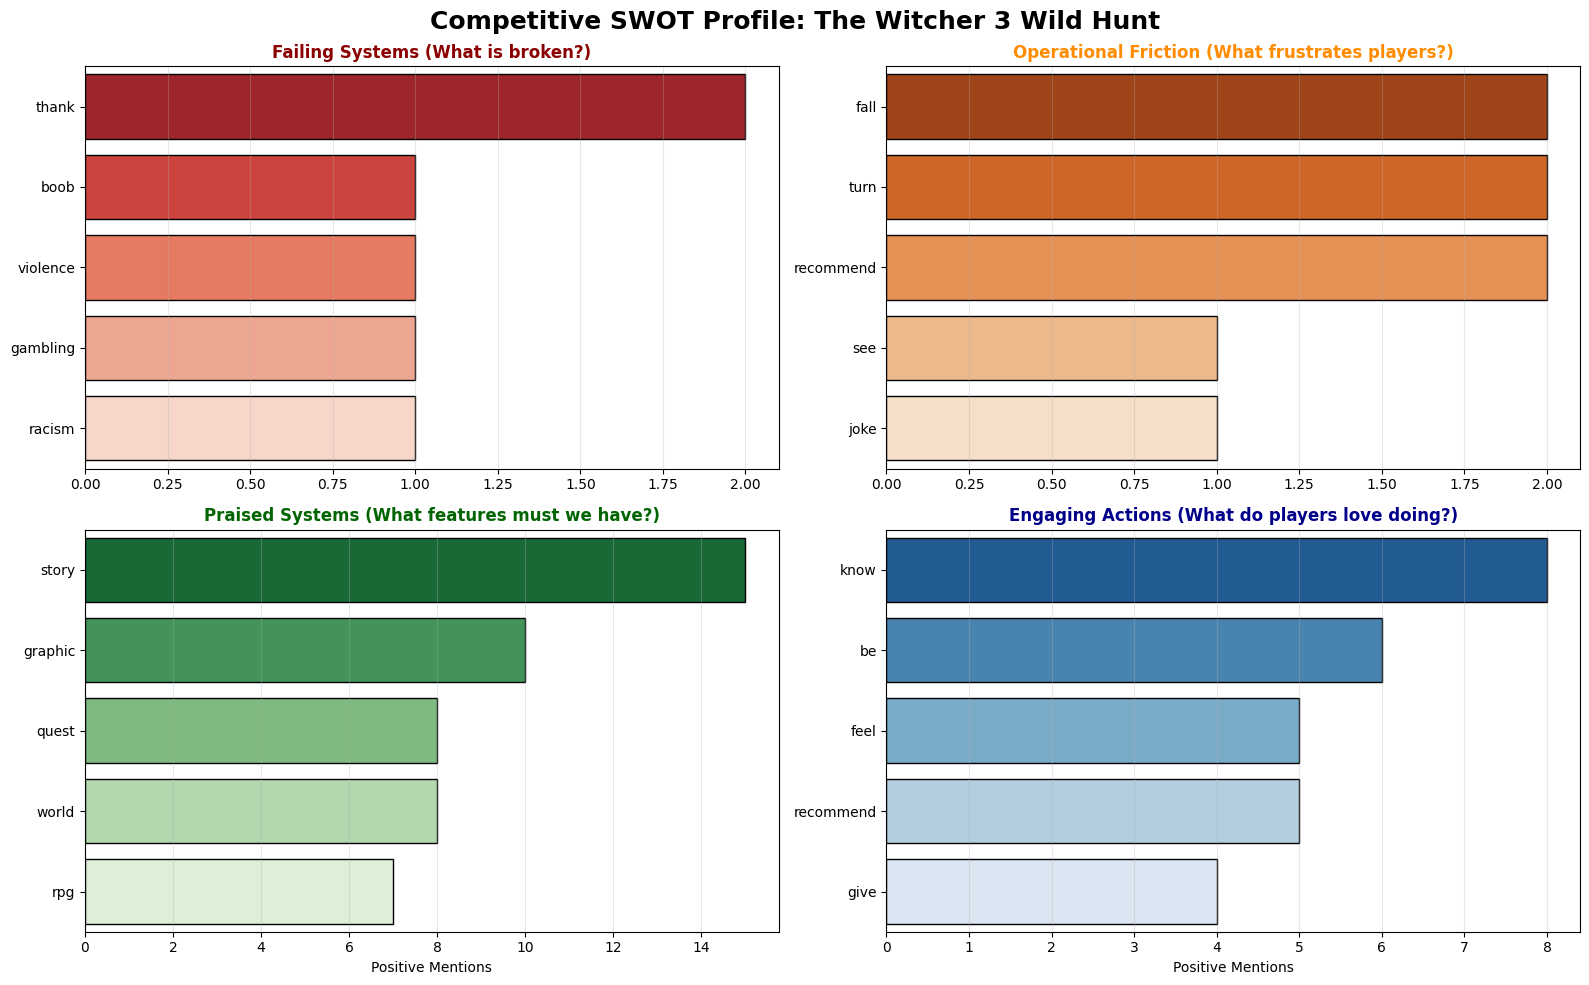

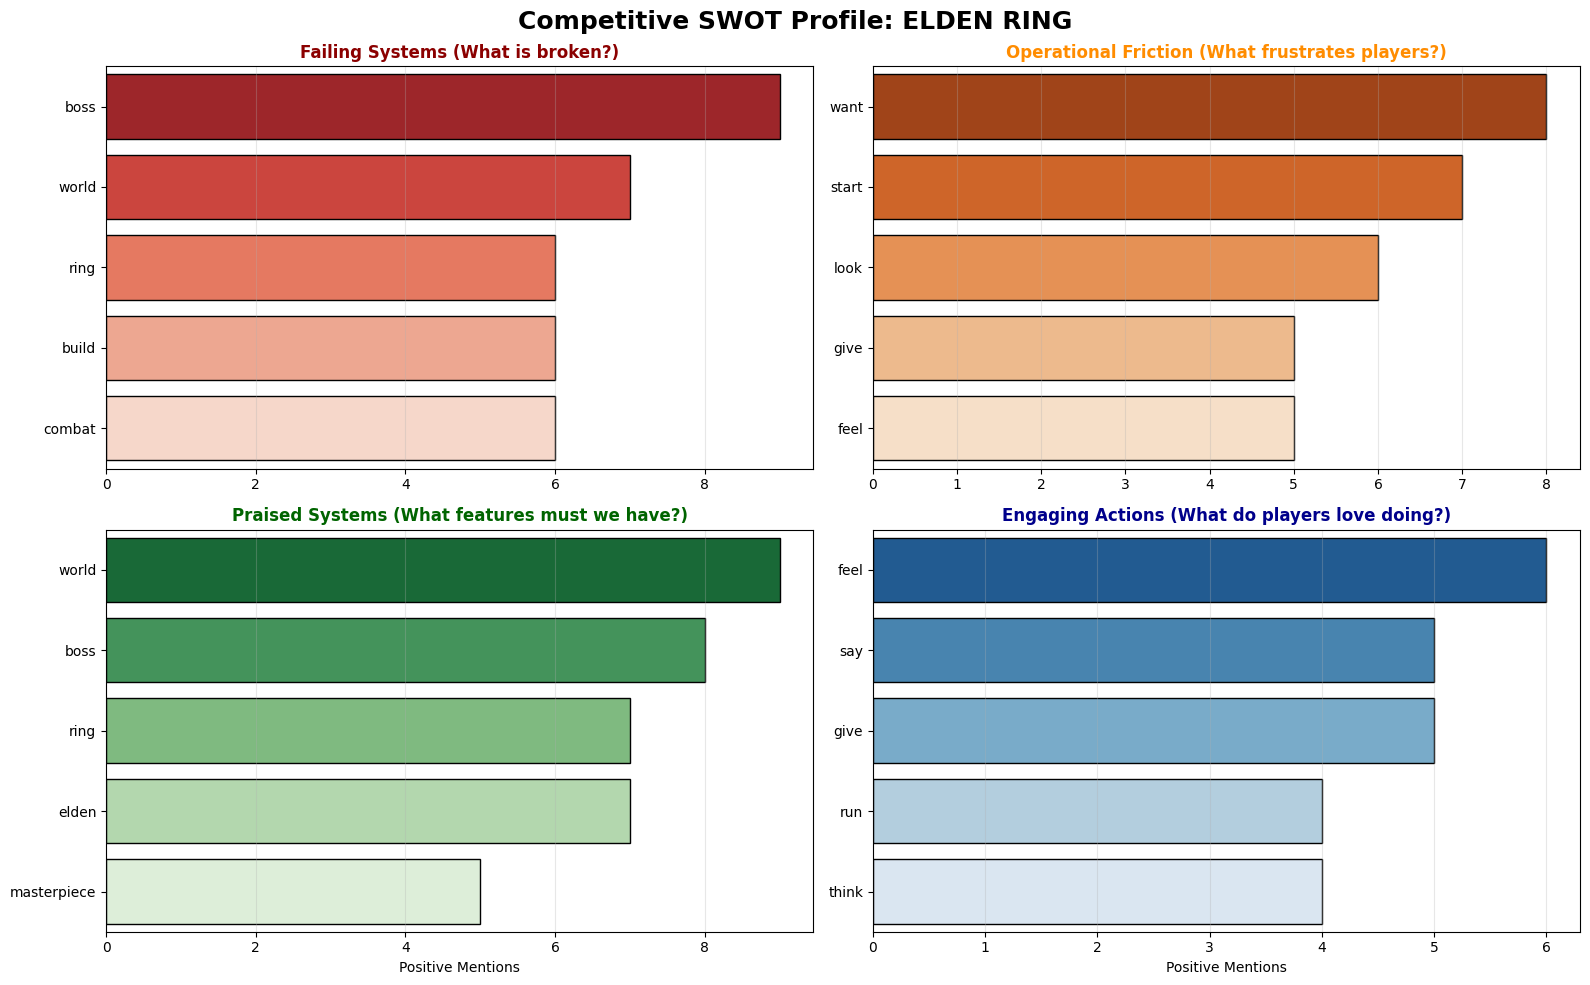

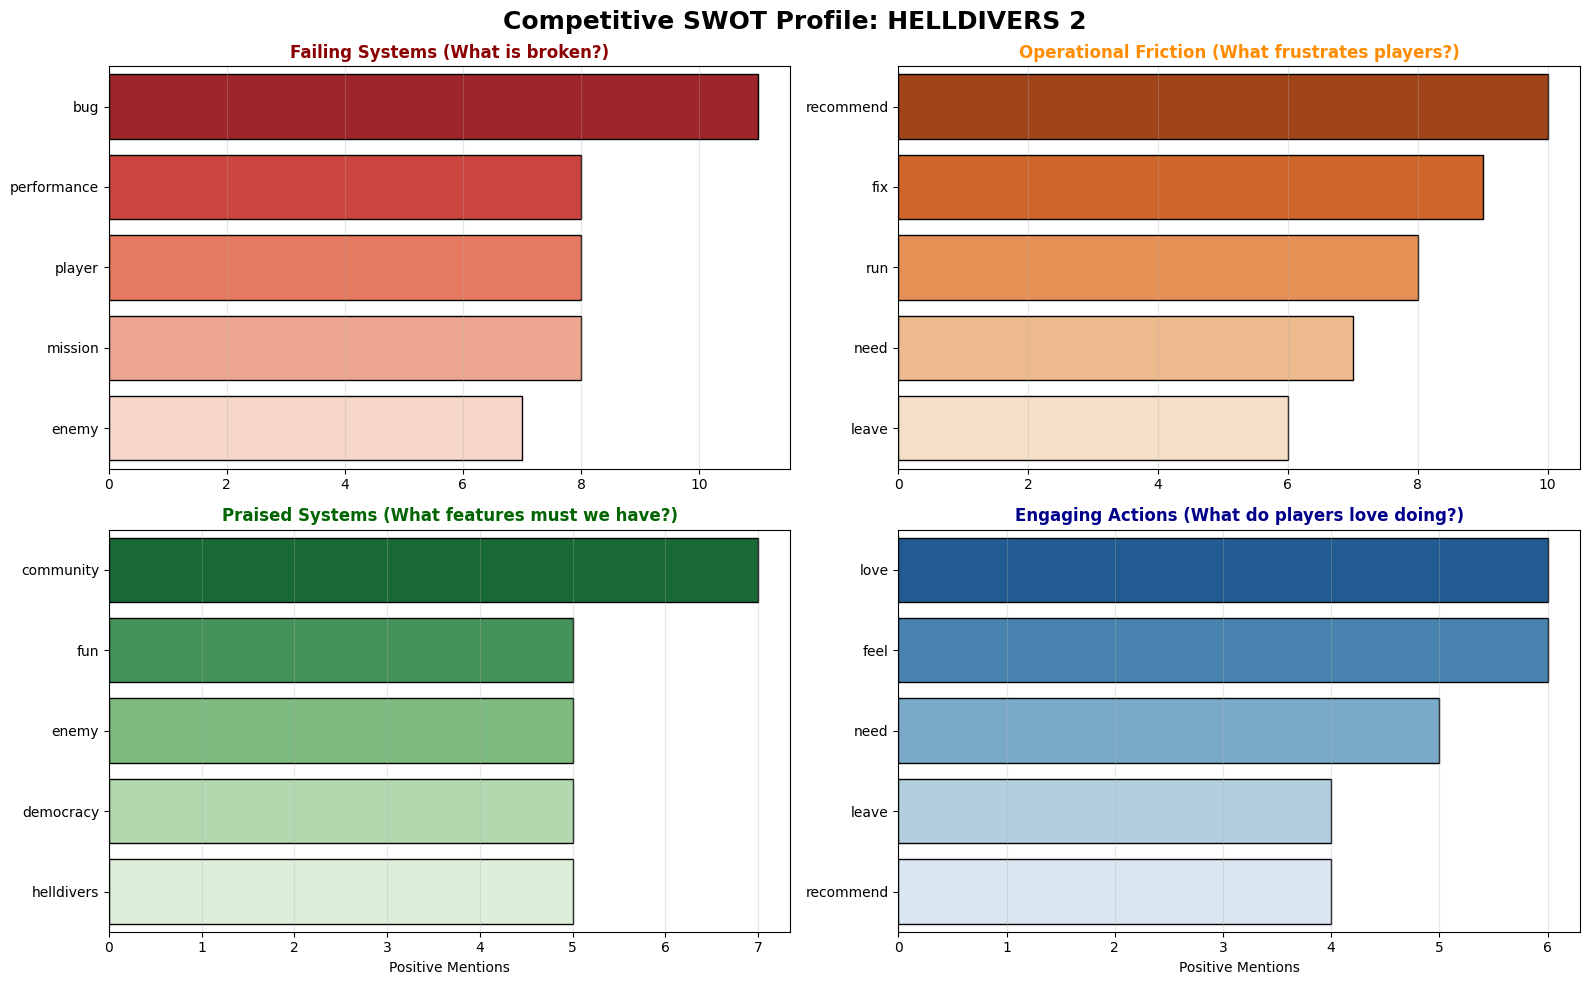

In [ ]:
import pandas as pd

# 1. Grab the Top 15 games from your existing 'top_games_accurate' dataframe
top_15_games = top_games_accurate.head(15).copy()
top_15_appids = top_15_games['appid'].tolist()

# 2. Loop through and extract sentiment JUST for these 15 games
print("\nExtracting NLP Sentiment & PoS Tags...")
valid_dfs = []

for appid in top_15_appids:
    result_df = get_player_sentiment_v2(appid, reviews_cleaned)

    if not result_df.empty:
        valid_dfs.append(result_df)

# 3. Concatenate and Visualize
if not valid_dfs:
    print("No valid English reviews found for any of these games.")
else:
    # Compile the Master Sentiment Dataframe
    master_top15_df = pd.concat(valid_dfs, ignore_index=True)

    master_top15_df['appid_str'] = master_top15_df['appid'].astype(str)

    # We also cast df_full right here to guarantee the names match and don't show up as "Unknown"
    df_full['appid_str'] = df_full['appid'].astype(str)

    print(f"✅ Successfully compiled {len(master_top15_df)} total reviews.")

    #Display the Health Calculator
    display_competitor_health_summary(master_top15_df, df_full)

    #Display the SWOT Dashboards
    print("\nGenerating Competitive SWOT Dashboards...")
    plot_full_competitor_swot(master_top15_df, df_full, top_n=5)